# 10장 — 그래프 특징 공학: 수동 및 반자동 접근법

| | |
| --- | --- |
| **책** | Alessandro Negro 외, *Knowledge Graphs and LLMs in Action* (Manning) **10장** |
| **해설 원본** | [10_..._ko_explained.md 열기](../../10_graph_feature_engineering_manual_and_semiautomated_approaches_ko_explained.md) |
| **원서 원문** | [10_....md 열기](../../10_graph_feature_engineering_manual_and_semiautomated_approaches.md) |
| **이 폴더** | [tasks.py](./tasks.py) · [listings/](./listings) · [requirements.lock](./requirements.lock) |
| **원서 저장소** | [alenegro81/.../chapters/ch12 열기](https://github.com/alenegro81/knowledge-graphs-and-llms-in-action/tree/main/chapters/ch12) |
| **리스팅 번호** | **오프셋으로 표현할 수 없다.** 책은 10장, 저장소 폴더는 `ch12` 라 **major 번호부터 다르다.** minor 도 대체로 −2 지만 **책 10.18 ↔ 저장소 `12.19` 한 건이 어긋난다.** 그래서 번호 대신 `path` + `symbol` 로 선언한다 (아래 헬퍼 셀이 출력하는 대조표 참고) |
| **외부 서비스** | 10.1·10.3 절은 **없다** (순수 `networkx`). 10.2 절의 DWPC 리스팅 세 개만 **Neo4j + `hetionet` DB** 가 필요하다 |

---

9장은 그래프 위 머신러닝의 얼개를 훑었다. 10장은 그 파이프라인의 **첫 칸 하나** 만 확대한다 — 노드와 관계를 **숫자 벡터로 바꾸는 일**, 즉 **특징 공학(feature engineering)** 이다. 알고리즘(로지스틱 회귀·랜덤 포레스트)은 이미 성숙했지만 그래프 구조를 직접 먹지 못한다. 벡터를 어떻게 만드느냐가 성능을 결정한다.

이 장이 서 있는 자리는 **해석 가능성 ↔ 자동화** 스펙트럼의 왼쪽 끝이다.

| 접근 | 해석 가능성 | 만드는 비용 | 다루는 장 |
| --- | --- | --- | --- |
| **수동 특징** | 매우 높다 — 그래프만 보고 설명된다 | 사람이 지표마다 설계·구현 | **10.1 · 10.2** |
| **반자동 특징** | 높다 — 계산을 단계별로 추적할 수 있다 | 재귀 규칙 하나로 대량 생성 | **10.3 (ReFeX)** |
| **완전 자동 특징** | 낮다 — 밀집 벡터의 각 축에 이름이 없다 | 학습이 대신한다 | 11장 · 12장 |

11장이 이 장의 특징을 "신경망이 알아서 배우게" 바꾸므로, **10장은 무엇을 배우게 할 것인가에 대한 사람의 답** 이다. 그래서 이 노트북은 지표를 하나씩 쌓아 올리며 매번 두 가지를 같이 묻는다 — **이 숫자가 무엇을 재는가**, 그리고 **왜 그게 사기 탐지에 쓸모가 있는가**.

| 절 | 내용 | 데이터 | 이 절이 답하는 질문 | 리스팅 |
| --- | --- | --- | --- | --- |
| 10.1 | 노드의 수동 특징 — 사기 탐지 네트워크 | 노드 20개 예제 그래프 | 노드 하나를 어떤 숫자들로 대신할까 | 10.2 · 10.4 · 10.6\~10.11 · 10.13 |
| 10.2 | 관계의 수동 특징 — 링크 예측 | `hetionet` | 노드가 아니라 **노드 쌍** 을 어떻게 표현할까 | 10.14\~10.17 |
| 10.3 | 반자동 특징 추출 — ReFeX | 예제 그래프 + `hetionet` | 지표 설계를 규칙 하나로 자동화할 수 있을까 | 10.18 |
| — | 실습 10-A \~ 10-D · 요약 | | | |

> **한 문장 요약** — 노드를 **국소(차수·삼각형·에고넷 밀도)** 에서 **전역(측지 경로·근접·매개 중심성·페이지랭크)** 으로 나아가는 16차원 벡터로 바꿔 사기 분류기를 학습시키고, 노드 쌍은 **두 벡터의 결합(이어붙이기·평균·L1·L2·아다마르)** 이나 **메타경로 DWPC** 로 표현하고, 마지막에는 그 손일을 **ReFeX 의 재귀 집계** 가 대신하게 만든다.

이 장은 **읽는 재미보다 검산의 재미가 큰 장** 이다. 책이 지표마다 값 표를 실어 놓았기 때문에 리스팅을 돌려 그 표를 그대로 재현할 수 있고, **재현되지 않으면 그것이 곧 발견** 이다. 실제로 이 노트북은 그렇게 해서 책의 표 세 개와 리스팅 사이의 불일치 세 건, Cypher 리스팅의 버그 한 건을 수치로 잡아냈다. 각 절에 그 대조를 담았다.


---
## 실행 환경 — 10.1·10.3 절은 Neo4j 없이, 10.2 절만 `hetionet` 이 필요하다

이 장의 요구는 절마다 다르다. 그것이 이 장의 실행 환경에서 유일하게 헷갈리는 부분이니 먼저 정리한다.

| 절 | 리스팅 | 필요한 것 | 이유 |
| --- | --- | --- | --- |
| 10.1 | 10.2 · 10.4 · 10.6\~10.11 · 10.13 | 파이썬 패키지만 | 노드 20개 그래프를 `networkx` 로 메모리에 만든다 |
| 10.2 | 10.14 | 파이썬 패키지만 | 벡터 결합 연산자 다섯 개, 6줄짜리 함수들 |
| 10.2 | **10.15 · 10.16 · 10.17** | **Neo4j + `hetionet` DB** | Hetionet 위에서 메타경로 DWPC 를 계산하는 Cypher |
| 10.3 | 10.18 | 파이썬 패키지만 (+ 실습 10-D 는 `hetionet`) | ReFeX 는 순수 구조 알고리즘이다 |

### `hetionet` 데이터베이스는 4장에서 만든다

10.15\~10.17 은 `Compound` · `Gene` · `Disease` · `Anatomy` · `Pathway` 노드와 `BINDS_CbG` · `ASSOCIATES_DaG` 같은 관계 타입을 그대로 참조한다. 이 그래프는 **[4장 노트북](../../../chapter_04_from_simple_networks_to_multisource_integration/src/ch04/04_chapter_guide.ipynb) 의 책 리스팅 4.16** 이 백업 시드(69 MB)로 만든다. 아직 없으면 그 셀을 먼저 돌려라 — 실측 8초다.

`CREATE DATABASE ... seedUri` 가 **Enterprise 전용** 이므로 4.16 을 돌리려면 Enterprise 컨테이너가 필요하다. 이미 만들어 두었다면 이 장은 읽기만 하므로 에디션을 가리지 않는다. 4장에서 쓴 컨테이너를 그대로 쓰면 된다.

```bash
docker ps --filter name=kglm-neo4j    # 어느 컨테이너가 떠 있는지
```

> **`hetionet` 은 기본 DB 가 아니다.** `studykit.cypher.driver()` 로 붙은 뒤 반드시 `database="hetionet"` 을 명시해야 한다. 명시하지 않으면 빈 `neo4j` DB 에 질의해 0행이 나오고, 에러가 아니라 **빈 결과** 라서 알아채기 어렵다.

### 파이썬 패키지

교재 루트의 `.venv`(Python 3.10) 커널에서 돌아간다. 처음이면 교재 루트에서 [`setup_env.py`](../../../setup_env.py) 를 한 번 실행한다.

```bash
python3 setup_env.py
```

그다음 **이 챕터 폴더에서** 챕터별 의존성을 설치한다.

```bash
cd "source/Alessandro Negro - Knowledge Graphs and LLMs in Action/chapter_10_graph_feature_engineering_manual_and_semiautomated_approaches/src/ch12"
python tasks.py --list      # 태스크 목록 (업스트림 Makefile 에는 init 하나뿐이다)
python tasks.py init        # requirements.lock 설치
```

| 패키지 | 쓰는 곳 |
| --- | --- |
| `networkx` | 예제 그래프 생성, 최단 경로·중심성·페이지랭크·에고넷 |
| `pandas` | 특징 행렬을 데이터프레임으로 조립 (10.10 · ReFeX 출력) |
| `scikit-learn` | 10.11 의 `train_test_split` · `StandardScaler` · `LogisticRegression`, ReFeX 가지치기의 `StandardScaler` |
| `numpy` | 10.14 의 L1·L2·아다마르, ReFeX 의 특징 행렬 |
| `neo4j` | 10.15\~10.17 의 Cypher 실행 (교재 루트 `base_packages` 에 있다) |
| `matplotlib` | `12.1`·`12.3` 이 임포트만 한다. 이 장에서 실제로 그림을 그리지는 않는다 |

> **⚠️ 이 챕터의 `requirements.lock` 은 `networkx==3.2.1` · `scikit-learn==1.1.2` 를 pin 하지만, 이 노트북은 현재 커널의 `networkx 3.4.2` · `scikit-learn 1.7.2` · `pandas 2.3.3` · `numpy 1.26.4` 에서 실행해 확인했다.** 리스팅 14건 전부 이 조합에서 문제없이 돌았다. 버전을 내리지 않은 이유는 [11장 노트북](../../../chapter_11_graph_representation_learning_and_graph_neural_networks/src/ch13/11_chapter_guide.ipynb) 이 `networkx 3.4.2` 에서 실행돼 출력까지 커밋됐기 때문이다. 다운그레이드하면 그쪽 출력이 어긋난다.
>
> 다만 **`scikit-learn` 버전은 10.11 의 로지스틱 회귀 계수를 바꿀 수 있다.** 아래 10.1.8 절에서 뽑는 "상위 5개 특징"의 **순서** 가 다르게 나오면 그 때문이다. 학습 자체는 시드가 고정돼(`random_state=42`) 재현된다.

### 실행 시간 감각

| 셀 | 하는 일 | 실측 |
| --- | --- | --- |
| 환경 점검 | import 확인 + Neo4j 핸드셰이크 | 1초 미만 |
| 10.1 절 전체 (10.2\~10.13) | 노드 20개 그래프의 지표 7종 + 분류기 학습 | 각 1초 미만 |
| 10.15 · 10.16 · 10.17 | `hetionet` DWPC 세 건 | 각 **0.1\~0.3초** |
| 실습 10-C | 화합물 6개 × 메타경로 3종 DWPC | 약 2초 |
| 10.18 ReFeX (예제 그래프) | 노드 20개, 반복 2회 | 1초 미만 |
| 실습 10-D ReFeX (`hetionet` 부분 그래프) | 노드 946개 / 간선 1,655개 | Cypher 0.1초 + ReFeX **0.1초** |

**오래 걸리는 셀이 하나도 없다.** 이 장은 계산이 무거운 장이 아니라 **지표의 의미를 하나씩 따지는 장** 이다. 그래서 건너뛰기 가드도 두지 않았다. 단, 10.2 절 세 셀은 `hetionet` 이 없으면 실패하므로 아래 환경 점검 셀이 그것을 미리 알려 준다.


In [1]:
"""환경 점검 — 이 셀이 통과하면 이후 모든 셀을 돌릴 수 있다.

이 장은 요구가 절마다 다르므로 두 단계로 확인한다.

  1. 파이썬 패키지 — 10.1·10.3 절은 이것만 있으면 끝난다.
  2. Neo4j + hetionet DB — 10.2 절의 DWPC 리스팅 세 개(10.15~10.17)에만 필요하다.

2번이 없어도 노트북의 3분의 2는 돌아가므로 여기서 예외를 던지지 않고 HAS_HETIONET
플래그만 내린다. 10.2 절 셀들이 그 플래그를 보고 건너뛴다. 반대로 1번이 없으면
이후 전부가 막히므로 즉시 실패시킨다.
"""
import importlib
import platform
from pathlib import Path

from studykit import config, cypher

STUDY = config.load()     # 위로 올라가며 study.toml 을 찾는다
HERE = Path.cwd()         # 주피터는 노트북 폴더를 cwd 로 둔다
REPO_DIR = "ch12"         # 업스트림 디렉터리명. 책 10장 = MEAP ch12
HETIONET_DB = "hetionet"  # 기본 DB 가 아니다. 세션마다 명시해야 한다

assert (HERE / "listings").is_dir(), f"cwd 가 챕터 폴더가 아니다: {HERE}"

print("교재      :", STUDY.title)
print("파이썬    :", platform.python_version(), "(study.toml 고정:", STUDY.python + ")")
print("작업 폴더 :", HERE.name, "(책 10장)")

# ---- 1. 파이썬 패키지 ---------------------------------------------------------
# requirements.lock 은 networkx==3.2.1 / scikit-learn==1.1.2 를 pin 하지만, 현재
# 커널에는 11장 작업 때 올라간 더 최신 버전이 들어 있다. 리스팅 14건을 그 버전으로
# 전수 실행해 확인했으므로 버전을 내리지 않는다. 실제 버전을 출력해 대조하게 한다.
REQUIRED = {
    "networkx": "예제 그래프·최단 경로·중심성·페이지랭크·에고넷",
    "pandas": "특징 행렬을 데이터프레임으로 (10.10 · ReFeX)",
    "sklearn": "10.11 분류기 · ReFeX 가지치기의 StandardScaler",
    "numpy": "10.14 의 L1·L2·아다마르, ReFeX 특징 행렬",
    "matplotlib": "12.1·12.3 이 임포트만 한다 (이 장은 그림을 그리지 않는다)",
    "neo4j": "10.15~10.17 의 Cypher 실행",
}
LOCKED = dict(
    line.split("==") for line in (HERE / "requirements.lock").read_text().split()
    if "==" in line
)

missing = []
print()
for module_name, why in REQUIRED.items():
    try:
        module = importlib.import_module(module_name)
    except ImportError:
        missing.append(module_name)
        print(f"  ✗ {module_name:<12} 없음 — {why}")
    else:
        version = getattr(module, "__version__", "?")
        pin = LOCKED.get(module_name if module_name != "sklearn" else "scikit-learn")
        note = "" if pin in (None, version) else f"  (lock: {pin})"
        print(f"  ✓ {module_name:<12} {version:<10}{note:<16} {why}")

if missing:
    raise RuntimeError(
        f"패키지가 없다: {', '.join(missing)}\n"
        f"  이 폴더에서 다음을 실행하라:\n"
        f"      python tasks.py init"
    )

# ---- 2. Neo4j + hetionet -----------------------------------------------------
# 없어도 10.1·10.3 절은 돌아간다. 그래서 예외 대신 플래그를 내린다.
HAS_HETIONET = False
try:
    with cypher.driver() as drv:
        with drv.session(database="system") as s:
            info = s.run("CALL dbms.components() YIELD versions, edition "
                         "RETURN versions[0] AS version, edition").single()
            names = {r["name"] for r in s.run("SHOW DATABASES YIELD name "
                                              "RETURN DISTINCT name")}
        print(f"\nNeo4j     : {info['version']} ({info['edition']} edition)")
        print("데이터베이스:", sorted(names))
        if HETIONET_DB in names:
            with drv.session(database=HETIONET_DB) as s:
                n = s.run("MATCH (n) RETURN count(n) AS n").single()["n"]
                r = s.run("MATCH ()-[x]->() RETURN count(x) AS n").single()["n"]
            print(f"{HETIONET_DB:<10}: 노드 {n:,} / 관계 {r:,}")
            HAS_HETIONET = n > 0
except Exception as exc:                      # 드라이버 부재·연결 거부·인증 실패
    print(f"\nNeo4j     : 연결 실패 — {type(exc).__name__}: {exc}")

if not HAS_HETIONET:
    print(
        "\n⚠️  hetionet DB 를 쓸 수 없다. 다음을 건너뛴다 — 해당 셀들이 이 플래그를 본다:\n"
        "      · 10.2 절 책 10.15 · 10.16 · 10.17 (메타경로 DWPC)\n"
        "      · 실습 10-C (다른 화합물·다른 메타경로로 DWPC 재계산)\n"
        "      · 실습 10-D (hetionet 부분 그래프에 ReFeX 적용)\n"
        "    되살리는 방법:\n"
        "      1) Enterprise 컨테이너를 띄운다 (4장 노트북의 docker run 명령)\n"
        "      2) 4장 노트북의 책 리스팅 4.16 을 실행한다 (백업 시드 69MB, 8초)\n"
        "    10.1 절 전체, 10.3 절의 책 10.18, 실습 10-A·10-B 는 Neo4j 없이 돌아간다."
    )
else:
    print("\n준비 완료. 이 장의 모든 셀을 돌릴 수 있다.")


교재      : Knowledge Graphs and LLMs in Action
파이썬    : 3.10.18 (study.toml 고정: 3.10)
작업 폴더 : ch12 (책 10장)

  ✓ networkx     3.4.2       (lock: 3.2.1)  예제 그래프·최단 경로·중심성·페이지랭크·에고넷
  ✓ pandas       2.3.3       (lock: 2.2.3)  특징 행렬을 데이터프레임으로 (10.10 · ReFeX)


  ✓ sklearn      1.7.2       (lock: 1.1.2)  10.11 분류기 · ReFeX 가지치기의 StandardScaler
  ✓ numpy        1.26.4                     10.14 의 L1·L2·아다마르, ReFeX 특징 행렬
  ✓ matplotlib   3.10.9      (lock: 3.9.4)  12.1·12.3 이 임포트만 한다 (이 장은 그림을 그리지 않는다)
  ✓ neo4j        5.28.4                     10.15~10.17 의 Cypher 실행

Neo4j     : 5.26.28 (enterprise edition)
데이터베이스: ['ckg', 'hetionet', 'neo4j', 'ppi', 'system']
hetionet  : 노드 47,031 / 관계 2,250,197

준비 완료. 이 장의 모든 셀을 돌릴 수 있다.


In [2]:
"""리스팅 접근 헬퍼 — 이 챕터의 번호 사정과 실행 규약.

책 리스팅 하나가 저장소의 어느 파일·어느 심볼인지는 study.toml 의
`[mapping.listings.ch12]` 가 정본이고, 그 선언을 읽는 일은 `studykit.listing_source`
가 한다. 선언 형식과 `symbol` 특수값(`__main__`·`__entry__`)은 그 모듈의 독스트링을
보라. 노트북은 결과만 받아 쓴다.

    listing_source.chunk_for(STUDY, "ch12", "10.4")   -> .text / .origin() / .path
    listing_source.cross_reference(STUDY, "ch12")      -> 대조표 한 줄씩 (.title 포함)
    listing_source.unnumbered_listings(STUDY, "ch12")  -> 책 번호를 못 받은 파일

책 리스팅 제목도 노트북이 들지 않는다. `cross_reference()` 가 원서 md 의
`Listing N.M` 캡션에서 자동으로 붙이고, 캡션이 유실된 번호만 study.toml 이 `title` 을
선언한다 — 이 챕터에서는 **10.5 한 건** 이다 (원문 L237·L239 에서 캡션째 코드 스캔
이미지 두 장이 되었다. 10.1.3 절 참고).

이 챕터에만 있는 사정은 둘이다.

  1. **번호를 오프셋으로 표현할 수 없다.** 책은 10장인데 저장소 폴더는 `ch12` 라
     major 부터 다르고, minor 도 대체로 −2 지만 **책 10.18 만 저장소 `12.19` 로 한 칸
     더 밀린다** — 그 앞의 `12.18`(메타경로 Cypher 생성 프롬프트)이 책에서 번호를
     못 받았기 때문이다. `tasks.py` 독스트링은 '책 번호 −2' 라고만 적어 두었는데 이
     한 건에서 틀린다. 그래서 study.toml 이 번호 대신 `path` + `symbol` 로 선언한다.

  2. **실행 방법이 리스팅 종류에 따라 갈린다.** 이 폴더 18개 중 14개가 `.py` 고
     넷은 확장자 없는 Cypher·프롬프트 파일이다.

         파이썬 리스팅  -> load() 로 모듈로 임포트한 뒤 함수를 직접 호출한다
         Cypher 리스팅  -> run_cypher() 로 hetionet 세션에 넣는다 (database 를 명시!)

업스트림 원본 파일은 어떤 경우에도 수정하지 않는다. 책 10.15 에는 버그가 있는데
(10.2.2 절 참고) 파일을 고치는 대신 노트북에서 문자열을 치환해 실행한다.
"""
import importlib.util
import inspect
import re
import time

# 이후 모든 셀이 쓰는 도메인 패키지. 여기서 한 번만 임포트한다.
import networkx as nx
import numpy as np
import pandas as pd

from studykit import listing_source

# 선언 전부를 책 번호 순으로 한 번 읽어 둔다. 제목도 여기서 나오므로 노트북은
# 제목 표의 사본을 들지 않는다. 비어 있으면 study.toml 에 title 이 필요한 경우다.
XREF = listing_source.cross_reference(STUDY, REPO_DIR)
NO_TITLE = "— (study.toml 에 title 선언이 필요하다)"
TITLES = {row.number: row.title or NO_TITLE for row in XREF}

# 책 번호를 못 받은 저장소 파일에 붙일 주석. **목록 자체는** listing_source 가
# study.toml 과 listings/ 를 대조해 만든다. 여기서는 왜 그런지만 안다.
UNNUMBERED_NOTES = {
    "12.1":  "create_fraud_network() — 책 원문에 코드는 있으나 캡션이 PDF→md 변환에서 사라졌다. 책 10.1 자리",
    "12.12": "predict_fraud_probability() — 코드는 있고 캡션만 없다. 책 10.12 자리",
    "12.18": "메타경로 Cypher 생성 LLM 프롬프트 — 책은 사이드바 인용문으로 번호 없이 싣는다",
}


def chunk(book_no: str):
    """책 리스팅 번호 -> 소스 조각. study.toml 선언을 listing_source 가 해석한다."""
    return listing_source.chunk_for(STUDY, REPO_DIR, str(book_no))


def source_of(book_no: str) -> str:
    """책 리스팅 원문 문자열."""
    return chunk(book_no).text


def show(book_no: str, head=None) -> None:
    """책 리스팅 원문을 출력한다. head 를 주면 앞부분만 본다."""
    piece = chunk(book_no)
    print(f"── 책 Listing {book_no}  {TITLES.get(str(book_no), NO_TITLE)}")
    print(f"   출처: {piece.origin()}")
    lines = piece.text.splitlines()
    for line in (lines[:head] if head else lines):
        print("   ", line)
    if head and len(lines) > head:
        print(f"    ... (전체 {len(lines)}줄, head={head} 로 잘랐다)")


def load(book_no: str):
    """파이썬 리스팅 파일을 모듈로 임포트한다.

    파일명에 공백과 점이 있어 평범한 import 로는 불러올 수 없으므로 spec 을 직접
    만든다. 파일을 복사하거나 이름을 바꾸지 않는 것이 요점이다.

    주의: 12.1 은 모듈 최상단에서 `G = create_fraud_network()` 를 실행한다.
    임포트만으로 부작용이 생기지만 그래프 하나를 메모리에 만들 뿐이라 무해하다.
    """
    path = chunk(book_no).path
    name = "listing_" + path.name.split(" ")[0].replace(".", "_")
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


def load_file(filename_prefix: str):
    """책에 번호가 없는 저장소 파일을 번호 접두사로 임포트한다 (예: "12.1")."""
    matches = sorted((HERE / "listings").glob(f"{filename_prefix} *.py"))
    if len(matches) != 1:
        raise FileNotFoundError(f"{filename_prefix} 로 시작하는 .py 가 {len(matches)}개")
    spec = importlib.util.spec_from_file_location(
        "file_" + filename_prefix.replace(".", "_"), matches[0])
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


def run_cypher(book_no: str, db: str = HETIONET_DB, limit: int = 5, replace=None, **params):
    """Cypher 리스팅을 실행한다. db 를 반드시 명시한다 — hetionet 은 기본 DB 가 아니다.

    replace 는 (찾을 문자열, 바꿀 문자열) 튜플이다. 책 10.15 의 버그를 원본 파일을
    건드리지 않고 고쳐 실행하기 위한 것이다.
    """
    text = source_of(book_no)
    if replace:
        old, new = replace
        assert old in text, f"치환 대상이 원문에 없다: {old!r}"
        text = text.replace(old, new)
    started = time.time()
    with cypher.driver() as drv, drv.session(database=db) as s:
        rows = [r.data() for r in s.run(text, **params)]
    print(f"책 {book_no} [{db}]{'  (치환 실행)' if replace else ''}: "
          f"{time.time() - started:.2f}초, {len(rows)}행")
    for r in rows[:limit]:
        print("   ", {k: (round(v, 6) if isinstance(v, float)
                          else v if isinstance(v, int) else str(v)[:46])
                      for k, v in r.items()})
    return rows


# ---- 책 리스팅 -> 저장소 위치 대조표 ------------------------------------------
# 번호·제목·위치·번호없는 파일 모두 study.toml 과 원서 md 에서 나온다.
print(f"study.toml 이 선언한 ch12 리스팅 {len(XREF)}건\n")
print(f"{'책':<7}{'책 제목':<58}저장소 위치")
for row in XREF:
    note = f"  {row.note}" if row.note else ""
    print(f"{row.number:<7}{TITLES[row.number][:56]:<58}{row.where}{note}")

unnumbered = listing_source.unnumbered_listings(STUDY, REPO_DIR)
print(f"\nlistings/ 에 있으나 어떤 책 번호도 가리키지 않는 파일 {len(unnumbered)}개 "
      f"(폴더를 열면 마주친다):")
for name in unnumbered:
    print(f"  {name}")
    print(f"      {UNNUMBERED_NOTES.get(name.split(' ')[0], '주석 없음 — 위 선언과 대조해 보라')}")

print("\n번호가 붙은 저장소 파일 18개 중 minor 가 책과 어긋나는 것은 한 건뿐이다:")
print("  책 10.18 (ReFeX implementation) ↔ 저장소 12.19.  바로 앞의 12.18(프롬프트)이")
print("  책에서 번호를 못 받은 탓에 그 뒤가 한 칸 밀렸다.")


study.toml 이 선언한 ch12 리스팅 15건

책      책 제목                                                      저장소 위치
10.2   Example use                                               listings/12.3 Computing different types of node degrees in a fraud detection network.py  L62-L67  __entry__
10.4   Computing triangle metrics in a fraud detection network   listings/12.4 Computing triangle metrics in a fraud detection network.py  L4-L39  compute_triangle_metrics
10.5   Computing egonet density in a fraud detection network     listings/12.5 Computing egonet density in a fraud detection network.py  L4-L28  compute_density_metrics
10.6   Computing geodesic path metrics in a fraud detection net  listings/12.6 Computing geodesic path metrics in a fraud detection network.py  L5-L39  compute_geodesic_metrics
10.7   Computing closeness centrality in a fraud detection netw  listings/12.7 Computing closeness centrality in a fraud detection network.py  L5-L28  compute_closeness_metrics
10.8   Computing betweenness 

---
## 10.1 노드의 수동 특징 — 사기 탐지 네트워크에서 시작하기

사람이 노드고, 사람 사이의 어떤 연결이든 관계인 그래프를 생각한다. 그중 **일부** 는 이미 알려진 **사기꾼(fraudster)** 이다. 전체 명단은 없다. 과제는 두 가지다 — 아직 밝혀지지 않은 사기꾼을 찾아내거나, 각 사람이 사기의 피해자가 될 위험을 판정하는 것.

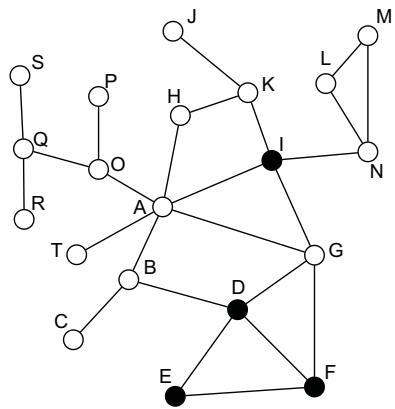

*그림 10.1 — 이 장 전체가 쓰는 예제 네트워크. 노드 20개(A\~T), 무향 간선 25개다. 검은 노드 **D · E · F · I** 가 알려진 사기꾼이고 나머지는 정상이거나 아직 정체가 확인되지 않았다. 아래 모든 지표가 이 한 그래프에서 계산되므로, 값이 이상하면 이 그림을 직접 세어 보면 된다.*

목표는 **노드 하나를 받아 사기꾼인지 답하는 분류기** 다. 이 작업은 로지스틱 회귀·베이즈 분류기·결정 트리·랜덤 포레스트 같은 고전 알고리즘으로 한다. 모두 **지도 학습** 이므로 입력은 (특징 집합, 라벨) 쌍이다. 라벨은 이미 있다(`is_fraudster`). 없는 것은 **특징** 이고, 그것을 그래프 구조에서 만들어 내는 일이 이 절의 전부다.

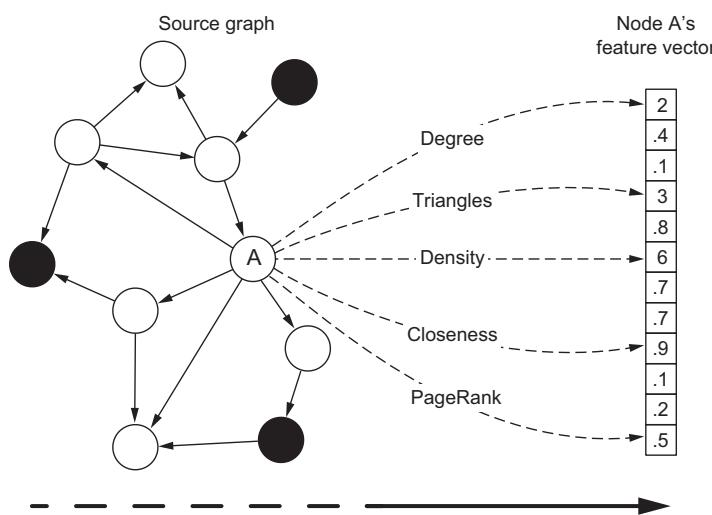

*그림 10.2 — 특징화(featurization). 왼쪽 그래프의 노드 A 가 오른쪽의 12차원 벡터가 된다. 각 칸이 하나의 지표(차수·삼각형·밀도·근접·페이지랭크)에서 나온 값이다. 이 노트북은 이 화살표를 지표별로 하나씩 다시 그린다 — 10.1.1 절부터 10.1.7 절까지 매번 차원이 늘고, 10.1.8 절에서 16차원 벡터가 분류기에 들어간다.*

### 국소 특징과 전역 특징

뽑을 수 있는 특징은 **계산에 그래프의 어느 만큼을 보는가** 로 갈린다.

| 구분 | 보는 범위 | 이 절의 지표 |
| --- | --- | --- |
| **국소 특징(local features)** | 노드의 1홉 이웃, 즉 **에고넷(egonet)**. n홉으로 넓힐 수도 있다 | 차수(10.1.1) · 삼각형(10.1.2) · 에고넷 밀도(10.1.3) |
| **전역 특징(global features)** | 네트워크 전체(또는 상당 부분) 안에서 노드가 맡는 역할 | 측지 경로(10.1.4) · 근접 중심성(10.1.5) · 매개 중심성(10.1.6) · 페이지랭크(10.1.7) |

**에고넷** 은 특정 노드와 그 바로 옆 이웃들이다. 중심 노드를 **에고(ego)**, 주변을 **알터(alters)** 라 부른다. 이 절의 진행 순서는 **국소에서 전역으로** 다. 값싸고 해석이 쉬운 것에서 시작해 계산이 무겁고 의미가 미묘한 것으로 나아간다.

### 이 장이 지표를 "맞춤 변형"하는 방식

여기서 중요한 설계 결정이 하나 있다. 책은 표준 지표를 그대로 쓰지 않고 **도메인 라벨을 지표 안에 집어넣는다.** 차수를 그냥 세지 않고 **사기 차수 / 정상 차수** 로 쪼개고, 삼각형을 그냥 세지 않고 **사기 / 정상 / 반사기** 삼각형으로 쪼갠다.

이것이 곧 "수동 특징 공학"이 무엇인지에 대한 답이다. 표준 그래프 알고리즘을 호출하는 일은 자동화의 몫이지만, **"사기꾼 이웃이 몇인지가 사기 여부와 관련 있을 것"이라는 가설은 사람만 세울 수 있다.** 11장의 GNN 이 대신하지 못하는 것이 바로 이 종류의 지식이고, 반대로 이 가설이 틀렸으면 특징은 잡음이 된다.

> **주의 — 라벨 누출(label leakage).** 사기 차수·사기 삼각형·사기꾼까지의 측지 경로는 모두 **정답 라벨 `is_fraudster` 를 특징 계산에 쓴다.** 학습 데이터의 라벨이 테스트 노드의 특징으로 흘러 들어가므로 실무에서는 시점 분리(사건 발생 이전에 이미 알려진 사기꾼만 사용)가 필수다. 책은 이 점을 명시하지 않지만, 10.1.8 절에서 정확도가 1.00 으로 나오는 이유의 상당 부분이 여기 있다. 아래 해당 셀에서 다시 짚는다.


In [3]:
"""책 10.2 (Example use) — 이 장 전체가 쓰는 예제 그래프를 만든다.

책 10.2 는 세 줄짜리 사용 예다. 그 앞의 create_fraud_network() 정의는 책에서
번호를 못 받았으므로(저장소 `12.1`·`12.3`) 여기서 함께 싣는다. 왜 이렇게 생겼는지:

  · nx.Graph() 는 **무향** 그래프다. 그림 10.1 의 간선에 화살표가 없는 것과 맞는다.
    이 선택이 뒤의 지표 전부를 바꾼다 — 방향이 없으므로 진입/진출 차수가 없고,
    페이지랭크도 대칭 그래프 위에서 돌게 된다 (10.1.7 절 참고).
  · 노드를 먼저 전부 넣고 나서 `is_fraudster` 를 채운다. 간선부터 넣으면 고립 노드
    없는 그래프가 되어 예제의 J·P·R·S 같은 잎 노드를 표현할 수 없다.
  · 라벨을 **노드 속성** 으로 붙인다. 뒤의 모든 "사기 차수·사기 삼각형" 계산이
    G.nodes[n]['is_fraudster'] 를 읽으므로 이 속성이 곧 도메인 지식의 주입점이다.

한 가지 주의. `12.1` 은 모듈 최상단에서 `G = create_fraud_network()` 를 실행하므로
임포트만으로 그래프가 하나 만들어진다. 무해하지만 부작용이 있다는 점은 알아 두자.
"""
# 책 10.2 원문 — 저장소 12.3 의 if __name__ 블록이 주석까지 거의 같다.
show("10.2")

# 정의는 책에서 번호를 못 받았다. 저장소 12.1 이 그 코드다.
print()
print("── 책에 번호가 없는 정의: listings/12.1 create_fraud_network() ──")
listing_12_1 = load_file("12.1")
print(inspect.getsource(listing_12_1.create_fraud_network))

# ---- 실행 -------------------------------------------------------------------
# 이후 모든 셀이 이 G 를 쓴다. 책 10.2 의 문장 그대로다.
G = listing_12_1.create_fraud_network()

FRAUDSTERS = sorted(n for n in G.nodes() if G.nodes[n]["is_fraudster"])
NODES = list(G.nodes())

print(f"노드 {G.number_of_nodes()}개 · 간선 {G.number_of_edges()}개 · 무향={not G.is_directed()}")
print("노드      :", " ".join(NODES))
print("사기꾼    :", " ".join(FRAUDSTERS), f"({len(FRAUDSTERS)}/{G.number_of_nodes()} = "
      f"{len(FRAUDSTERS) / G.number_of_nodes():.0%})")
print("연결 성분 :", nx.number_connected_components(G), "개 — 그림 10.1 이 한 덩어리로 보이는 것과 맞는다")

# 책 10.2 의 나머지 두 줄은 뒤에서 정의할 함수를 부른다. 실제로 그렇게 되는지
# 확인만 해 둔다 (10.1.1·10.1.2 절에서 각각 다시 다룬다).
print("\n책 10.2 가 예고한 두 호출 (뒤 절에서 리스팅으로 다시 본다):")
print("   compute_degree_metrics(G)   -> 10.1.1 절, 저장소 12.3")
print("   compute_triangle_metrics(G) -> 10.1.2 절, 책 10.4")


── 책 Listing 10.2  Example use
   출처: 12.3 Computing different types of node degrees in a fraud detection network.py  L62-L67  (__entry__)
    if __name__ == '__main__':
        G = create_fraud_network()
    
        # Use this graph object with any of our metric calculations
        degree_metrics = compute_degree_metrics(G)  # defined later
        print(degree_metrics)

── 책에 번호가 없는 정의: listings/12.1 create_fraud_network() ──


def create_fraud_network():
    G = nx.Graph()

    fraudsters = ['D', 'E', 'F', 'I']

    # Add all nodes first
    nodes = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J',
             'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T']

    G.add_nodes_from(nodes)

    for node in G.nodes():
        G.nodes[node]['is_fraudster'] = node in fraudsters

    edges = [
        ('A', 'B'), ('A', 'G'), ('A', 'H'), ('A', 'I'), ('A', 'O'),
        ('A', 'T'), ('B', 'D'), ('B', 'C'), ('D', 'E'), ('D', 'F'),
        ('D', 'G'), ('E', 'F'), ('F', 'G'), ('G', 'I'), ('H', 'K'),
        ('I', 'K'), ('I', 'N'), ('K', 'J'), ('L', 'M'), ('L', 'N'),
        ('N', 'M'), ('O', 'P'), ('O', 'Q'), ('Q', 'R'), ('Q', 'S')
    ]

    G.add_edges_from(edges)

    return G

노드 20개 · 간선 25개 · 무향=True
노드      : A B C D E F G H I J K L M N O P Q R S T
사기꾼    : D E F I (4/20 = 20%)
연결 성분 : 1 개 — 그림 10.1 이 한 덩어리로 보이는 것과 맞는다

책 10.2 가 예고한 두 호출 (뒤 절에서 리스팅으로 다시 본다):
   compute_degree_metrics(G)   -> 10.1.1 절, 저장소 12.3


### 10.1.1 차수 — 이웃이 몇 명이며, 그중 사기꾼은 몇인가

**차수(degree)** 는 노드가 가진 이웃의 수다. 무향 그래프에서는 인접 간선 수와 같다. 노드 $v$ 에 대해

$$\deg(v) = |N(v)|, \qquad N(v) = \{u : (u,v) \in E\}$$

여기서 $N(v)$ 는 $v$ 의 이웃 집합, $E$ 는 간선 집합이다.

책은 여기서 멈추지 않고 이웃을 라벨로 쪼갠다.

$$\deg_{\text{fraud}}(v) = |\{u \in N(v) : \text{is\_fraudster}(u)\}|, \qquad
\deg_{\text{legit}}(v) = \deg(v) - \deg_{\text{fraud}}(v)$$

**왜 사기 탐지에 유용한가.** 전체 차수만 보면 "인기 있는 사람"과 "사기 조직 안의 사람"을 구별할 수 없다. 이웃이 10명인데 전원이 사기꾼인 사람과, 이웃이 10명인데 전원이 정상인 사람은 위험도가 전혀 다르다. 그런데 두 사람의 $\deg$ 는 똑같이 10이다. **쪼개는 순간 그 차이가 특징 공간에서 분리 가능해진다.** 사기는 대개 조직적이므로 이 신호는 강하다 — 사기꾼끼리 거래·연락·계좌를 공유하기 때문이다.

이 값들의 계산은 손으로도 되는 수준이다. 저장소 파일은 `listings/12.3 ...py` 이고, 책은 이 코드에 번호를 주었을 자리(10.3)에서 캡션을 잃었다. 앞 셀에서 본 **책 10.2** 가 바로 이 파일의 `if __name__` 블록이다.

In [4]:
"""책에 번호가 없는 10.1.1 절 코드 (저장소 12.3) — 차수를 세 갈래로 쪼갠다.

구현이 왜 이렇게 생겼는지 두 가지.

  · `G.nodes[u].get('is_fraudster', False)` 로 **기본값 False** 를 준다. 속성이 없는
    노드가 섞여도 죽지 않는다. 실무에서 라벨은 늘 일부만 있으므로 이 방어는 실제로
    필요하다 — 다만 그 결과 "미확인"과 "정상"이 같은 값으로 뭉개진다는 대가가 있다.
  · legit_degree 를 세지 않고 total − fraud 로 얻는다. 위와 같은 이유로 "정상으로
    확인됨"과 "라벨 없음"을 구별하지 않기 때문이다.

책 표 10.1 과 대조한다. 원문 md 의 표는 OCR 로 셀 정렬이 깨져 있어(해설판이 원형을
보존해 두었다) 여기서는 원서 PDF 의 표 스캔에서 읽은 값을 BOOK_T101 로 적어 두고
실행 결과와 자동 비교한다.
"""
listing_12_3 = load_file("12.3")
print(inspect.getsource(listing_12_3.compute_degree_metrics))

degree_metrics = listing_12_3.compute_degree_metrics(G)

# 원서 표 10.1 (total, fraud, legit)
BOOK_T101 = {
    "A": (6, 1, 5), "B": (3, 1, 2), "C": (1, 0, 1), "D": (4, 2, 2), "E": (2, 2, 0),
    "F": (3, 2, 1), "G": (4, 3, 1), "H": (2, 0, 2), "I": (4, 0, 4), "J": (1, 0, 1),
    "K": (3, 1, 2), "L": (2, 0, 2), "M": (2, 0, 2), "N": (3, 1, 2), "O": (3, 0, 3),
    "P": (1, 0, 1), "Q": (3, 0, 3), "R": (1, 0, 1), "S": (1, 0, 1), "T": (1, 0, 1),
}

print("=== 책 표 10.1 대조 ===")
print(f"{'노드':<5}{'전체':>5}{'사기':>5}{'정상':>5}   {'책(전체/사기/정상)':<20}일치")
mismatch = 0
for n in NODES:
    m = degree_metrics[n]
    got = (m["total_degree"], m["fraud_degree"], m["legit_degree"])
    ok = got == BOOK_T101[n]
    mismatch += not ok
    print(f"{n:<5}{got[0]:>5}{got[1]:>5}{got[2]:>5}   {str(BOOK_T101[n]):<20}{'✓' if ok else '✗'}")
print(f"\n불일치 {mismatch}건 — 표 10.1 은 리스팅으로 정확히 재현된다.")

# 사기 비율이 높은 노드 = 사람이 먼저 볼 후보. 특징 하나만으로도 순위가 나온다.
print("\n사기 이웃 비율 상위 (전체 차수 2 이상):")
for n in sorted(NODES, key=lambda x: -(degree_metrics[x]["fraud_degree"]
                                       / max(degree_metrics[x]["total_degree"], 1)))[:5]:
    m = degree_metrics[n]
    flag = "  <- 이미 알려진 사기꾼" if G.nodes[n]["is_fraudster"] else ""
    if m["total_degree"] >= 2:
        print(f"   {n}: {m['fraud_degree']}/{m['total_degree']} = "
              f"{m['fraud_degree'] / m['total_degree']:.0%}{flag}")
print("   -> G 는 사기꾼이 아닌데 이웃 4명 중 3명이 사기꾼이다. 차수 특징 하나로도")
print("      G 가 가장 먼저 조사할 후보로 올라온다.")

def compute_degree_metrics(G):
    degree_metrics = {}

    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        total_degree = len(neighbors)

        fraud_degree = sum(1 for neighbor in neighbors
                           if G.nodes[neighbor].get('is_fraudster', False))

        legit_degree = total_degree - fraud_degree

        degree_metrics[node] = {
            'total_degree': total_degree,
            'fraud_degree': fraud_degree,
            'legit_degree': legit_degree
        }

    return degree_metrics

=== 책 표 10.1 대조 ===
노드      전체   사기   정상   책(전체/사기/정상)         일치
A        6    1    5   (6, 1, 5)           ✓
B        3    1    2   (3, 1, 2)           ✓
C        1    0    1   (1, 0, 1)           ✓
D        4    2    2   (4, 2, 2)           ✓
E        2    2    0   (2, 2, 0)           ✓
F        3    2    1   (3, 2, 1)           ✓
G        4    3    1   (4, 3, 1)           ✓
H        2    0    2   (2, 0, 2)           ✓
I        4    0    4   (4, 0

### 10.1.2 삼각형 — 서로 얽힌 세 사람

**삼각형(triangle)** 은 세 노드가 서로 모두 연결된 부분 그래프다. $A$–$B$, $A$–$C$, $B$–$C$ 세 간선이 모두 있으면 $\{A,B,C\}$ 는 삼각형이다.

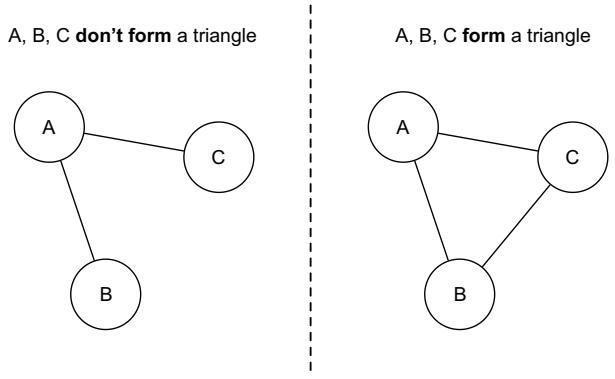

*그림 10.3 — 왼쪽은 A–B, A–C 만 있어 삼각형이 아니다. 오른쪽은 B–C 가 더해져 삼각형이 된다. 노드 하나의 삼각형 수는 그 노드의 이웃 쌍 중 서로 연결된 쌍의 수와 같다 — 아래 리스팅이 정확히 그렇게 센다.*

에고 $v$ 와 두 알터가 삼각형을 이룰 때, 책은 두 알터의 라벨로 삼각형을 세 갈래로 나눈다.

| 이름 | 두 알터의 라벨 |
| --- | --- |
| **사기 삼각형(fraud triangle)** | 둘 다 사기꾼 |
| **반사기 삼각형(semifraudulent triangle)** | 한 명만 사기꾼 |
| **정상 삼각형(legit triangle)** | 둘 다 정상 |

**왜 사기 탐지에 유용한가.** 차수는 "몇 명과 이어져 있나"만 말한다. 삼각형은 **"내 이웃들이 서로도 아는 사이인가"** 를 말한다. 여러분의 가까운 친구들은 대개 서로도 친구다. 그래서 삼각형은 **폐쇄된 집단의 결속** 을 드러낸다. 사기 조직은 우연히 한 사람을 알게 되는 관계가 아니라 서로 얽힌 집단이므로, 사기 삼각형에 속한다는 것은 그 집단의 **내부자** 라는 신호에 가깝다. 반사기 삼각형은 그보다 약한 신호 — 조직의 경계에 접해 있다는 뜻이다. 이 강약을 한 특징에 뭉개지 않고 세 열로 나눠 두면 분류기가 스스로 가중치를 배운다.

계산은 이웃 쌍을 모두 훑으므로 노드당 $O(\deg(v)^2)$ 다. 노드 20개에서는 문제가 없지만 허브가 있는 실제 네트워크에서는 이 항이 지배적이 된다.

In [5]:
"""책 10.4 — 노드별 삼각형 수를 전체·사기·정상·반사기로 나눠 센다.

관용구 하나를 짚어 둘 필요가 있다. 이 코드는 nx.triangles() 를 쓰지 않는다.

    for i in range(len(neighbors)):
        for j in range(i + 1, len(neighbors)):
            if G.has_edge(neighbors[i], neighbors[j]):

이렇게 **이웃 쌍을 직접 훑는** 이유는 삼각형의 개수만 필요한 게 아니라 **어느 알터
쌍이 삼각형을 이뤘는지** 를 알아야 라벨로 분류할 수 있기 때문이다. nx.triangles() 는
개수만 준다. 아래에서 그 둘을 교차 검증한다 — 전체 삼각형 수는 같아야 한다.

`range(i + 1, ...)` 로 상삼각만 보므로 같은 쌍을 두 번 세지 않는다.
"""
show("10.4")

triangle_module = load("10.4")
triangle_metrics = triangle_module.compute_triangle_metrics(G)

# 원서 표 10.2 (total, fraud, legit, semifraud)
BOOK_T102 = {
    "A": (1, 0, 0, 1), "B": (0, 0, 0, 0), "C": (0, 0, 0, 0), "D": (2, 1, 0, 1),
    "E": (1, 1, 0, 0), "F": (2, 1, 0, 1), "G": (2, 1, 0, 1), "H": (0, 0, 0, 0),
    "I": (1, 0, 1, 0), "J": (0, 0, 0, 0), "K": (0, 0, 0, 0), "L": (1, 0, 1, 0),
    "M": (1, 0, 1, 0), "N": (1, 0, 1, 0), "O": (0, 0, 0, 0), "P": (0, 0, 0, 0),
    "Q": (0, 0, 0, 0), "R": (0, 0, 0, 0), "S": (0, 0, 0, 0), "T": (0, 0, 0, 0),
}
KEYS = ("total_triangles", "fraud_triangles", "legit_triangles", "semi_fraud_triangles")

nx_tri = nx.triangles(G)          # 독립 구현으로 전체 삼각형 수만 교차 검증
print("\n=== 책 표 10.2 대조 (전체/사기/정상/반사기) ===")
print(f"{'노드':<5}{'실행 결과':<18}{'책 표 10.2':<18}{'nx.triangles':>13}  일치")
mismatch = nx_diff = 0
for n in NODES:
    got = tuple(triangle_metrics[n][k] for k in KEYS)
    ok = got == BOOK_T102[n]
    mismatch += not ok
    nx_diff += nx_tri[n] != got[0]
    print(f"{n:<5}{str(got):<18}{str(BOOK_T102[n]):<18}{nx_tri[n]:>13}  {'✓' if ok else '✗'}")
print(f"\n책 표와 불일치 {mismatch}건 · nx.triangles() 와 전체 수 불일치 {nx_diff}건")
print("표 10.2 도 리스팅으로 정확히 재현되고, 독립 구현과도 일치한다.")

print("\n사기 삼각형을 가진 노드:")
for n in NODES:
    if triangle_metrics[n]["fraud_triangles"]:
        print(f"   {n}: 사기 삼각형 {triangle_metrics[n]['fraud_triangles']}개"
              f"{'  <- 이미 알려진 사기꾼' if G.nodes[n]['is_fraudster'] else '  <- 라벨 없음. 조사 후보'}")
print("   -> D·E·F 는 이미 알려진 사기꾼이고, G 만 라벨이 없다. 10.1.1 절의 사기 차수와")
print("      같은 노드를 가리킨다. 서로 다른 두 지표가 같은 결론에 닿으면 신뢰가 올라간다.")

── 책 Listing 10.4  Computing triangle metrics in a fraud detection network
   출처: 12.4 Computing triangle metrics in a fraud detection network.py  L4-L39  (compute_triangle_metrics)
    def compute_triangle_metrics(G):
        triangle_metrics = {}
    
        for node in G.nodes():
            triangles = []
            neighbors = list(G.neighbors(node))
    
            for i in range(len(neighbors)):
                for j in range(i + 1, len(neighbors)):
                    if G.has_edge(neighbors[i], neighbors[j]):
                        triangles.append((neighbors[i], neighbors[j]))
    
            total_triangles = len(triangles)
            fraud_triangles = 0
            legit_triangles = 0
            semi_fraud_triangles = 0
    
            for n1, n2 in triangles:
                n1_fraud = G.nodes[n1].get('is_fraudster', False)
                n2_fraud = G.nodes[n2].get('is_fraudster', False)
    
                if n1_fraud and n2_fraud:
                    fraud_tria

### 10.1.3 밀도 — 이웃들이 서로 얼마나 촘촘히 얽혀 있나

노드 $N$ 개인 완전 연결 그래프에서 가능한 간선의 총수는 두 노드를 뽑는 조합의 수다.

$$\binom{N}{2} = \frac{N(N-1)}{2}$$

$N(N-1)$ 은 순서를 고려한 쌍의 수이고, 무향 그래프에서는 $(A,B)$ 와 $(B,A)$ 가 같은 간선이므로 2로 나눈다.

**밀도(density)** 는 그 가능한 간선 중 실제로 관찰된 비율이다. 실제 간선 수를 $M$ 이라 하면

$$d = \frac{M}{\binom{N}{2}} = \frac{2M}{N(N-1)}, \qquad 0 \le d \le 1$$

$d = 0$ 은 연결이 전혀 없음, $d = 1$ 은 완전 연결이다.

이 절이 재는 것은 그래프 전체의 밀도가 아니라 **각 노드의 에고넷 밀도** 다. 노드 A 를 예로 들면, 에고넷은 A 와 이웃 6명(B·G·H·I·O·T)이므로 $N = 7$ 이고 가능한 간선은 $7 \times 6 / 2 = 21$ 개다. 실제 간선은 A 의 스포크 6개에 **G–I** 하나를 더한 7개이므로

$$d(\text{egonet of } A) = \frac{7}{21} \approx 0.33$$

**왜 사기 탐지에 유용한가.** 삼각형은 결속을 **세는** 반면 밀도는 **비율로** 잰다. 그래서 규모가 다른 에고넷을 비교할 수 있다. 이웃이 2명이고 그 둘이 서로 아는 사람($d = 1$)과 이웃이 20명인데 아무도 서로 모르는 사람($d \approx 0.05$)은 사회적 역할이 다르다. 밀도가 1 에 가까우면 **닫힌 소집단** 안에 있고, 낮으면 서로 모르는 집단들을 잇는 **중개자** 다. 사기 유형이 갈리는 지점이다 — 조직형 사기는 밀도가 높고, 다수의 무관한 피해자를 상대하는 사기는 밀도가 낮다.

밀도는 이 장에서 **유일하게 사기 변형이 없는 지표** 다. 책이 밝히듯 "사기 밀도"라는 개념이 자연스럽지 않기 때문이다. 밀도는 간선의 존재만 세고 노드 라벨을 보지 않는다.

> **원서에서 이 리스팅은 코드가 아니라 그림이다.** 책 리스팅 10.5 "Computing egonet density in a fraud detection network" 는 PDF→마크다운 변환에서 **캡션째 코드 스캔 이미지 두 장** 이 되었다. 그래서 리스팅 번호를 텍스트로 긁는 자동 추출이 이 번호를 놓치고, 이 장의 "책 리스팅"이 15건이 아니라 14건으로 집계된다. 실물은 저장소 `listings/12.5 ...py` 에 그대로 있으므로 아래에서 그 원문을 싣는다 — 스캔 이미지를 그림으로 참조하는 대신 코드로 보여주는 편이 읽기도 실행도 쉽다.

In [6]:
"""책 10.5 (저장소 12.5) — 에고넷 밀도. 원서에서는 코드 스캔 이미지였다.

구현 세부 두 가지.

  · egonet_nodes = neighbors + [node] 로 **에고 자신을 포함** 한다. 그래서 A 의 N 은
    6 이 아니라 7 이고, 분모가 21 이 된다. 에고를 빼면 "알터끼리의 밀도"라는 다른
    지표가 되고 값이 커진다 (A 의 경우 1/15 ≈ 0.07). 어느 쪽을 쓰든 일관되기만
    하면 되지만, 책 표 10.3 은 **에고 포함** 판이다.
  · N < 2 를 0.0 으로 처리한다. 잎 노드(C·J·P·R·S·T)는 에고넷이 2개 노드·1개 간선
    이므로 이 분기에 걸리지 않고 d = 1 이 된다. 실제로 N < 2 가 되는 것은 고립
    노드뿐이고 이 그래프에는 없다.
  · nx.density(ego) 로도 같은 값이 나온다. ReFeX 구현(책 10.18)이 실제로 그렇게
    한다. 아래에서 두 방식을 교차 검증한다.
"""
listing_12_5 = load_file("12.5")
print(inspect.getsource(listing_12_5.compute_density_metrics))

density_metrics = listing_12_5.compute_density_metrics(G)

# 원서 표 10.3
BOOK_T103 = {
    "A": 0.33, "B": 0.5, "C": 1, "D": 0.6, "E": 1, "F": 0.83, "G": 0.6, "H": 0.66,
    "I": 0.5, "J": 1, "K": 0.5, "L": 1, "M": 1, "N": 0.66, "O": 0.5, "P": 1,
    "Q": 0.5, "R": 1, "S": 1, "T": 1,
}

print("\n=== 책 표 10.3 대조 ===")
print(f"{'노드':<5}{'에고넷 N':>9}{'간선 M':>8}{'밀도':>8}{'책':>7}{'nx.density':>12}  차이")
for n in NODES:
    ego = nx.ego_graph(G, n, radius=1)
    got, book = density_metrics[n], BOOK_T103[n]
    nxd = round(nx.density(ego), 2)
    delta = abs(got - book)
    mark = "✓" if delta < 0.005 else f"Δ{delta:.2f}"
    print(f"{n:<5}{ego.number_of_nodes():>9}{ego.number_of_edges():>8}"
          f"{got:>8.2f}{book:>7}{nxd:>12.2f}  {mark}")
print("\n두 건(H·N)만 0.01 어긋난다. 실제 값이 2/3 = 0.6667 인데 리스팅은 round(,2)로")
print("0.67 을 내고 책 표에는 0.66 이 찍혀 있다 — 반올림이 아니라 절단이다. 지표 자체의")
print("차이가 아니라 표기 차이이므로 재현 실패로 볼 것은 아니다.")

print(f"\n밀도 1.0 인 노드: {' '.join(n for n in NODES if density_metrics[n] == 1.0)}")
print("   -> 대부분 잎 노드다. 이웃이 하나면 에고넷은 자동으로 완전 연결이라 밀도가 1 이 된다.")
print("      밀도는 규모를 보정하지 않는다 — 잎 노드가 최고점을 받는 것이 이 지표의")
print("      약점이고, 그래서 차수와 반드시 함께 써야 한다.")
print(f"최저 밀도: A = {density_metrics['A']:.2f} — 이웃 6명이 서로 거의 모른다 (G-I 한 쌍뿐).")
print("   A 는 서로 무관한 집단들을 잇는 중개자다. 10.1.6 절 매개 중심성이 이를 다시 확인한다.")

def compute_density_metrics(G):
    density_metrics = {}

    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        egonet_nodes = neighbors + [node]

        N = len(egonet_nodes)

        if N < 2:  # Handle special case where egonet is too small
            density_metrics[node] = 0.0
            continue

        M = 0
        for i in range(len(egonet_nodes)):
            for j in range(i + 1, len(egonet_nodes)):
                if G.has_edge(egonet_nodes[i], egonet_nodes[j]):
                    M += 1

        max_possible_edges = (N * (N - 1)) / 2
        density = M / max_possible_edges

        density_metrics[node] = round(density, 2)

    return density_metrics


=== 책 표 10.3 대조 ===
노드       에고넷 N    간선 M      밀도      책  nx.density  차이
A            7       7    0.33   0.33        0.33  ✓
B            4       3    0.50    0.5        0.50  ✓
C            2       1    1.00      1        1.00  ✓
D            5       6    0.60    0.6        0.60  ✓
E        

### 10.1.4 측지 경로 — 사기꾼까지 얼마나 가까운가

여기서부터 지표가 **전역** 으로 바뀐다. 앞의 세 지표는 에고넷만 봤지만, 이제부터는 계산에 네트워크 전체가 들어온다.

**측지 경로(geodesic path)** 또는 **최단 경로(shortest path)** 는 두 노드 사이의 최소 거리다. 무향·비가중 그래프에서는 홉 수와 같다.

$$d(u, v) = \min \{\,|P| - 1 \;:\; P \text{ 는 } u \text{ 에서 } v \text{ 로 가는 경로}\,\}$$

책은 이것을 도메인에 맞게 변형한다. 알고 싶은 것은 임의의 두 노드 사이 거리가 아니라 **가장 가까운 사기꾼까지의 거리** 이므로, 사기꾼 집합 $F$ 에 대해

$$g(v) = \min_{f \in F,\, f \neq v} d(v, f), \qquad g(v) = 0 \text{ if } v \in F$$

그리고 "일정 거리 안에 사기꾼이 얼마나 몰려 있나"를 함께 재기 위해 **1홉·2홉·3홉 경로 수** 를 별도 특징으로 둔다.

**왜 사기 탐지에 유용한가.** 사기의 영향은 전염병처럼 퍼진다. 사기꾼과 **더 짧은 경로로, 더 많은 경로로** 이어져 있을수록 그 영향에 노출된다. 거리 하나만으로는 부족하다 — 사기꾼까지 3홉인 사람이 둘 있는데 한 명은 경로가 하나뿐이고 다른 한 명은 경로가 열 개면 위험도가 다르다. 그래서 **거리(최솟값)와 경로 수(다중도)를 함께** 쓴다. 이 특징은 아래 10.1.8 절에서 분류기가 가장 크게 의존하는 특징으로 나온다.

계산은 무겁다. 책은 **다익스트라(Dijkstra) 알고리즘** 을 언급한다 — 아직 방문하지 않은 노드 중 잠정 거리가 가장 작은 것을 반복해 골라, 그 노드를 거치는 이웃까지의 거리를 갱신하며 최단 경로 트리를 한 정점씩 쌓는다. 리스팅은 `networkx` 의 구현을 쓴다. Neo4j 도 GDS 라이브러리(<https://github.com/neo4j/graph-data-science>)에 다익스트라 변형 몇 가지를 갖고 있다.

> **이 절에서 책 표 10.4 와 리스팅 10.6 이 어긋난다.** 아래 셀이 그것을 세 갈래 대조로 보여준다. 먼저 요점만 적으면, 리스팅은 **"최단 거리가 정확히 $k$ 인 사기꾼의 수"** 를 세고 표 10.4 는 **"길이가 정확히 $k$ 인 사기꾼까지의 걸음(walk) 수"** 를 센다. 완전히 다른 양이다. 예컨대 노드 A 의 2홉 값이 리스팅으로는 2, 표에는 4 다.

In [7]:
"""책 10.6 — 사기꾼까지의 측지 거리와 홉별 경로 수. 책 표 10.4 와 세 갈래로 대조한다.

리스팅이 실제로 무엇을 세는지 코드에서 읽어야 한다.

    path = nx.shortest_path(G, node, fraudster)      # 사기꾼 '한 명당' 최단 경로 하나
    if path_length <= max_hops:
        hop_counts[path_length] += 1                 # 그 길이 칸에 1 을 더한다

즉 hop_counts[k] 는 **최단 거리가 정확히 k 인 사기꾼의 수** 다. 사기꾼이 4명이므로
1홉+2홉+3홉 합이 4 를 넘을 수 없다. 그런데 책 표 10.4 의 노드 A 행은 1+4+18 = 23 이다.
이것만으로도 두 수치가 같은 양이 아님을 알 수 있다.

또 하나. 노드 자신이 사기꾼이면 이 코드는 hop_counts 를 **빈 defaultdict 로 두고
끝낸다** — D·E·F·I 의 홉 수가 전부 0 이 된다. 그런데 표 10.4 에서 D 행은 2/8/19 다.

아래에서 표 10.4 를 재현하는 정의를 찾아 붙인다. 인접행렬 A 의 k 제곱을 쓰면
A^k[u][v] 가 u 에서 v 로 가는 **길이 k 짜리 걸음(walk) 수** 다. 걸음은 노드 재방문을
허용한다(A-I-A-I 같은 것). 사기꾼 열만 더하면 표 10.4 가 20/20 재현된다.

원본 파일은 고치지 않는다. 어느 쪽이 '맞다'가 아니라 **둘이 다른 것을 센다** 는 사실을
기록하는 것이 목적이다. 이후 10.1.8 절의 특징 벡터는 책 리스팅 쪽을 그대로 쓴다.
"""
show("10.6")

geodesic_module = load("10.6")
path_metrics = geodesic_module.compute_geodesic_metrics(G)

# 원서 표 10.4 (geodesic, 1-hop, 2-hop, 3-hop)
BOOK_T104 = {
    "A": (1, 1, 4, 18), "B": (1, 1, 3, 13), "C": (2, 0, 1, 3), "D": (0, 2, 8, 19),
    "E": (0, 2, 4, 15), "F": (0, 2, 7, 17), "G": (1, 3, 5, 25), "H": (2, 0, 2, 4),
    "I": (0, 0, 6, 9), "J": (2, 0, 1, 0), "K": (1, 1, 0, 9), "L": (2, 0, 1, 1),
    "M": (2, 0, 1, 1), "N": (1, 1, 0, 8), "O": (2, 0, 1, 4), "P": (3, 0, 0, 1),
    "Q": (3, 0, 0, 1), "R": (4, 0, 0, 0), "S": (4, 0, 0, 0), "T": (2, 0, 1, 4),
}

# 표 10.4 를 재현하는 정의: 길이 k 짜리 '걸음' 수. 목표 집합에 자기 자신도 포함한다
# (D 가 사기꾼일 때 D 로 되돌아오는 걸음도 세야 표와 맞는다).
ADJ = nx.to_numpy_array(G, nodelist=NODES)
IDX = {n: i for i, n in enumerate(NODES)}
POWERS = {1: ADJ, 2: ADJ @ ADJ, 3: ADJ @ ADJ @ ADJ}


def walks_to_fraudsters(node: str, k: int) -> int:
    """node 에서 임의의 사기꾼으로 끝나는 길이 정확히 k 인 걸음(walk) 수."""
    return int(round(sum(POWERS[k][IDX[node]][IDX[f]] for f in FRAUDSTERS)))


print("\n=== 세 갈래 대조: 책 표 10.4 vs 리스팅 10.6 vs 걸음 수 재구성 ===")
print(f"{'노드':<5}{'책(g,1,2,3)':<17}{'리스팅 10.6':<17}{'걸음 수':<15}{'g':<5}홉")
listing_ok = walk_ok = geo_ok = 0
for n in NODES:
    m = path_metrics[n]
    got = (m["geodesic_path"], m["#1-hop_paths"], m["#2-hop_paths"], m["#3-hop_paths"])
    walk = tuple(walks_to_fraudsters(n, k) for k in (1, 2, 3))
    book = BOOK_T104[n]
    geo_ok += got[0] == book[0]
    listing_ok += got[1:] == book[1:]
    walk_ok += walk == book[1:]
    print(f"{n:<5}{str(book):<17}{str(got):<17}{str(walk):<15}"
          f"{'✓' if got[0] == book[0] else '✗':<5}"
          f"{'리스팅✓' if got[1:] == book[1:] else '리스팅✗'} "
          f"{'걸음✓' if walk == book[1:] else '걸음✗'}")

print(f"\n측지 거리 열   : 리스팅이 {geo_ok}/20 일치 — 이 열은 문제가 없다")
print(f"홉 수 세 열    : 리스팅이 {listing_ok}/20 일치, 걸음 수 재구성이 {walk_ok}/20 일치")
print("\n결론: 표 10.4 의 'k-hop paths' 열은 인접행렬 k 제곱의 사기꾼 열 합,")
print("      즉 길이 k 짜리 걸음 수다. 리스팅 10.6 은 '최단 거리가 k 인 사기꾼 수'를")
print("      센다. 책 본문이 노드 A 의 2홉 경로를 A-G-I, A-B-D, A-G-D, A-G-F 넷으로")
print("      열거하는 것과도 걸음 수 쪽(4)이 맞고 리스팅 쪽(2)은 어긋난다.")
print("      리스팅의 값은 최대 |F| = 4 를 넘을 수 없으므로 애초에 표를 낼 수 없다.")

# 사기꾼 노드에서 리스팅이 홉 수를 통째로 비우는 것도 짚어 둔다.
print("\n사기꾼 노드의 홉 수 (리스팅은 계산을 건너뛴다):")
for n in FRAUDSTERS:
    m = path_metrics[n]
    print(f"   {n}: 리스팅 {(m['#1-hop_paths'], m['#2-hop_paths'], m['#3-hop_paths'])}"
          f"  vs 책 {BOOK_T104[n][1:]}")
print("   -> 이 넷은 '내 주변에 사기꾼이 몇이나 되나'라는 정보를 잃는다. 이미 라벨이")
print("      확정된 노드라 분류에 쓰이지는 않지만, 같은 특징 파이프라인을 미래의 새 노드에")
print("      적용할 때는 이 비대칭이 분포 차이(covariate shift)로 남는다.")

── 책 Listing 10.6  Computing geodesic path metrics in a fraud detection network
   출처: 12.6 Computing geodesic path metrics in a fraud detection network.py  L5-L39  (compute_geodesic_metrics)
    def compute_geodesic_metrics(G, max_hops=3):
        path_metrics = {}
    
        fraudster_nodes = [n for n, attr in G.nodes(data=True)
                           if attr.get('is_fraudster', False)]
    
        for node in G.nodes():
            if G.nodes[node].get('is_fraudster', False):
                geodesic_path = 0
                hop_counts = defaultdict(int)
            else:
                paths_to_fraudsters = []
                hop_counts = defaultdict(int)
    
                for fraudster in fraudster_nodes:
                    try:
                        path = nx.shortest_path(G, node, fraudster)
                        path_length = len(path) - 1  # Convert to number of hops
                        paths_to_fraudsters.append(path_length)
    
                        if

### 10.1.5 근접 중심성 — 네트워크에서 얼마나 "가운데"에 있나

**근접 중심성(closeness centrality)** 은 한 노드가 다른 모든 노드에 얼마나 가까운지를 잰다. 먼저 노드 $v_i$ 의 **원거리도(farness)**, 즉 다른 모든 노드까지의 평균 최단 거리를 정의한다.

$$g(v_i) = \frac{\sum_{j=1,\; j \neq i}^{N} d(v_i, v_j)}{N - 1}$$

| 기호 | 뜻 |
| --- | --- |
| $d(v_i, v_j)$ | 노드 $v_i$ 와 $v_j$ 사이의 최단 경로 거리 |
| $N$ | 네트워크의 전체 노드 수 |
| $j \neq i$ | 자기 자신까지의 거리(0)는 합에서 제외한다 |
| $N - 1$ | 자기 자신을 뺀 다른 노드의 수. 합을 평균으로 만든다 |

$g(v_i)$ 가 **작을수록** 다른 노드들과 가깝다. 중심적인 노드에 큰 값을 주고 싶으므로 역수를 취한 것이 근접 중심성이다.

$$\text{closeness}(v_i) = \left( \frac{\sum_{j=1,\; j \neq i}^{N} d(v_i, v_j)}{N - 1} \right)^{-1}$$

여기에 현실적인 문제가 둘 있다. 첫째, 값들이 서로 너무 가까워 소수점 아래를 봐야 차이가 보인다. 둘째, **도달할 수 없는 노드가 있으면 거리가 $\infty$ 가 되어 전체가 $\infty$ 로 오염된다.** 그래서 근접 중심성은 도달 가능한 부분만 쓴다. 리스팅은 여기서 한 걸음 더 나아가 **도달 가능 노드 수로 두 번 정규화** 한다. 도달 가능 노드 수를 $r$, 총거리를 $S$ 라 하면

$$\text{closeness}_{\text{impl}}(v) = \frac{r}{N-1} \times \frac{r}{S}$$

앞 항은 "전체 중 몇 %에 닿을 수 있나"(도달 범위), 뒤 항은 "닿을 수 있는 것들에 대한 평균 거리의 역수"(근접도)다. 두 항을 곱하므로 **닿는 범위가 넓고 그 거리가 짧을 때** 값이 커진다. 이것이 Wasserman–Faust 정규화로 알려진 형태이고, `networkx` 의 `closeness_centrality(..., wf_improved=True)` 기본값과 같은 발상이다. 이 그래프는 연결 성분이 하나라 $r = N-1$ 이므로 앞 항은 항상 1 이 되고, 결과적으로 교과서 정의와 같은 값이 나온다.

**왜 사기 탐지에 유용한가.** 사기꾼의 근접 중심성이 낮으면(즉 원거리도가 커서 값이 작으면) 그가 오염시킬 수 있는 범위가 좁다. 반대로 **근접 중심성이 높은 사기꾼은 네트워크 전체로 빠르게 번질 수 있다** — 조사 우선순위를 정하는 근거가 된다. 반대 방향으로도 읽힌다. 근접 중심성이 높은 정상 노드는 어디로든 짧게 닿을 수 있으니 사기에 노출될 확률도 높다. 이 지표는 **사기 변형이 없다**. 노드 라벨을 보지 않고 위상만 본다.

In [8]:
"""책 10.7 — 근접 중심성. 도달 가능 노드로 정규화해 비연결 그래프에도 대응한다.

관용구 두 가지.

  · nx.single_source_shortest_path_length(G, node) 는 BFS 한 번으로 도달 가능한
    모든 노드까지의 거리를 준다. 도달 불가 노드는 **결과에 아예 들어오지 않는다** —
    그래서 float('inf') 를 다룰 필요가 없다. 코드가 예외 처리 없이 깔끔한 이유다.
  · closeness = (r / n) * (r / total_distance) 로 두 번 정규화한다. 위 마크다운 셀의
    수식 그대로다. 이 그래프는 한 덩어리라 r == n 이므로 앞 항이 1 이 된다.

리스팅은 round(closeness, 2) 로 소수 둘째 자리까지만 남긴다. 책 표 10.5 도 두 자리라
바로 대조할 수 있다. 교과서 정의(nx.closeness_centrality)와도 나란히 찍어 본다.
"""
show("10.7")

closeness_module = load("10.7")
closeness_metrics = closeness_module.compute_closeness_metrics(G)

# 원서 표 10.5
BOOK_T105 = {
    "A": 0.5, "B": 0.39, "C": 0.28, "D": 0.35, "E": 0.26, "F": 0.33, "G": 0.43,
    "H": 0.37, "I": 0.45, "J": 0.26, "K": 0.34, "L": 0.26, "M": 0.26, "N": 0.34,
    "O": 0.40, "P": 0.29, "Q": 0.31, "R": 0.24, "S": 0.24, "T": 0.34,
}
nx_close = nx.closeness_centrality(G)     # 교과서 정의 (Wasserman-Faust 개선판)

print("\n=== 책 표 10.5 대조 ===")
print(f"{'노드':<5}{'리스팅':>8}{'책':>7}{'nx':>8}  일치")
mismatch = 0
for n in NODES:
    got, book = closeness_metrics[n], BOOK_T105[n]
    ok = abs(got - book) < 0.005
    mismatch += not ok
    print(f"{n:<5}{got:>8.2f}{book:>7}{nx_close[n]:>8.3f}  {'✓' if ok else '✗'}")
print(f"\n불일치 {mismatch}건 — 표 10.5 는 리스팅으로 정확히 재현된다.")
print("nx 열과도 소수 둘째 자리에서 같다. 연결 성분이 하나라 두 정의가 일치한다.")

ranked = sorted(NODES, key=lambda n: -closeness_metrics[n])
print(f"\n가장 중심적: {ranked[0]} = {closeness_metrics[ranked[0]]:.2f}"
      f"  (평균 최단 거리 {1 / closeness_metrics[ranked[0]]:.2f} 홉)")
print(f"가장 주변적: {ranked[-1]} = {closeness_metrics[ranked[-1]]:.2f}"
      f"  (평균 최단 거리 {1 / closeness_metrics[ranked[-1]]:.2f} 홉)")
print("사기꾼들의 근접 중심성:",
      {n: closeness_metrics[n] for n in FRAUDSTERS})
print("   -> 사기꾼 넷은 0.26~0.45 로 중간 이하다. 이 네트워크의 사기 집단은 변두리에")
print("      뭉쳐 있고, 전체로 번지려면 G-I-A 라인을 타야 한다. 다음 절 매개 중심성이")
print("      바로 그 '타야 하는 라인'을 수치로 집어낸다.")

── 책 Listing 10.7  Computing closeness centrality in a fraud detection network
   출처: 12.7 Computing closeness centrality in a fraud detection network.py  L5-L28  (compute_closeness_metrics)
    def compute_closeness_metrics(G):
        closeness_metrics = {}
    
        for node in G.nodes():
            total_distance = 0
            reachable_nodes = 0
    
            shortest_paths = nx.single_source_shortest_path_length(G, node)
    
            for other_node, distance in shortest_paths.items():
                if other_node != node:
                    total_distance += distance
                    reachable_nodes += 1
    
            n = len(G.nodes()) - 1
            if reachable_nodes > 0 and n > 0:
                # Normalize by reachable nodes to handle disconnected graphs
                closeness = (reachable_nodes / n) * (reachable_nodes / total_distance)
            else:
                closeness = 0.0
    
            closeness_metrics[node] = round(closeness, 2)
 

### 10.1.6 매개 중심성 — 얼마나 자주 다리 역할을 하나

근접 중심성이 "얼마나 빨리 닿을 수 있나"라면 **매개 중심성(betweenness centrality)** 은 **"다른 사람들이 서로 닿으려면 나를 거쳐야 하나"** 를 잰다. 노드 $v$ 에 대해

$$\text{betweenness}(v) = \sum_{s \neq t \neq v} \frac{\sigma_{st}(v)}{\sigma_{st}}$$

| 기호 | 뜻 |
| --- | --- |
| $\sigma_{st}$ | 노드 $s$ 와 $t$ 사이의 **최단 경로 총 개수** |
| $\sigma_{st}(v)$ | 그 최단 경로들 중 $v$ 를 지나가는 것의 개수 |
| $\dfrac{\sigma_{st}(v)}{\sigma_{st}}$ | "$s{\to}t$ 최단 경로 중 $v$ 를 거치는 비율" |
| $s \neq t \neq v$ | 자기 자신이 끝점인 쌍은 세지 않는다 |

정보나 영향력은 최단 경로를 따라 흐를 가능성이 높다. 그 경로들 위에 자주 등장하는 노드는 **흐름을 통제할 수 있다.**

정규화 여부가 값의 스케일을 완전히 바꾼다. 무향 그래프에서 가능한 쌍의 수는 $\binom{N-1}{2}$ 이고, `networkx` 는 `normalized=True` 일 때 그 값으로 나눠 $[0, 1]$ 로 만든다. $N = 20$ 이면 $\binom{19}{2} = 171$ 이다.

**왜 사기 탐지에 유용한가.** 매개 중심성이 높은 노드는 **자금·정보의 통로** 다. 자금 세탁에서 이것은 거의 정의 그대로다 — 여러 무관한 집단 사이를 오가는 중개 계좌가 높은 매개 중심성을 갖는다. 또 이 지표는 **끊었을 때 가장 효과가 큰 지점** 을 알려 준다. 매개 중심성이 높은 노드를 차단하면 여러 쌍 사이의 흐름이 한꺼번에 막힌다. 반대로 낮은 노드(값 0)는 어떤 쌍의 다리도 아니므로 감시 우선순위가 낮다. 밀도가 낮았던 A 가 여기서 최고점을 받는 것을 아래에서 보게 된다 — 두 지표는 같은 구조적 사실("A 의 이웃들은 서로 모른다")의 앞뒷면이다.

> **책 표 10.6 은 정규화되지 않은 값인데 리스팅 10.8 은 기본값이 `normalized=True` 다.** 아래 셀에서 두 값을 나란히 찍어 확인한다. 표 10.6 의 A = 104 는 $[0,1]$ 범위를 한참 넘으므로 표만 봐도 짐작할 수 있는데, 실제로 `normalized=False` 로 돌리면 정확히 104 가 나온다.

In [9]:
"""책 10.8 — 매개 중심성. 책 표 10.6 은 정규화하지 않은 값이라는 것을 수치로 확인한다.

리스팅은 nx.betweenness_centrality 를 감싸고 편의 함수 셋을 덧붙인다.

    normalized=normalized   # 기본 인자가 True
    endpoints=False         # 경로의 양 끝점은 세지 않는다 (위 수식의 s != t != v)

기본 호출 compute_betweenness_metrics(G) 는 정규화 값을 주므로 책 표와 다르다.
normalized=False 로 부르면 표 10.6 과 일치한다. 두 값은 상수배 관계다 —
무향 그래프에서 정규화 상수는 C(N-1, 2) = C(19, 2) = 171 이다.

deprecation 없이 값만 바뀌므로 실무에서 잘 물리는 함정이다. 스케일이 다른 특징을
섞으면 StandardScaler 를 거치기 전 로지스틱 회귀가 왜곡된다 (10.11 이 그래서
StandardScaler 를 쓴다).
"""
show("10.8")

betweenness_module = load("10.8")
betweenness_metrics = betweenness_module.compute_betweenness_metrics(G)            # normalized=True
betweenness_raw = betweenness_module.compute_betweenness_metrics(G, normalized=False)

# 원서 표 10.6
BOOK_T106 = {
    "A": 104, "B": 24.67, "C": 0, "D": 13.83, "E": 0, "F": 6.167, "G": 35.3,
    "H": 9, "I": 65, "J": 0, "K": 20, "L": 0, "M": 0, "N": 34, "O": 63, "P": 0,
    "Q": 35, "R": 0, "S": 0, "T": 0,
}
NORM_CONST = (len(NODES) - 1) * (len(NODES) - 2) / 2      # C(19, 2) = 171

print(f"\n정규화 상수 C(N-1,2) = C({len(NODES) - 1},2) = {NORM_CONST:.0f}")
print("\n=== 책 표 10.6 대조 ===")
print(f"{'노드':<5}{'책 표':>9}{'raw(정규화X)':>14}{'리스팅 기본(정규화O)':>22}{'raw/상수':>10}  일치")
raw_ok = norm_ok = 0
for n in NODES:
    book, raw, norm = BOOK_T106[n], betweenness_raw[n], betweenness_metrics[n]
    raw_ok += abs(raw - book) < 0.05
    norm_ok += abs(norm - book) < 0.05
    print(f"{n:<5}{book:>9}{raw:>14.3f}{norm:>22.3f}{raw / NORM_CONST:>10.3f}"
          f"  {'raw✓' if abs(raw - book) < 0.05 else 'raw✗'}")
print(f"\n정규화하지 않은 값이 책 표와 {raw_ok}/20 일치, 리스팅 기본값은 {norm_ok}/20 일치.")
print("책 표 10.6 은 normalized=False 로 계산된 것이다. 리스팅의 기본 인자가 True 이므로")
print("리스팅을 그대로 부르면 책 표를 재현하지 못한다. (해설판도 '정규화되지 않은 원시")
print("수치로 보인다'고 추측해 두었는데, 위 raw 열이 그 추측을 확정한다.)")
print("G 열의 책 값 35.3 만 반올림 표기이고 실제는 35.333 이다.")

print("\n매개 중심성 상위 5 (정규화 X):")
for n in sorted(NODES, key=lambda x: -betweenness_raw[x])[:5]:
    print(f"   {n}: {betweenness_raw[n]:>8.2f}   에고넷 밀도 {density_metrics[n]:.2f}"
          f"{'  <- 사기꾼' if G.nodes[n]['is_fraudster'] else ''}")
print("   -> A 는 매개 중심성 최고(104)이면서 에고넷 밀도 최저(0.33)다. 같은 사실의 두 얼굴이다.")
print("      이웃들이 서로 모르니 그들이 서로 닿으려면 A 를 거쳐야 한다.")
print(f"매개 중심성 0 인 노드: {' '.join(n for n in NODES if betweenness_raw[n] == 0)}")
print("   -> 잎 노드와 삼각형 안에만 갇힌 노드들이다. 어떤 쌍의 다리도 아니다.")

── 책 Listing 10.8  Computing betweenness centrality in a fraud detection network
   출처: 12.8 Computing betweenness centrality in a fraud detection network.py  L5-L17  (compute_betweenness_metrics)
    def compute_betweenness_metrics(G, normalized=True):
        betweenness_metrics = {}
    
        betweenness = nx.betweenness_centrality(
            G,
            normalized=normalized,
            endpoints=False
        )
    
        for node in G.nodes():
            betweenness_metrics[node] = round(betweenness[node], 3)
    
        return betweenness_metrics

정규화 상수 C(N-1,2) = C(19,2) = 171

=== 책 표 10.6 대조 ===
노드         책 표     raw(정규화X)          리스팅 기본(정규화O)    raw/상수  일치
A          104       104.000                 0.608     0.608  raw✓
B        24.67        24.667                 0.144     0.144  raw✓
C            0         0.000                 0.000     0.000  raw✓
D        13.83        13.833                 0.081     0.081  raw✓
E            0         0.000            

### 10.1.7 페이지랭크 — 연결의 양뿐 아니라 질까지 본다

**페이지랭크(PageRank)** 는 들어오는 연결의 구조로 노드 중요도를 잰다. 앞의 지표들과 결정적으로 다른 점은 **재귀적** 이라는 것이다 — 중요한 노드에게서 연결받은 노드가 중요해진다.

$$PR(v) = \frac{1 - \alpha}{N} + \alpha \sum_{u \in N(v)} \frac{PR(u)}{\deg(u)}$$

| 기호 | 뜻 |
| --- | --- |
| $\alpha$ | **감쇠 계수(damping factor)**. 확률적 서퍼가 링크를 따라갈 확률. 관례적으로 0.85 |
| $1 - \alpha$ | 링크를 따르지 않고 아무 노드로 순간이동할 확률 |
| $\deg(u)$ | $u$ 의 차수. $u$ 가 자기 점수를 이웃 수만큼 나눠 준다 |
| $N$ | 전체 노드 수. 순간이동이 균등분포일 때의 몫 |

**개인화(personalization)** 벡터 $\mathbf{p}$ 를 주면 순간이동 목적지가 균등분포가 아니게 된다.

$$PR_{\mathbf{p}}(v) = (1 - \alpha)\,p_v + \alpha \sum_{u \in N(v)} \frac{PR_{\mathbf{p}}(u)}{\deg(u)}, \qquad \sum_v p_v = 1$$

책은 이 훅에 도메인 지식을 꽂는다. 사기꾼 노드에 더 큰 $p_v$ 를 주면 점수가 사기 쪽으로 편향되고, 그 결과가 **사기 가중 페이지랭크(fraud-weighted PageRank)** 다.

**왜 사기 탐지에 유용한가.** 두 값의 **차이(divergence)** 가 신호다. 기본 페이지랭크는 "네트워크에서 일반적으로 얼마나 중요한가"를, 사기 가중 페이지랭크는 "알려진 사기꾼들로부터 얼마나 흘러 들어오는가"를 잰다. 후자가 전자보다 크게 뛰는 노드는 **전체적 위치가 시사하는 것보다 사기와 훨씬 실질적으로 얽혀 있다.** 이것이 개인화 페이지랭크를 이상 탐지에 쓰는 표준 관용구이고, 차수·삼각형 같은 국소 지표가 놓치는 **여러 홉 건너의 간접 연결** 을 잡아낸다.

> **책 표 10.7 은 리스팅 10.9 의 기본 개인화로 재현되지 않는다.** 리스팅은 사기꾼에 2.0, 나머지에 1.0 을 준다 — 사기꾼 넷과 정상 열여섯이므로 총합 24 로 정규화되어 사기꾼이 $2/24 \approx 0.083$, 정상이 $1/24 \approx 0.042$ 를 받는다. 겨우 2배 차이다. 표 10.7 의 D = 0.168 은 그보다 훨씬 치우쳐 있다. 아래 셀에서 개인화 벡터 후보 다섯 개를 넣어 어느 것이 표를 만드는지 역추적한다.
>
> 표 10.7 에는 오타도 하나 있다. **Q 의 기본 페이지랭크가 0.75 로 적혀 있는데**, 페이지랭크는 확률분포라 20개 값의 합이 1 이어야 한다. 0.75 를 그대로 두면 합이 1.66 이 된다. 실제 값은 0.076 이다.

In [10]:
"""책 10.9 — 페이지랭크 두 변형. 책 표 10.7 이 어떤 개인화로 계산됐는지 역추적한다.

리스팅의 개인화 구성:

    fraud_personalization[node] = fraud_weight (2.0) if is_fraudster else 1.0

networkx 는 personalization dict 를 내부에서 합 1 로 정규화한다. 그래서 절대값이
아니라 **비율** 만 의미가 있다 — 2.0 대 1.0 은 "사기꾼이 정상보다 2배"라는 뜻이다.

아래에서 후보 다섯 개의 L1 오차(책 표와의 절대차 합)를 재서 표 10.7 을 만든 것을
찾는다. 원본 파일은 고치지 않고 personalization 인자만 바꿔 호출한다.
"""
show("10.9")

pagerank_module = load("10.9")
pagerank_metrics = pagerank_module.compute_pagerank_metrics(G)      # fraud_weight=2.0 기본

# 원서 표 10.7 (base, fraud)
BOOK_T107_BASE = {
    "A": 0.108, "B": 0.057, "C": 0.023, "D": 0.068, "E": 0.036, "F": 0.051,
    "G": 0.067, "H": 0.04, "I": 0.07, "J": 0.024, "K": 0.06, "L": 0.041,
    "M": 0.041, "N": 0.057, "O": 0.066, "P": 0.026, "Q": 0.75, "R": 0.028,
    "S": 0.028, "T": 0.022,
}
BOOK_T107_FRAUD = {
    "A": 0.087, "B": 0.063, "C": 0.018, "D": 0.168, "E": 0.114, "F": 0.145,
    "G": 0.109, "H": 0.023, "I": 0.094, "J": 0.011, "K": 0.039, "L": 0.016,
    "M": 0.016, "N": 0.034, "O": 0.02, "P": 0.005, "Q": 0.011, "R": 0.003,
    "S": 0.003, "T": 0.012,
}

print("\n=== 기본 페이지랭크: 책 표 10.7 대조 ===")
print(f"{'노드':<5}{'실행':>8}{'책':>8}  비고")
for n in NODES:
    got, book = pagerank_metrics[n]["pagerank_base"], BOOK_T107_BASE[n]
    note = ""
    if abs(got - book) > 0.005:
        note = "<- 책 표 오타. 페이지랭크 합이 1 이어야 하므로 0.75 는 불가능하다"
    print(f"{n:<5}{got:>8.3f}{book:>8}  {note}")
print(f"\n실행값 합계 {sum(pagerank_metrics[n]['pagerank_base'] for n in NODES):.3f}"
      f"  ·  책 표 합계 {sum(BOOK_T107_BASE.values()):.3f}"
      f"  (Q 를 0.076 으로 고치면 {sum(BOOK_T107_BASE.values()) - 0.75 + 0.076:.3f})")
print("Q 한 칸을 빼면 나머지는 ±0.001 안에서 일치한다. networkx 버전에 따른 반복 종료")
print("차이 수준이다.")

print("\n=== 사기 가중 페이지랭크: 개인화 벡터 역추적 ===")
CANDIDATES = {
    "fraud_weight=2 (리스팅 기본값)": {n: (2.0 if n in FRAUDSTERS else 1.0) for n in NODES},
    "fraud_weight=5":                 {n: (5.0 if n in FRAUDSTERS else 1.0) for n in NODES},
    "fraud_weight=10":                {n: (10.0 if n in FRAUDSTERS else 1.0) for n in NODES},
    "fraud_weight=20":                {n: (20.0 if n in FRAUDSTERS else 1.0) for n in NODES},
    "사기꾼만 1, 나머지 0":            {n: (1.0 if n in FRAUDSTERS else 0.0) for n in NODES},
}
print(f"{'개인화 벡터':<28}{'L1 오차':>9}{'D':>8}{'E':>8}{'F':>8}{'A':>8}{'P':>8}")
best = None
for label, pers in CANDIDATES.items():
    pr = {n: round(v, 3) for n, v in
          nx.pagerank(G, alpha=0.85, personalization=pers, weight=None).items()}
    err = sum(abs(pr[n] - BOOK_T107_FRAUD[n]) for n in NODES)
    best = (label, err, pr) if best is None or err < best[1] else best
    print(f"{label:<28}{err:>9.3f}{pr['D']:>8.3f}{pr['E']:>8.3f}{pr['F']:>8.3f}"
          f"{pr['A']:>8.3f}{pr['P']:>8.3f}")
print(f"\n-> 표 10.7 을 만든 것은 '{best[0]}' 이다 (L1 오차 {best[1]:.3f}, 반올림 수준).")
print("   리스팅 기본값(fraud_weight=2)의 오차는 그보다 60배 이상 크다. 즉 리스팅을")
print("   그대로 돌리면 책 표 10.7 의 fraud 행을 재현할 수 없다.")
print("   개인화를 '사기꾼만 1, 나머지 0' 으로 두면 순간이동이 전부 사기꾼에게 떨어져")
print("   점수가 사기 집단 주변에 강하게 몰린다. 그것이 책 표의 D=0.168 이다.")

print("\n두 값의 차이(divergence)로 본 조사 후보 — 리스팅 기본값 기준:")
print(f"{'노드':<5}{'base':>8}{'fraud':>8}{'배율':>8}")
ratios = sorted(NODES, key=lambda n: -(pagerank_metrics[n]["pagerank_fraud"]
                                       / max(pagerank_metrics[n]["pagerank_base"], 1e-9)))
for n in ratios[:6]:
    b, f = pagerank_metrics[n]["pagerank_base"], pagerank_metrics[n]["pagerank_fraud"]
    print(f"{n:<5}{b:>8.3f}{f:>8.3f}{f / b:>8.2f}"
          f"{'   <- 사기꾼' if G.nodes[n]['is_fraudster'] else '   <- 라벨 없음'}")
print("   -> 라벨 없는 노드 중 배율이 가장 높은 것이 G 다. 차수·삼각형·매개 중심성이")
print("      모두 지목한 그 노드다. 네 지표가 독립적으로 같은 답에 닿았다.")

── 책 Listing 10.9  Computing PageRank variations for fraud detection
   출처: 12.9 Computing PageRank variations for fraud detection.py  L5-L35  (compute_pagerank_metrics)
    def compute_pagerank_metrics(G, fraud_weight=2.0, damping_factor=0.85):
        pagerank_metrics = {}
    
        base_pagerank = nx.pagerank(
            G,
            alpha=damping_factor,
            personalization=None,
            weight=None
        )
    
        fraud_personalization = {}
        for node in G.nodes():
            if G.nodes[node].get('is_fraudster', False):
                fraud_personalization[node] = fraud_weight
            else:
                fraud_personalization[node] = 1.0
    
        fraud_pagerank = nx.pagerank(
            G,
            alpha=damping_factor,
            personalization=fraud_personalization,
            weight=None
        )
    
        for node in G.nodes():
            pagerank_metrics[node] = {
                'pagerank_base': round(base_pagerank[node]

### 10.1.8 예측 — 뽑아낸 특징으로 분류기를 학습시키기

특징을 더 뽑을 수도 있지만 요령은 이미 드러났다. 이 과정은 **반복적** 이다 — 분류기 품질이 만족스러워질 때까지 특징을 바꾸고 늘린다. 이제 지금까지의 지표를 한 벡터로 모은다.

| 그룹 | 열 | 차원 |
| --- | --- | --- |
| 차수 (10.1.1) | `total_degree` · `fraud_degree` · `legit_degree` | 3 |
| 삼각형 (10.1.2) | `total_triangles` · `fraud_triangles` · `legit_triangles` · `semi_fraud_triangles` | 4 |
| 밀도 (10.1.3) | `density` | 1 |
| 측지 경로 (10.1.4) | `geodesic_path` · `paths_1hop` · `paths_2hop` · `paths_3hop` | 4 |
| 근접 중심성 (10.1.5) | `closeness` | 1 |
| 매개 중심성 (10.1.6) | `betweenness` | 1 |
| 페이지랭크 (10.1.7) | `pagerank_base` · `pagerank_fraud` | 2 |
| **합계** | | **16** + 라벨 1 |

학습 파이프라인의 세 가지 선택을 짚어 둔다.

| 요소 | 무엇을 하나 | 왜 필요한가 |
| --- | --- | --- |
| **계층적 분할(stratified split)** | 학습·테스트 세트가 원본과 같은 사기/정상 비율을 유지하도록 나눈다 | 사기꾼이 4/20 뿐이다. 무작위로 나누면 테스트 세트에 사기꾼이 0명일 수 있다 |
| `StandardScaler` | 각 열을 평균 0·분산 1 로 맞춘다 | `betweenness` 는 0\~104, `pagerank_base` 는 0.02\~0.11 이다. 스케일이 다르면 로지스틱 회귀의 계수 크기를 특징 중요도로 읽을 수 없다 |
| **특징 중요도** | $\lvert \text{coef} \rvert$ 로 열을 정렬한다 | 어떤 지표가 실제로 사기 판별에 기여했는지 본다. 이것이 수동 특징 공학의 보상이다 |

> **이 결과를 통계적으로 해석하지 마라.** 노드 20개, 테스트 세트 4개다. 책도 "예제 그래프가 통계적으로 의미 있기에는 너무 작다"고 못 박는다. 게다가 특징 여섯 개(`fraud_degree` · `fraud_triangles` · `semi_fraud_triangles` · `geodesic_path` · `paths_*hop` · `pagerank_fraud`)가 **정답 라벨을 입력으로 쓴다.** 정확도 1.00 은 모델이 훌륭해서가 아니라 문제가 그렇게 쉬워졌기 때문이다. 여기서 배울 것은 수치가 아니라 **파이프라인의 형태** 다.

In [11]:
"""책 10.10 + 10.11 + 10.13 — 16차원 특징 행렬 -> 로지스틱 회귀 -> 결과.

세 리스팅이 사슬로 이어져 있으므로 함께 돌린다. 그런데 저장소 파일 셋은 각각
**임포트는 되지만 호출은 안 된다** — 12.10 은 compute_degree_metrics 등을 정의 없이
부르고, 12.11 은 create_node_features_dataset 를, 12.12 는 다시 그것을 부른다.
책 지면 순서대로 조각을 쪼개 놓은 결과다.

    load("10.10").create_node_features_dataset(G)
        -> NameError: name 'compute_degree_metrics' is not defined

실행 가능한 판은 저장소 12.13 하나뿐이다. 앞의 모든 함수를 한 파일에 합쳐 놓았고
`if __name__` 블록이 책 10.13 이다. 그래서 이 셀은 원문은 10.10·10.11 에서 보여주고
실행은 12.13 모듈로 한다. 원본 파일을 고치지 않고 책의 사슬을 그대로 재현하는 방법이다.

시간은 1초 미만이다. 시드가 고정돼(random_state=42) 재현되지만, scikit-learn 버전이
다르면 계수 크기가 미세하게 달라져 '상위 5개 특징'의 순서가 바뀔 수 있다.
"""
show("10.10", head=14)
print()
show("10.11", head=12)
print()
show("10.13")

# 실행 가능한 통합본. 책 10.1~10.13 의 모든 함수가 여기 모여 있다.
all_in_one = load_file("12.13")

features_df = all_in_one.create_node_features_dataset(G)     # 책 10.10
print(f"\n특징 행렬: {features_df.shape[0]}개 노드 × {features_df.shape[1]}개 열"
      f" (특징 {features_df.shape[1] - 1} + 라벨 1)")
print(features_df.to_string())

print("\n라벨을 입력으로 쓰는 열 (누출 경로):")
LEAKY = ["fraud_degree", "fraud_triangles", "semi_fraud_triangles",
         "geodesic_path", "paths_1hop", "paths_2hop", "paths_3hop", "pagerank_fraud"]
print("   ", ", ".join(LEAKY), f"  -> {len(LEAKY)}/16 열")

results = all_in_one.train_fraud_classifier(G)               # 책 10.11
print("\n=== 책 10.13 의 출력 ===")
print("Classification Report:")
print(results["classification_report"])
print("Confusion Matrix (행=실제, 열=예측, [False, True] 순):")
print(results["confusion_matrix"])
print("\nTop 5 Most Important Features:")
print(results["feature_importance"].head().to_string(index=False))

prob = all_in_one.predict_fraud_probability(G, "A", results)  # 책에 번호 없음 (저장소 12.12)
print(f"\nFraud probability for node A: {prob:.3f}")
print(f"Fraud probability for node G: "
      f"{all_in_one.predict_fraud_probability(G, 'G', results):.3f}"
      f"   <- 앞 절들이 모두 지목한 노드")
print("\n읽는 법: 테스트 세트가 4개(정상 3 · 사기 1)뿐이라 정확도 1.00 은 '4개를 다 맞췄다'는")
print("뜻 이상이 아니다. 의미 있는 것은 특징 중요도 쪽이다 — 사기꾼까지의 거리와 경로 수,")
print("그리고 사기 삼각형이 상위를 차지한다. 즉 도메인 지식을 넣어 변형한 특징들이 표준")
print("중심성 지표보다 앞선다. 그것이 이 절 전체의 논증이다.")

── 책 Listing 10.10  Creating node features
   출처: 12.10 Create node features using the metrics described before.py  L5-L46  (create_node_features_dataset)
    def create_node_features_dataset(G):
        degree_metrics = compute_degree_metrics(G)
        triangle_metrics = compute_triangle_metrics(G)
        density_metrics = compute_density_metrics(G)
        path_metrics = compute_geodesic_metrics(G)
        closeness_metrics = compute_closeness_metrics(G)
        betweenness_metrics = compute_betweenness_metrics(G)
        pagerank_metrics = compute_pagerank_metrics(G)
    
        features_dict = {}
        for node in G.nodes():
            features_dict[node] = {
                # Degree features
                'total_degree': degree_metrics[node]['total_degree'],
    ... (전체 42줄, head=14 로 잘랐다)

── 책 Listing 10.11  Training a fraud classifier and evaluating its accuracy
   출처: 12.11 Train a fraud classifier and evaluate the accuracy.py  L7-L39  (train_fraud_classifier)
    def 

/media/restful3/data/workspace/ds4th_study/source/Alessandro Negro - Knowledge Graphs and LLMs in Action/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/media/restful3/data/workspace/ds4th_study/source/Alessandro Negro - Knowledge Graphs and LLMs in Action/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### 실습 10-A — 차수 지표를 손으로 계산해 검증하기

> **해설판 10.1.1 절 연습 문제** — "이 값들을 직접 손으로 계산해 보고, 개념이 확실히 이해되었는지 검증해 보십시오. 이것들은 계산이 아주 간단한 지표입니다. 뒤에서 나올 다른 지표들은 코드로 실행해야 합니다."

책이 손으로 하라는 이유는 계산이 쉬워서가 아니라 **그림 10.1 을 눈으로 읽는 법을 익히라** 는 것이다. 지표를 손으로 한 번 따라가 보면 뒤의 값이 이상할 때 어디를 의심할지 알게 된다 — 실제로 10.1.4 절에서 그렇게 표 10.4 의 불일치를 잡아냈다.

노트북에서 "손 계산"을 재현하는 방법은 **간선 목록만 가지고 리스팅과 무관한 독립 구현을 짜서 대조** 하는 것이다. `G.neighbors()` 를 쓰지 않고 그림 10.1 을 그대로 옮긴 간선 리스트에서 직접 세면, 리스팅의 버그가 그대로 복제될 위험이 없다. 노드 A 하나는 계산 과정을 한 줄씩 풀어 보여 준다.


In [12]:
"""실습 10-A 풀이 — 간선 목록만으로 차수를 다시 세어 리스팅과 대조한다.

'손 계산'을 노트북에서 재현하는 방식은 **networkx 를 쓰지 않는 독립 구현** 이다.
G.neighbors() 를 부르면 리스팅과 같은 코드 경로를 타므로 검증이 되지 않는다.
여기서는 그림 10.1 을 그대로 옮긴 간선 리스트에서 인접 목록을 직접 만든다.

두 구현이 20개 노드 전부에서 같은 값을 내면, 표 10.1 · 리스팅 · 그림 10.1 세 가지가
서로 모순이 없다는 뜻이다.
"""
from collections import defaultdict

# 그림 10.1 을 눈으로 읽어 옮긴 간선 목록. G 에서 뽑지 않는다.
EDGES_BY_HAND = [
    ("A", "B"), ("A", "G"), ("A", "H"), ("A", "I"), ("A", "O"), ("A", "T"),
    ("B", "D"), ("B", "C"), ("D", "E"), ("D", "F"), ("D", "G"), ("E", "F"),
    ("F", "G"), ("G", "I"), ("H", "K"), ("I", "K"), ("I", "N"), ("K", "J"),
    ("L", "M"), ("L", "N"), ("N", "M"), ("O", "P"), ("O", "Q"), ("Q", "R"),
    ("Q", "S"),
]
FRAUD_BY_HAND = {"D", "E", "F", "I"}

assert len(EDGES_BY_HAND) == 25, "그림 10.1 의 간선은 25개다"

adjacency = defaultdict(set)
for u, v in EDGES_BY_HAND:
    adjacency[u].add(v)
    adjacency[v].add(u)          # 무향이므로 양쪽에 넣는다


def degrees_by_hand(node: str) -> tuple:
    nbrs = adjacency[node]
    fraud = len(nbrs & FRAUD_BY_HAND)
    return (len(nbrs), fraud, len(nbrs) - fraud)


# 노드 A 만 과정을 풀어 보여 준다.
a_nbrs = sorted(adjacency["A"])
print("노드 A 를 손으로:")
print(f"   이웃      : {' '.join(a_nbrs)}  -> 전체 차수 {len(a_nbrs)}")
print(f"   그중 사기꾼: {' '.join(sorted(set(a_nbrs) & FRAUD_BY_HAND))}"
      f"  -> 사기 차수 {len(set(a_nbrs) & FRAUD_BY_HAND)}")
print(f"   정상 차수 = {len(a_nbrs)} - {len(set(a_nbrs) & FRAUD_BY_HAND)} = "
      f"{len(a_nbrs) - len(set(a_nbrs) & FRAUD_BY_HAND)}")
print(f"   표 10.1 의 A 열: {BOOK_T101['A']}")

print("\n=== 20개 노드 전수 대조 (손 계산 vs 리스팅 vs 표 10.1) ===")
print(f"{'노드':<5}{'손 계산':<14}{'리스팅':<14}{'표 10.1':<14}판정")
bad = 0
for n in NODES:
    hand = degrees_by_hand(n)
    lst = (degree_metrics[n]["total_degree"], degree_metrics[n]["fraud_degree"],
           degree_metrics[n]["legit_degree"])
    ok = hand == lst == BOOK_T101[n]
    bad += not ok
    print(f"{n:<5}{str(hand):<14}{str(lst):<14}{str(BOOK_T101[n]):<14}{'✓' if ok else '✗'}")

print(f"\n세 값이 어긋나는 노드 {bad}개.")
print(f"차수 합 = {sum(degrees_by_hand(n)[0] for n in NODES)} = 2 × 간선 수"
      f" = 2 × {len(EDGES_BY_HAND)}  (악수 정리(handshaking lemma) 검산)")
print("\n배운 것: 차수는 그림에서 선을 세는 것과 정확히 같다. 이 지표에 대해서는 책의 표,")
print("리스팅, 그림이 완전히 일치한다. 뒤의 지표들도 같은 방식으로 검산할 수 있고,")
print("실제로 10.1.4 절에서 이 습관이 표 10.4 의 불일치를 찾아냈다.")


노드 A 를 손으로:
   이웃      : B G H I O T  -> 전체 차수 6
   그중 사기꾼: I  -> 사기 차수 1
   정상 차수 = 6 - 1 = 5
   표 10.1 의 A 열: (6, 1, 5)

=== 20개 노드 전수 대조 (손 계산 vs 리스팅 vs 표 10.1) ===
노드   손 계산          리스팅           표 10.1        판정
A    (6, 1, 5)     (6, 1, 5)     (6, 1, 5)     ✓
B    (3, 1, 2)     (3, 1, 2)     (3, 1, 2)     ✓
C    (1, 0, 1)     (1, 0, 1)     (1, 0, 1)     ✓
D    (4, 2, 2)     (4, 2, 2)     (4, 2, 2)     ✓
E    (2, 2, 0)     (2, 2, 0)     (2, 2, 0)     ✓
F    (3, 2, 1)     (3, 2, 1)     (3, 2, 1)     ✓
G    (4, 3, 1)     (4, 3, 1)     (4, 3, 1)     ✓
H    (2, 0, 2)     (2, 0, 2)     (2, 0, 2)     ✓
I    (4, 0, 4)     (4, 0, 4)     (4, 0, 4)     ✓
J    (1, 0, 1)     (1, 0, 1)     (1, 0, 1)     ✓
K    (3, 1, 2)     (3, 1, 2)     (3, 1, 2)     ✓
L    (2, 0, 2)     (2, 0, 2)     (2, 0, 2)     ✓
M    (2, 0, 2)     (2, 0, 2)     (2, 0, 2)     ✓
N    (3, 1, 2)     (3, 1, 2)     (3, 1, 2)     ✓
O    (3, 0, 3)     (3, 0, 3)     (3, 0, 3)     ✓
P    (1, 0, 1)     (1, 0, 1)     (1, 0, 1)     

### 실습 10-B — 삼각형 지표를 손으로 계산해 검증하기

> **해설판 10.1.2 절 연습 문제** — "역시 이 값들을 직접 계산해 보고, 개념이 확실한지 확인해 보십시오."

삼각형은 차수보다 한 단계 어렵다. 세는 대상이 노드가 아니라 **이웃 쌍** 이기 때문이다. 그래서 실수하는 지점도 정해져 있다.

| 흔한 실수 | 결과 |
| --- | --- |
| 같은 삼각형을 두 번 센다 | 값이 2배가 된다 |
| 에고 자신의 라벨로 분류한다 | 사기 삼각형 수가 완전히 달라진다 — 분류는 **두 알터** 의 라벨로 한다 |
| 삼각형 하나를 세 노드가 각각 센다는 것을 잊는다 | 그래프 전체 삼각형 수를 노드별 합으로 착각한다 |

세 번째 항목이 이 실습의 핵심 검산이다. 그래프 전체의 서로 다른 삼각형 수를 $T$ 라 하면, 노드별 삼각형 수의 합은 각 삼각형이 세 꼭짓점에서 한 번씩 세어지므로

$$\sum_{v} \text{triangles}(v) = 3T$$

이 등식이 성립하는지 확인하면 구현이 대칭적으로 세고 있음이 보장된다. 아래에서 이웃 쌍을 직접 훑는 손 계산과 리스팅, 표 10.2, 그리고 $3T$ 검산을 모두 대조한다.


In [13]:
"""실습 10-B 풀이 — 삼각형을 손으로 세고, 3T 등식으로 구현의 대칭성을 검산한다.

실습 10-A 와 같은 원칙이다. 위에서 만든 adjacency(간선 목록에서 직접 만든 인접 목록)만
쓰고 networkx 나 리스팅 함수를 부르지 않는다.

itertools.combinations 로 이웃 쌍을 만드는 것이 실수를 막는 관용구다. 리스팅의
range(i+1, len) 이중 루프와 같은 일을 하지만 '같은 쌍을 두 번 세는' 실수가 원천적으로
생기지 않는다.
"""
from itertools import combinations


def triangles_by_hand(node: str) -> tuple:
    """(전체, 사기, 정상, 반사기) 삼각형 수를 손으로 센다."""
    total = fraud = legit = semi = 0
    for a, b in combinations(sorted(adjacency[node]), 2):
        if b not in adjacency[a]:          # 두 알터가 서로 연결돼야 삼각형
            continue
        total += 1
        n_fraud = (a in FRAUD_BY_HAND) + (b in FRAUD_BY_HAND)
        fraud += n_fraud == 2
        legit += n_fraud == 0
        semi += n_fraud == 1
    return (total, fraud, legit, semi)


# 노드 D 로 과정을 풀어 보여 준다. 사기 삼각형과 반사기 삼각형이 하나씩 있어 예로 좋다.
print("노드 D 를 손으로:")
print(f"   이웃: {' '.join(sorted(adjacency['D']))}")
for a, b in combinations(sorted(adjacency["D"]), 2):
    linked = b in adjacency[a]
    if linked:
        labels = [("사기" if x in FRAUD_BY_HAND else "정상") for x in (a, b)]
        kind = {2: "사기 삼각형", 0: "정상 삼각형"}.get(labels.count("사기"), "반사기 삼각형")
        print(f"   ({a},{b}) 연결됨 -> 삼각형 D-{a}-{b}   알터 라벨 {labels} -> {kind}")
print(f"   결과: {triangles_by_hand('D')}   표 10.2 의 D 열: {BOOK_T102['D']}")

print("\n=== 20개 노드 전수 대조 (손 계산 vs 리스팅 vs 표 10.2) ===")
print(f"{'노드':<5}{'손 계산':<18}{'리스팅':<18}{'표 10.2':<18}판정")
bad = 0
for n in NODES:
    hand = triangles_by_hand(n)
    lst = tuple(triangle_metrics[n][k] for k in KEYS)
    ok = hand == lst == BOOK_T102[n]
    bad += not ok
    print(f"{n:<5}{str(hand):<18}{str(lst):<18}{str(BOOK_T102[n]):<18}{'✓' if ok else '✗'}")
print(f"\n세 값이 어긋나는 노드 {bad}개.")

# 3T 검산 — 서로 다른 삼각형을 집합으로 직접 열거해 비교한다.
distinct = {tuple(sorted((v, a, b)))
            for v in NODES
            for a, b in combinations(sorted(adjacency[v]), 2)
            if b in adjacency[a]}
node_sum = sum(triangles_by_hand(n)[0] for n in NODES)
print(f"\n노드별 삼각형 수의 합 = {node_sum}")
print(f"서로 다른 삼각형 T   = {len(distinct)}  -> 3T = {3 * len(distinct)}"
      f"   {'✓ 등식 성립' if node_sum == 3 * len(distinct) else '✗ 등식 깨짐'}")
print("   삼각형 목록:", ", ".join("-".join(t) for t in sorted(distinct)))

touching_fraud = [t for t in sorted(distinct) if set(t) & FRAUD_BY_HAND]
print(f"\n배운 것: 이 그래프에는 서로 다른 삼각형이 {len(distinct)}개뿐이고, 그중 "
      f"{len(touching_fraud)}개가 사기꾼을 포함한다")
print(f"   ({', '.join('-'.join(t) for t in touching_fraud)}).")
print(f"사기꾼은 20명 중 4명(20%)인데 삼각형의 {len(touching_fraud)}/{len(distinct)} "
      f"= {len(touching_fraud) / len(distinct):.0%} 에 등장한다. 사기 조직이 폐쇄적으로")
print("얽힌다는 도메인 가설이 이 작은 예제에서도 눈에 보인다. 그래서 '사기 삼각형' 이라는")
print("맞춤 특징이 10.1.8 절에서 상위 특징으로 올라온다 — 가설이 옳았기 때문이다.")


노드 D 를 손으로:
   이웃: B E F G
   (E,F) 연결됨 -> 삼각형 D-E-F   알터 라벨 ['사기', '사기'] -> 사기 삼각형
   (F,G) 연결됨 -> 삼각형 D-F-G   알터 라벨 ['사기', '정상'] -> 반사기 삼각형
   결과: (2, 1, 0, 1)   표 10.2 의 D 열: (2, 1, 0, 1)

=== 20개 노드 전수 대조 (손 계산 vs 리스팅 vs 표 10.2) ===
노드   손 계산              리스팅               표 10.2            판정
A    (1, 0, 0, 1)      (1, 0, 0, 1)      (1, 0, 0, 1)      ✓
B    (0, 0, 0, 0)      (0, 0, 0, 0)      (0, 0, 0, 0)      ✓
C    (0, 0, 0, 0)      (0, 0, 0, 0)      (0, 0, 0, 0)      ✓
D    (2, 1, 0, 1)      (2, 1, 0, 1)      (2, 1, 0, 1)      ✓
E    (1, 1, 0, 0)      (1, 1, 0, 0)      (1, 1, 0, 0)      ✓
F    (2, 1, 0, 1)      (2, 1, 0, 1)      (2, 1, 0, 1)      ✓
G    (2, 1, 0, 1)      (2, 1, 0, 1)      (2, 1, 0, 1)      ✓
H    (0, 0, 0, 0)      (0, 0, 0, 0)      (0, 0, 0, 0)      ✓
I    (1, 0, 1, 0)      (1, 0, 1, 0)      (1, 0, 1, 0)      ✓
J    (0, 0, 0, 0)      (0, 0, 0, 0)      (0, 0, 0, 0)      ✓
K    (0, 0, 0, 0)      (0, 0, 0, 0)      (0, 0, 0, 0)      ✓
L    (1, 0, 1, 0)      (1, 0, 

---
## 10.2 관계의 수동 특징 — 두 노드 사이의 연결을 표현하기

10.1 절은 노드 하나를 벡터로 바꿨다. 이제 대상이 바뀐다 — **노드 쌍** 이다.

그래프 원소 사이에 **앞으로 생길** 상호작용을 예측하고 싶은 상황이 있다. 이것이 **관계 예측(relationship prediction)**, 다른 말로 **링크 예측(link prediction)** 이다. 두 단백질이 상호작용할지, 어떤 고객이 어떤 제품에 관심을 가질지, 어떤 약이 어떤 질병을 치료할 수 있을지 — 모두 같은 질문이다.

> **"두 노드가 주어졌을 때, 그 사이에 관계가 존재할 가능성은 얼마인가?"**

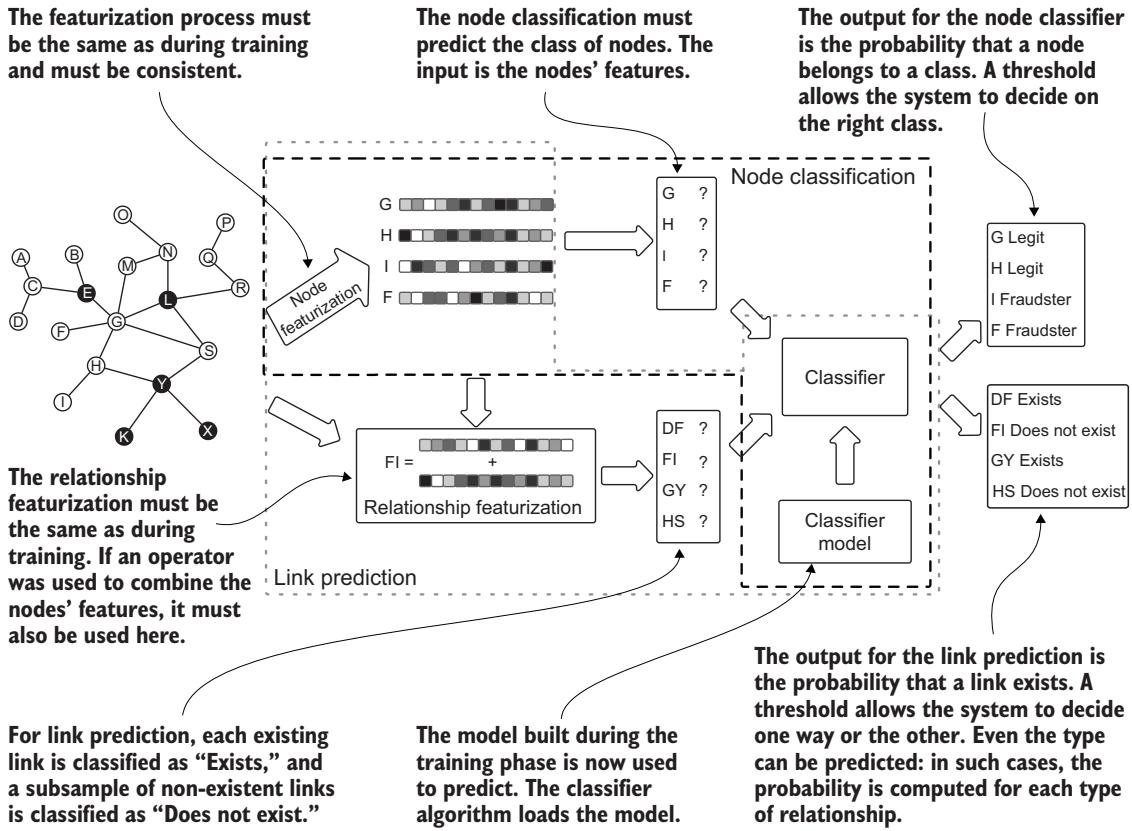

*그림 10.4 — 9장에서 가져온 그림. 위쪽은 노드 분류(노드 특징화 → 분류기 → 클래스 확률), 아래쪽은 링크 예측이다. 둘의 유일한 차이가 왼쪽 아래 "Relationship featurization" 상자에 있다 — 두 노드의 벡터를 연산자로 **합쳐** 하나의 링크 벡터를 만든다. 그 뒤는 노드 분류와 똑같은 분류기다. 오른쪽 위 주석대로 특징화는 학습 때와 예측 때가 **반드시 같아야** 하고, 연산자를 썼다면 그 연산자도 같아야 한다.*

노드 분류와의 핵심 차이는 입력이 **노드 쌍** 이라는 것이다. 그러므로 노드 쌍 사이의 **가능한 연결** 을 효과적으로 표현하는 방법이 필요하다. 접근은 둘이다.

| 접근 | 무엇을 쓰나 | 궁합 | 이 노트북 |
| --- | --- | --- | --- |
| **노드 기반 결합(node-based combination)** | 출발·도착 노드의 특징 벡터를 연산자로 합친다 | 노드 임베딩(11장)과 좋다 | 10.2.1 · 책 10.14 |
| **경로 기반 특징(path-based features)** | 두 노드가 그래프에서 **어떻게 이어져 있는지** 를 분석한다 | 복잡한 네트워크 패턴을 잡는다 | 10.2.2 · 책 10.15\~10.17 |

두 접근의 관계는 절 끝에서 다시 정리한다. 미리 말하면 **노드 기반 결합은 이 장의 수동 노드 특징과 함께 쓰면 성능이 나쁘고, 11장의 자동 임베딩과 함께 쓸 때 살아난다.** 책이 그렇게 못 박고, 그 이유가 이 절을 11장의 예고편으로 만든다.


### 10.2.1 노드 기반 표현 — 두 노드의 지문을 합치기

가장 직관적인 접근은 두 노드의 특징 벡터를 하나로 합치는 것이다. 각 노드는 자신을 설명하는 지문 $\mathbf{u}, \mathbf{v} \in \mathbb{R}^n$ 을 갖고 있고, 이 둘을 합쳐 "그 사이의 연결이 어떤 모습일지"를 기술한다. 중요한 성질은 **두 노드가 실제로 연결돼 있든 아니든 어떤 쌍에 대해서도 계산된다** 는 것이다. 링크 예측은 존재하는 연결과 아직 없는 연결을 모두 평가해야 하기 때문이다.

| 연산자 | 정의 | 출력 차원 | 예: $\mathbf{u} = [1, 4]$, $\mathbf{v} = [3, 1]$ |
| --- | --- | --- | --- |
| **이어붙이기(Catenate)** | $[\,\mathbf{u}; \mathbf{v}\,]$ | $2n$ | $[1, 4, 3, 1]$ |
| **평균(Average)** | $\dfrac{\mathbf{u} + \mathbf{v}}{2}$ | $n$ | $[2, 2.5]$ |
| **L1 (맨해튼 거리)** | $\lvert \mathbf{u} - \mathbf{v} \rvert$ | $n$ | $[2, 3]$ |
| **L2 (유클리드 거리)** | $(\mathbf{u} - \mathbf{v})^2$ | $n$ | $[4, 9]$ |
| **아다마르 곱(Hadamard)** | $\mathbf{u} \odot \mathbf{v}$ | $n$ | $[3, 4]$ |

성질이 셋으로 갈린다.

- **이어붙이기** 는 정보를 하나도 잃지 않지만 차원이 두 배가 되고, **비대칭** 이다 — $(\mathbf{u}, \mathbf{v})$ 와 $(\mathbf{v}, \mathbf{u})$ 가 다른 벡터가 된다. 방향 있는 관계에는 필요한 성질이고, 무향 관계에서는 학습 데이터를 두 배로 늘려야 하는 부담이 된다.
- **평균 · 아다마르** 는 대칭이고 차원을 유지한다. 아다마르는 두 값이 곱셈적으로 결합하는 양(예: 확률, 활성도)일 때 적절하다. 한쪽이 0 이면 결과가 0 이 되는 성질이 신호가 되기도 하고 정보 손실이 되기도 한다.
- **L1 · L2** 는 **비유사성** 을 잰다. 두 노드가 얼마나 다른지가 링크의 근거일 때(예: 이질적 노드끼리 이어지는 이분 그래프) 유용하다. L2 는 제곱하므로 큰 차이를 더 강조한다.

어떤 것을 골라야 하는지에 대한 일반 규칙은 없다. **벤치마크를 돌려 보는 수밖에 없다.** 링크 예측의 품질은 결국 노드 표현의 품질에 직접 달려 있고, 결합 방식은 그 위에 얹히는 두 번째 요인이다.

In [14]:
"""책 10.14 — 두 노드 표현을 하나의 링크 표현으로 합치는 연산자 다섯 개.

이 리스팅은 6줄짜리 함수 다섯 개가 전부다. 그런데 그 짧은 코드에 함정이 둘 있다.

  1. `import numpy as np` 가 없다. operator_l1 / operator_l2 를 호출하면 NameError 다.
     책 지면에서는 앞 리스팅의 import 가 이어진다고 보지만, 파일 하나만 임포트하면 깨진다.
  2. **입력 타입이 함수마다 다르다.** catenate(u, v) = u + v 는 파이썬 **리스트** 에서만
     이어붙이기가 되고 numpy 배열에서는 원소별 덧셈이 된다. 반대로 operator_avg 는
     (u + v) / 2.0 이므로 리스트에서는 TypeError 다. 즉 다섯 함수를 같은 입력으로
     한꺼번에 부를 수 없다.

아래에서 두 함정을 재현해 보이고, 그 다음 numpy 로 통일한 판으로 표의 예시 값을
검산한다. 원본 파일은 고치지 않는다.
"""
show("10.14")

combine = load("10.14")

print("\n=== 함정 1: numpy import 누락 ===")
try:
    combine.operator_l1(np.array([1, 4]), np.array([3, 1]))
except NameError as exc:
    print(f"   operator_l1(...) -> NameError: {exc}")
    print("   책 지면에서는 앞 리스팅의 import 가 이어지지만, 파일만 임포트하면 깨진다.")

print("\n=== 함정 2: 함수마다 기대하는 입력 타입이 다르다 ===")
print(f"   catenate([1,4], [3,1])           = {combine.catenate([1, 4], [3, 1])}"
      f"   <- 리스트여야 이어붙이기가 된다")
print(f"   catenate(np[1,4], np[3,1])       = {combine.catenate(np.array([1, 4]), np.array([3, 1]))}"
      f"   <- numpy 면 원소별 덧셈이 되어 버린다")
try:
    combine.operator_avg([1, 4], [3, 1])
except TypeError as exc:
    print(f"   operator_avg([1,4], [3,1])       -> TypeError: {exc}")
    print("                                       <- 이쪽은 반대로 numpy 여야 한다")

print("\n=== 다섯 연산자를 numpy 로 통일해 표의 예시 값 검산 ===")
u, v = np.array([1, 4]), np.array([3, 1])
OPERATORS = {
    "catenate  (2n 차원, 비대칭)": lambda a, b: np.concatenate([a, b]),
    "average   (n 차원, 대칭)":    lambda a, b: (a + b) / 2.0,
    "L1        (n 차원, 대칭)":    lambda a, b: np.abs(a - b),
    "L2        (n 차원, 대칭)":    lambda a, b: (a - b) ** 2,
    "hadamard  (n 차원, 대칭)":    lambda a, b: a * b,
}
print(f"   u = {u},  v = {v}")
for label, fn in OPERATORS.items():
    fwd, bwd = fn(u, v), fn(v, u)
    sym = "대칭" if np.array_equal(fwd, bwd) else "비대칭 (u,v) != (v,u)"
    print(f"   {label:<28} {str(fwd):<16} {sym}")

# 10.1 절에서 만든 16차원 노드 벡터에 실제로 적용해 본다. 링크 예측을 학습시키지는
# 않는다 - 이 예제 그래프에는 예측할 링크 타입이 하나뿐이고 노드가 20개뿐이다.
print("\n=== 10.1 절의 16차원 노드 벡터에 적용 (D-F 쌍: 둘 다 사기꾼, 실제로 연결됨) ===")
X = features_df.drop("is_fraudster", axis=1)
u_d, v_f = X.loc["D"].to_numpy(float), X.loc["F"].to_numpy(float)
for label, fn in OPERATORS.items():
    out = fn(u_d, v_f)
    print(f"   {label:<28} dim={out.shape[0]:<3} 앞 5개 {np.round(out[:5], 2)}")
print("\n   비교 — C-R 쌍 (둘 다 잎 노드, 연결 없음), 아다마르 곱:")
print("   ", np.round(OPERATORS["hadamard  (n 차원, 대칭)"](
    X.loc["C"].to_numpy(float), X.loc["R"].to_numpy(float)), 3))
print("   -> 두 잎 노드의 아다마르 곱은 대부분의 축에서 0 에 가깝다. 특징이 희소하면")
print("      곱셈 결합은 정보를 대부분 버린다. 이것이 '수동 특징 + 노드 기반 결합' 의")
print("      성능이 나쁜 이유 중 하나다 — 수동 특징 벡터는 0 이 많고 축마다 스케일이")
print("      다르다. 11장의 밀집 임베딩에서는 이 문제가 사라진다.")


── 책 Listing 10.14  Combining two node representations into one link representation
   출처: 12.14 How to combine two nodes representation in one link representation.py  L1-L18  (파일 전체)
    def catenate(u, v):
        return u + v
    
    
    def operator_avg(u, v):
        return (u + v) / 2.0
    
    
    def operator_l1(u, v):
        return np.abs(u - v)
    
    
    def operator_l2(u, v):
        return (u - v) ** 2
    
    
    def operator_hadamard(u, v):
        return u * v

=== 함정 1: numpy import 누락 ===
   operator_l1(...) -> NameError: name 'np' is not defined
   책 지면에서는 앞 리스팅의 import 가 이어지지만, 파일만 임포트하면 깨진다.

=== 함정 2: 함수마다 기대하는 입력 타입이 다르다 ===
   catenate([1,4], [3,1])           = [1, 4, 3, 1]   <- 리스트여야 이어붙이기가 된다
   catenate(np[1,4], np[3,1])       = [4 5]   <- numpy 면 원소별 덧셈이 되어 버린다
   operator_avg([1,4], [3,1])       -> TypeError: unsupported operand type(s) for /: 'list' and 'float'
                                       <- 이쪽은 반대로 numpy 여야 한다

=== 다섯 연산자를 numpy 로 통일해

### 10.2.2 경로 기반 특징 — 메타경로로 약과 질병을 잇기

노드 벡터를 합치는 대신, **두 노드가 어떻게 이어져 있는지** 로 관계를 기술할 수도 있다. 이 방식은 대체로 **도메인 특화** 라 손일이 필요하다. 도메인과 목표를 이해해야 어떤 연결 패턴이 의미 있는지 정할 수 있기 때문이다.

예제는 **약물 재창출(drug repurposing)** — 기존 약의 새 용도를 찾는 일이다. 화합물(compound)과 질병(disease) 사이의 링크 예측으로 모델링한다. 데이터는 4장에서 만든 **Hetionet** 이다.

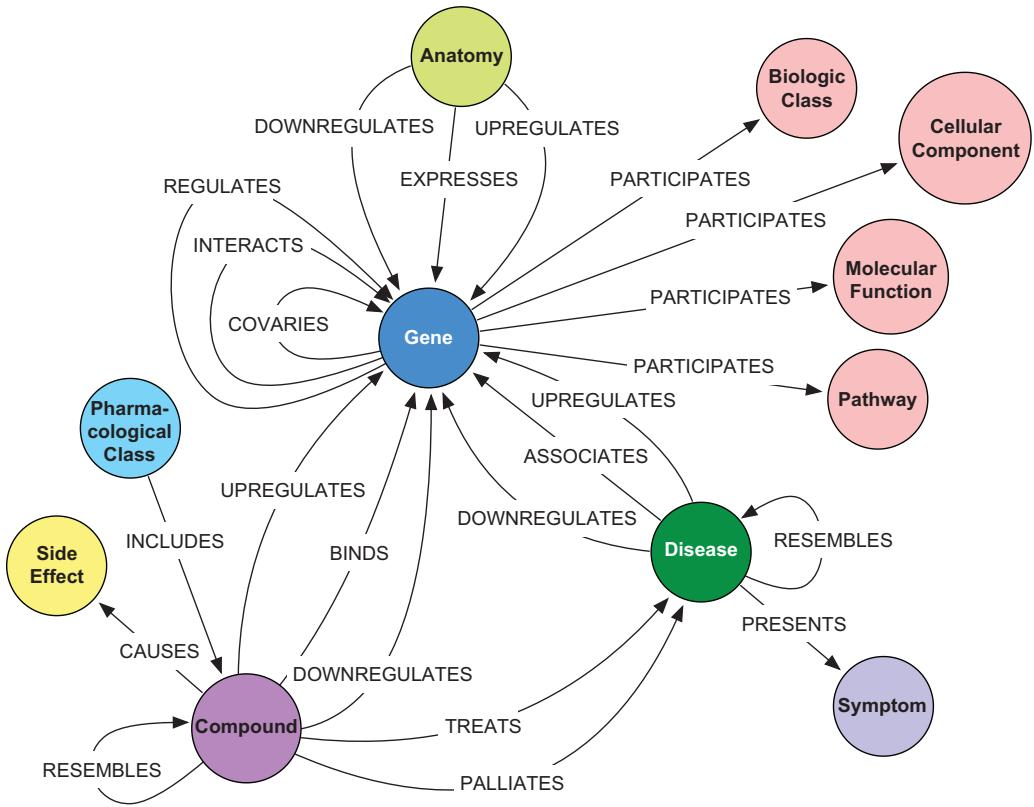

*그림 10.5 — 4장에서 본 Hetionet 스키마를 다시 실은 것. `Compound` · `Gene` · `Disease` · `Anatomy` · `Pathway` 등 11종의 노드 유형과 `BINDS` · `ASSOCIATES` · `EXPRESSES` · `PARTICIPATES` · `TREATS` 같은 관계 유형이 있다. 아래 메타경로들은 이 스키마 위의 경로 패턴이므로, 쿼리를 읽을 때 이 그림에서 화살표를 따라가 보면 된다.*

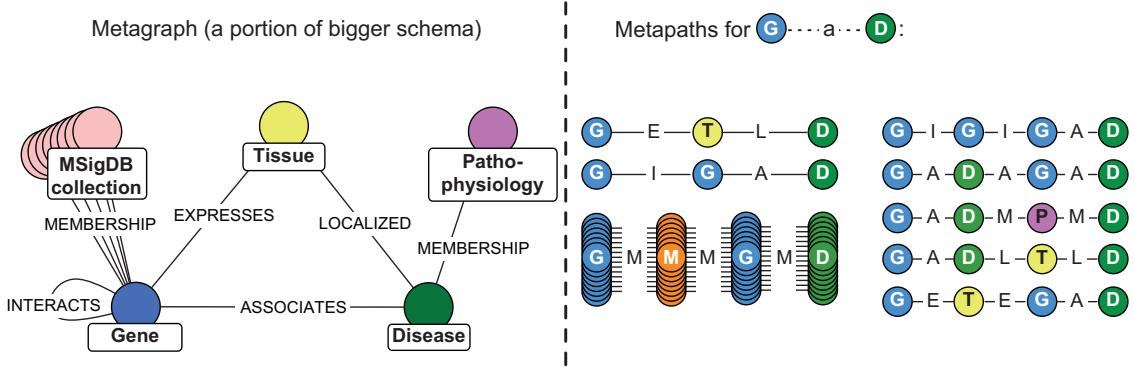

*그림 10.6 — 왼쪽이 **메타그래프**(스키마의 부분), 오른쪽이 그 위에서 정의되는 **메타경로** 들이다. 메타경로는 실제 경로가 아니라 **노드 유형과 관계 유형의 순서열** 이다. "역—지하철—역"이라는 이동 패턴을 말하는 것이지 특정 노선을 가리키는 게 아니다.*

Himmelstein 등은 Hetionet 으로 화합물–질병 쌍의 **네트워크 연결성을 치료 확률로 번역** 하는 모델을 학습시켰다. 각 쌍에 대해 길이 2\~4 인 모든 메타경로를 평가했다. 표 10.8 이 그 일부다.

| 메타경로 | 길이 | 약어 |
| --- | --- | --- |
| Compound–binds–Gene–associates–Disease | 2 | **CbGaD** |
| Compound–downregulates–Gene–upregulates–Disease | 2 | CdGuD |
| Compound–resembles–Compound–treats–Disease | 2 | CrCtD |
| Compound–binds–Gene–binds–Compound–treats–Disease | 3 | CbGbCtD |
| Compound–binds–Gene–expresses–Anatomy–localizes–Disease | 3 | **CbGeAlD** |
| Compound–binds–Gene–interacts–Gene–interacts–Gene–associates–Disease | 4 | CbGiGiGaD |
| Compound–binds–Gene–participates–Pathway–participates–Gene–associates–Disease | 4 | **CbGpPWpGaD** |

굵게 표시한 셋이 아래 리스팅 10.15 · 10.16 · 10.17 이 계산하는 메타경로다. 이 메타경로들은 **직접 연결이 있든 없든 모든 화합물–질병 쌍에 대해 값을 갖는다** — 그것이 특징이 되는 이유다.

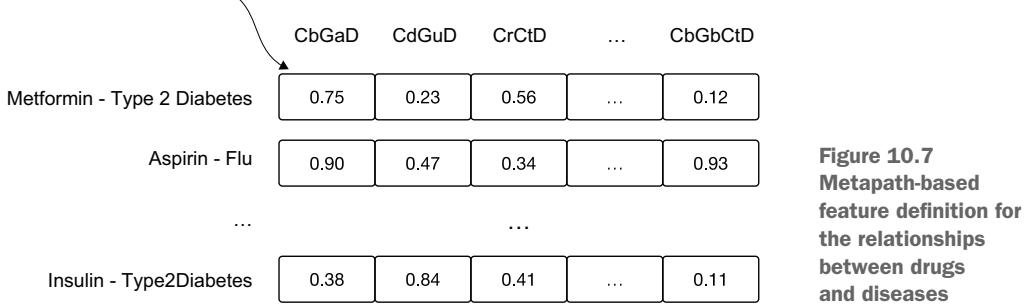

*그림 10.7 — 메타경로 기반 특징 정의. 행이 화합물–질병 쌍(Metformin–Type 2 Diabetes, Aspirin–Flu, …), 열이 메타경로(CbGaD, CdGuD, CrCtD, …)다. 각 칸이 그 쌍·그 메타경로의 값이고, 한 행 전체가 곧 **그 관계의 특징 벡터** 다. 10.1 절이 노드마다 16차원 벡터를 만든 것과 정확히 같은 구조인데, 대상이 노드가 아니라 쌍이고 축이 지표가 아니라 메타경로다.*

### 왜 경로를 그냥 세면 안 되는가 — DWPC

가장 단순한 값은 **경로 인스턴스 수(PC, path count)** 다. 그런데 연결이 아주 많은 노드가 그 수를 지배한다. 어떤 유전자가 수많은 생물학적 과정에 관여하면 자연히 더 많은 경로에 등장하지만, 그것이 그 화합물과 질병 사이에 더 강한 관계가 있음을 뜻하지는 않는다.

**DWPC(degree-weighted path count, 차수 가중 경로 수)** 가 이 편향을 바로잡는다. 각 경로를 중간 노드들의 차수에 **반비례** 하게 가중해, 연결이 많은 노드는 최종 점수에 덜 기여하게 만든다.

> **DWPC 의 정의와 유도는 [4장 노트북](../../../chapter_04_from_simple_networks_to_multisource_integration/src/ch04/04_chapter_guide.ipynb) 의 4.3 절에서 이미 다뤘다.** PDP(경로-차수 곱), 감쇠 지수 $w$, "엣지 하나가 차수 두 개를 기여한다"는 규칙, 그리고 셀리악병 GO 과정에서 PC 정렬과 DWPC 정렬이 어떻게 달라지는지까지 그쪽에 있다. 여기서는 반복하지 않는다.

**이 장이 4장과 다른 점은 DWPC 를 무엇에 쓰느냐** 다.

| | 4장 | 10장 |
| --- | --- | --- |
| 대상 | 질병 하나(셀리악병)에 대해 **GO 과정들의 순위** 를 매긴다 | 화합물–질병 쌍의 **특징 벡터 한 칸** 을 만든다 |
| 메타경로 | 분석자가 고른 하나(또는 둘)를 정교화한다 | 길이 2\~4 인 **모든** 메타경로를 축으로 삼는다 |
| 출력 | 사람이 읽는 순위표 | 분류기에 들어가는 숫자 |
| 감쇠 지수 | $w = 0.4$ | $w = 0.4$ (같다) |

즉 4장에서는 DWPC 가 **분석의 결론** 이었고, 10장에서는 **특징 공학의 한 축** 이다. 그래서 이 절에서 중요한 것은 값 하나의 크기가 아니라 "메타경로마다 쿼리를 하나씩 써야 하고, 그것이 곧 수동 특징 공학의 비용"이라는 사실이다. Himmelstein 등이 메타경로를 1,026개에서 709개로 줄이고(**메타경로 축소**), 유망한 쌍만 골라내는(**쌍 선택**) 2단계 접근을 개발한 이유가 그 비용에 있다.

> **⚠️ 책 리스팅 10.15 에는 버그가 있다.** 차수 계산의 첫 항이 **어디에도 바인딩되지 않은 변수 `v`** 를 쓴다. 10.16 · 10.17 은 같은 자리에 `c` 를 쓰므로 10.15 만 어긋난다. 아래 셀에서 원문 그대로 실행한 값과 `v` → `c` 로 고쳐 실행한 값을 나란히 낸다.

In [15]:
"""책 10.15 — CbGaD 메타경로의 DWPC. **원문의 버그를 수치로 확인한다.**

문제의 줄:

    count{(v)-[:BINDS_CbG]-()},     // v 는 이 쿼리 어디에도 바인딩되지 않았다
    count{()-[:BINDS_CbG]-(g)},

MATCH 절이 바인딩하는 변수는 c · g · d 뿐이다. Cypher 의 count{} 부분 패턴에서
바인딩되지 않은 변수는 **새 변수** 로 취급되어 전체 그래프를 훑는다. 그래서 첫 항이
'Metformin 의 BINDS 차수'가 아니라 '그래프 전체의 BINDS 관계 수 × 2' 가 된다.

DWPC 는 각 차수를 d^(-0.4) 로 감쇠해 곱하므로, 첫 항이 부풀면 PDP 전체가 눌린다.
PC 는 영향받지 않는다 (경로 수는 그대로다).

10.16 · 10.17 은 같은 자리에 c 를 쓴다. 즉 세 리스팅 중 10.15 하나만 어긋난다.
업스트림 파일은 고치지 않고 run_cypher(..., replace=...) 로 문자열만 바꿔 실행한다.
"""
if not HAS_HETIONET:
    print("hetionet DB 가 없어 건너뛴다. 4장 노트북의 책 4.16 을 먼저 실행하라.")
else:
    show("10.15")

    # 1) 원문 그대로
    rows_buggy = run_cypher("10.15")

    # 2) v -> c 로 고친 판
    rows_fixed = run_cypher("10.15", replace=("count{(v)-[:BINDS_CbG]-()}",
                                              "count{(c)-[:BINDS_CbG]-()}"))

    # 3) 두 차수 표현이 실제로 무엇을 세는지 직접 확인
    with cypher.driver() as drv, drv.session(database=HETIONET_DB) as s:
        deg_c = s.run("MATCH (c:Compound {name:'Metformin'}) "
                      "RETURN count{(c)-[:BINDS_CbG]-()} AS n").single()["n"]
        deg_v = s.run("RETURN count{(v)-[:BINDS_CbG]-()} AS n").single()["n"]
        n_binds = s.run("MATCH ()-[r:BINDS_CbG]->() RETURN count(r) AS n").single()["n"]

    print("\n=== 차수 표현이 실제로 세는 것 ===")
    print(f"   count{{(c)-[:BINDS_CbG]-()}}  (c = Metformin, 의도된 값) = {deg_c:,}")
    print(f"   count{{(v)-[:BINDS_CbG]-()}}  (v = 바인딩 없음, 실제 동작) = {deg_v:,}")
    print(f"   참고: 그래프 전체 BINDS_CbG 관계 수 = {n_binds:,}  (양방향으로 세면 "
          f"{2 * n_binds:,})")

    b, f = rows_buggy[0], rows_fixed[0]
    print("\n=== 두 판의 결과 ===")
    print(f"{'':<12}{'PC':>6}{'DWPC':>14}")
    print(f"{'원문(v)':<12}{b['PC']:>6}{b['DWPC']:>14.7f}   <- 책 본문이 말하는 0.0007")
    print(f"{'수정(c)':<12}{f['PC']:>6}{f['DWPC']:>14.7f}")
    print(f"\n   PC 는 같다({b['PC']}) — 경로 수는 버그의 영향을 받지 않는다.")
    print(f"   DWPC 는 {f['DWPC'] / b['DWPC']:.1f}배 차이난다. 첫 차수가 "
          f"{deg_c} 대신 {deg_v:,} 로 들어가면 PDP 가 "
          f"({deg_v} / {deg_c})^-0.4 = {(deg_v / deg_c) ** -0.4:.4f} 배로 눌리기 때문이다.")
    print("\n   책 본문은 '이 쿼리를 실행하면 0.0007 을 얻는다'고 적는다. 그 값은 위의")
    print("   원문(버그 포함) 판과 일치한다. 즉 책에 실린 수치 자체가 버그가 낳은 값이다.")
    print("   메타경로 사이를 비교하려면 모든 메타경로가 같은 규칙으로 계산돼야 하는데,")
    print("   10.15 만 다른 규칙을 쓰므로 CbGaD 축이 다른 축들과 스케일이 맞지 않는다.")

── 책 Listing 10.15  DWPC between metformin and type 2 diabetes for CbGaD
   출처: 12.15 DWPC between Metformin and Type 2 Diabetes for the CbGaD  L1-L17  (파일 전체)
    MATCH path = (c:Compound)-[:BINDS_CbG]-(g)-[:ASSOCIATES_DaG]-(d:Disease)
    WHERE c.name = 'Metformin' AND d.name = 'type 2 diabetes mellitus'
    WITH
    [
      count{(v)-[:BINDS_CbG]-()},
      count{()-[:BINDS_CbG]-(g)},
      count{(g)-[:ASSOCIATES_DaG]-()},
      count{()-[:ASSOCIATES_DaG]-(d)}
    ]
    AS degrees, path, d
    WITH
      d.identifier AS disease_id,
      d.name AS disease_name,
      count(path) AS PC,
      sum(reduce(pdp = 1.0, d in degrees| pdp * d ^ -0.4)) AS DWPC
    RETURN
      disease_id, disease_name, PC, DWPC


책 10.15 [hetionet]: 0.05초, 1행
    {'disease_id': 'DOID:9352', 'disease_name': 'type 2 diabetes mellitus', 'PC': 1, 'DWPC': 0.000703}
책 10.15 [hetionet]  (치환 실행): 0.00초, 1행
    {'disease_id': 'DOID:9352', 'disease_name': 'type 2 diabetes mellitus', 'PC': 1, 'DWPC': 0.007822}



=== 차수 표현이 실제로 세는 것 ===
   count{(c)-[:BINDS_CbG]-()}  (c = Metformin, 의도된 값) = 56
   count{(v)-[:BINDS_CbG]-()}  (v = 바인딩 없음, 실제 동작) = 23,142
   참고: 그래프 전체 BINDS_CbG 관계 수 = 11,571  (양방향으로 세면 23,142)

=== 두 판의 결과 ===
                PC          DWPC
원문(v)            1     0.0007028   <- 책 본문이 말하는 0.0007
수정(c)            1     0.0078220

   PC 는 같다(1) — 경로 수는 버그의 영향을 받지 않는다.
   DWPC 는 11.1배 차이난다. 첫 차수가 56 대신 23,142 로 들어가면 PDP 가 (23142 / 56)^-0.4 = 0.0898 배로 눌리기 때문이다.

   책 본문은 '이 쿼리를 실행하면 0.0007 을 얻는다'고 적는다. 그 값은 위의
   원문(버그 포함) 판과 일치한다. 즉 책에 실린 수치 자체가 버그가 낳은 값이다.
   메타경로 사이를 비교하려면 모든 메타경로가 같은 규칙으로 계산돼야 하는데,
   10.15 만 다른 규칙을 쓰므로 CbGaD 축이 다른 축들과 스케일이 맞지 않는다.


In [16]:
"""책 10.16 · 10.17 — 길이 3 과 길이 4 메타경로의 DWPC. 10.15 의 버그가 없는지 확인한다.

10.16 CbGeAlD: Compound -BINDS- Gene <-EXPRESSES- Anatomy <-LOCALIZES- Disease
10.17 CbGpPWpGaD: Compound -BINDS- Gene1 -PARTICIPATES-> Pathway
                  <-PARTICIPATES- Gene2 -ASSOCIATES- Disease

두 쿼리 모두 구조는 10.15 와 같다. 다른 것은 degrees 리스트의 길이뿐이다 —
메타엣지 하나가 차수 두 개(양 끝점)를 기여하므로 길이 3 이면 6개, 길이 4 면 8개다.

`<-` 화살표는 관계 방향이 반대라는 뜻이다. Hetionet 의 EXPRESSES_AeG 는
Anatomy -> Gene 방향이라 Gene 쪽에서 보면 들어오는 화살표가 된다.

읽기 어려운 관용구가 하나 있다. reduce 의 루프 변수가 `d` 인데 바깥에 이미 Disease
노드 `d` 가 바인딩돼 있다. Cypher 에서 reduce 의 루프 변수는 새 스코프를 만들므로
동작에는 문제가 없지만, 같은 이름을 재사용해 가독성을 크게 해친다.

원문에서 10.17 이 10.16 보다 **먼저** 나온다 (책 레이아웃 오류). 여기서는 번호 순으로 싣는다.
"""
if not HAS_HETIONET:
    print("hetionet DB 가 없어 건너뛴다.")
else:
    # 세 쿼리의 차수 표현에 바인딩되지 않은 변수가 있는지 기계적으로 점검한다.
    print("=== 세 리스팅의 count{} 안 변수가 MATCH 에 바인딩됐는지 점검 ===")
    for book_no in ("10.15", "10.16", "10.17"):
        text = source_of(book_no)
        # MATCH 패턴이 바인딩하는 변수: 라벨이 붙은 것과 안 붙은 것을 모두 잡는다.
        # 10.15 의 (g) 는 라벨이 없으므로 라벨만 보는 정규식으로는 놓친다.
        match_line = next(l for l in text.splitlines() if l.startswith("MATCH"))
        bound = set(re.findall(r"\((\w+)[:)]", match_line))
        used = {m for m in re.findall(r"count\{\(*(\w+)\)", text) if m}
        unbound = sorted(used - bound)
        print(f"   {book_no}: 바인딩 {sorted(bound)}  ·  count{{}} 사용 {sorted(used)}"
              f"  -> 미바인딩 {unbound if unbound else '없음'}")

    print()
    rows_16 = run_cypher("10.16")
    print()
    rows_17 = run_cypher("10.17")

    print("\n=== 메트포르민–제2형 당뇨병의 메타경로 특징 벡터 (그림 10.7 의 한 행) ===")
    print(f"{'메타경로':<14}{'길이':>4}{'PC':>8}{'DWPC':>12}   비고")
    vector = [
        ("CbGaD", 2, rows_buggy[0], "원문 10.15 (버그 포함) — 다른 축과 스케일이 다르다"),
        ("CbGaD*", 2, rows_fixed[0], "v -> c 수정판"),
        ("CbGeAlD", 3, rows_16[0], ""),
        ("CbGpPWpGaD", 4, rows_17[0], ""),
    ]
    for name, length, row, note in vector:
        print(f"{name:<14}{length:>4}{row['PC']:>8}{row['DWPC']:>12.6f}   {note}")
    print("\n   읽는 법: 길이가 길어질수록 PC 가 폭증한다 (1 -> 340 -> 5,277). 그런데 DWPC 는")
    print("   그만큼 커지지 않는다 (0.0078 -> 0.036 -> 0.094). 감쇠가 실제로 작동하고 있다는")
    print("   뜻이다 — 긴 경로일수록 곱해지는 d^-0.4 항이 많아 각 경로의 기여가 작아진다.")
    print("   이 네 숫자가 그림 10.7 한 행의 앞부분이고, 이런 축을 700개 넘게 모으면")
    print("   Himmelstein 등이 실제로 쓴 특징 벡터가 된다.")

=== 세 리스팅의 count{} 안 변수가 MATCH 에 바인딩됐는지 점검 ===
   10.15: 바인딩 ['c', 'd', 'g']  ·  count{} 사용 ['g', 'v']  -> 미바인딩 ['v']
   10.16: 바인딩 ['a', 'c', 'd', 'g']  ·  count{} 사용 ['a', 'c', 'g']  -> 미바인딩 없음
   10.17: 바인딩 ['c', 'd', 'g1', 'g2', 'pw']  ·  count{} 사용 ['c', 'g1', 'g2', 'pw']  -> 미바인딩 없음

책 10.16 [hetionet]: 0.01초, 1행
    {'disease_id': 'DOID:9352', 'disease_name': 'type 2 diabetes mellitus', 'PC': 340, 'DWPC': 0.036168}

책 10.17 [hetionet]: 0.02초, 1행
    {'disease_id': 'DOID:9352', 'disease_name': 'type 2 diabetes mellitus', 'PC': 5277, 'DWPC': 0.094077}

=== 메트포르민–제2형 당뇨병의 메타경로 특징 벡터 (그림 10.7 의 한 행) ===
메타경로            길이      PC        DWPC   비고
CbGaD            2       1    0.000703   원문 10.15 (버그 포함) — 다른 축과 스케일이 다르다
CbGaD*           2       1    0.007822   v -> c 수정판
CbGeAlD          3     340    0.036168   
CbGpPWpGaD       4    5277    0.094077   

   읽는 법: 길이가 길어질수록 PC 가 폭증한다 (1 -> 340 -> 5,277). 그런데 DWPC 는
   그만큼 커지지 않는다 (0.0078 -> 0.036 -> 0.094). 감쇠가 실제로 작동하고 있다는
   뜻이다 — 

### 그래프 특징 공학에 LLM 활용하기

메타경로마다 Cypher 를 하나씩 손으로 쓰는 일이 이 접근의 실질적 비용이다. 쿼리를 짜려면 **도메인과 쿼리 언어 양쪽** 을 알아야 한다. LLM 은 바로 그 번역 작업에 강하다.

| 역할 | 하는 일 |
| --- | --- |
| **쿼리 생성** | 메타경로에 대한 고수준 설명을 최적화된 Cypher 로 옮긴다 |
| **특징 공학** | 곧바로 눈에 띄지 않는 관련 패턴과 관계를 제안한다 |
| **코드 생성** | 쿼리 결과를 실행·처리하는 인프라를 만든다 |

이 책이 반복하는 비유대로, LLM 은 박학다식하지만 가끔 지어내는 달변가다. **정확한 스키마와 검증된 예시 쿼리를 사실의 발판으로 쥐여 주면** 지어내는 대신 정확한 쿼리를 낸다. 저장소의 `listings/12.18` 이 그 프롬프트다 — 책은 이것을 사이드바 인용문으로 싣고 번호를 주지 않았다.

프롬프트가 발판으로 제공하는 것은 넷이다.

1. `apoc.meta.schema()` 로 얻은 그래프 스키마
2. CbGaD 에 대한 **검증된 예시 쿼리** (책 10.15 의 원문)
3. Compound–Disease 사이 메타경로 목록
4. 테스트용 화합물·질병 이름

> **이 프롬프트는 실행하지 않는다.** 두 가지 이유다. 첫째, 이 장은 LLM 을 쓰는 장이 아니라 특징을 손으로 설계하는 장이고, 프롬프트는 "이렇게도 할 수 있다"는 곁가지다. 둘째이자 더 중요한 이유 — **프롬프트에 심어 넣은 예시가 바로 버그 있는 10.15 다.** 아래 셀이 그것을 보인다. LLM 에게 잘못된 발판을 주면 생성되는 모든 메타경로 쿼리가 같은 실수를 복제한다. "예시를 발판으로 준다"는 전략의 전제는 **예시가 옳다는 것** 이고, 그 검증은 사람 몫으로 남는다.

In [17]:
"""저장소 12.18 (책에는 번호가 없다) — 메타경로 Cypher 생성 프롬프트.

실행하지 않고 원문만 싣는다. 대신 프롬프트 안의 예시 쿼리가 앞에서 확인한 버그를
그대로 담고 있는지 기계적으로 확인한다. 이것이 이 셀의 요점이다.
"""
prompt_path = HERE / "listings" / "12.18 Prompt to generate queries for extracting DWTC features"
prompt_text = prompt_path.read_text(encoding="utf-8")

print(f"── {prompt_path.name}  ({len(prompt_text.splitlines())}줄) ──")
for line in prompt_text.splitlines():
    print("   ", line)

print("\n=== 프롬프트에 심어 넣은 예시 쿼리 점검 ===")
BUG = "count{(v)-[:BINDS_CbG]-()}"
print(f"   프롬프트가 버그 있는 차수 표현을 포함하는가: "
      f"{'예 — ' + BUG if BUG in prompt_text else '아니오'}")
print(f"   책 10.15 원문에 같은 표현이 있는가: {BUG in source_of('10.15')}")
print("\n   -> 프롬프트는 10.15 를 '검증된 예시'로 제시하지만 그 예시에 버그가 있다.")
print("      LLM 은 예시의 형태를 따라가므로, 생성되는 CdGuD·CrCtD·CbGbCtD 쿼리들도")
print("      같은 자리에 바인딩 없는 변수를 쓸 가능성이 높다. 그러면 메타경로 축마다")
print("      스케일이 제각각인 특징 행렬이 나온다.")
print("      LLM 을 쓸 때 사람이 지켜야 할 자리가 어디인지 보여주는 사례다 — 발판의 검증이다.")
print("\n   프롬프트 자체의 사소한 흠도 둘 있다: 항목 번호가 '1. 1. 2. 3.' 으로 어긋나고,")
print("   'Shema'·'attachement' 오타가 있다. 실행에 지장은 없다.")

── 12.18 Prompt to generate queries for extracting DWTC features  (37줄) ──
    You are a graph database expert specializing in Neo4j and Cypher queries. I'm working on a drug repurposing project and need help generating queries for metapath analysis.
    
    I'll provide you with:
    1.  The graph schema (obtained from apoc.meta.schema())
    1. An example of the query for CbGaD
    2.  A list of metapaths between Compound and Disease nodes
    3.  Sample compound and disease names for testing
    For each metapath:
    - Generate a Cypher query that computes both Path Count (PC) and Degree-Weighted Path Count (DWPC, using damping factor 0.4)
    - Include degree calculations for each node in the path
    - Return disease_id, disease_name, PC, and DWPC
    
    The schema is:
    {Shema definition here or as attachement}
    
    An example of the query for DWPC is:
    MATCH path = (c:Compound)-[:BINDS_CbG]-(g)-[:ASSOCIATES_DaG]-(d:Disease)
    WHERE c.name = 'Metformin' AND d.name 

### 실습 10-C — 다른 화합물·다른 메타경로로 DWPC 를 계산해 보기

> **해설판 10.2.2 절 연습 문제** — "리스트 10.15의 쿼리를 다른 화합물과 질병에 대해, **직접 연결이 있는 경우와 없는 경우 모두** 를 고려해 실행해 보십시오. 그런 다음 쿼리를 바꿔 다른 메타경로들도 시험해 보십시오."

지문이 "직접 연결이 있는 경우와 없는 경우"를 명시한 것이 요점이다. 메타경로 특징이 쓸모 있으려면 **치료 관계가 알려진 쌍과 그렇지 않은 쌍에서 값이 달라야** 한다. 값이 비슷하다면 그 메타경로는 분류에 기여하지 못한다.

그래서 이 실습은 지문을 다음 셋으로 구체화한다.

1. `type 2 diabetes mellitus` 를 고정하고 화합물 여섯 개를 고른다 — `TREATS_CtD` 관계가 **있는 셋**(Metformin · Glipizide · Rosiglitazone)과 **없는 셋**(Aspirin · Caffeine · Ibuprofen).
2. 메타경로 셋(**CbGaD** · **CdGuD** · **CrCtD**)에 대해 PC 와 DWPC 를 모두 계산한다. 리스팅에 없는 CdGuD · CrCtD 는 표 10.8 의 정의를 보고 직접 쓴다.
3. 값이 두 집단을 가르는지 본다. 그리고 **가른다면 왜 갈랐는지** 를 따진다 — 이 부분이 실습의 진짜 목적이다.

쿼리는 리스팅 10.15 의 형태를 그대로 따르되 두 곳을 고친다. 화합물·질병 이름을 **파라미터** 로 빼고(문자열 조립은 인젝션과 계획 캐시 무효화를 부른다), 앞에서 확인한 **`v` 버그를 `c` 로 고쳐** 세 메타경로가 같은 규칙으로 계산되게 한다. 축마다 규칙이 다르면 애초에 비교가 성립하지 않는다.


In [18]:
"""실습 10-C 풀이 — 화합물 6개 × 메타경로 3개의 PC·DWPC 표를 만든다.

리스팅 10.15 의 형태를 유지하되 세 가지를 바꾼다.

  · 화합물·질병 이름을 $compound / $disease 파라미터로 뺀다. 문자열 조립은
    인젝션을 열고 Neo4j 의 쿼리 계획 캐시를 매번 무효화한다.
  · 첫 차수 항의 v 를 c 로 고친다 (10.2.2 절에서 확인한 버그). 세 메타경로가 같은
    규칙을 써야 값을 나란히 비교할 수 있다.
  · 경로가 하나도 없으면 Cypher 가 0행을 돌려주므로 (PC, DWPC) = (0, 0.0) 으로 채운다.
    '경로가 없다'는 것도 특징 값이다 — 그림 10.7 의 빈칸이 아니라 0 이다.

쿼리 24건(6 화합물 × 3 메타경로 + 치료 관계 확인 6건), 실측 0.2초다.
"""
if not HAS_HETIONET:
    print("hetionet DB 가 없어 건너뛴다. 4장 노트북의 책 4.16 을 먼저 실행하라.")
else:
    DISEASE = "type 2 diabetes mellitus"
    COMPOUNDS = ["Metformin", "Glipizide", "Rosiglitazone",     # TREATS 가 있는 쪽
                 "Aspirin", "Caffeine", "Ibuprofen"]            # 없는 쪽

    # 표 10.8 의 정의를 그대로 Cypher 로 옮긴다. degrees 리스트는 메타엣지마다
    # 양 끝점의 차수 두 개를 넣는다 (4장 노트북 4.3 절의 규칙).
    METAPATHS = {
        "CbGaD": """
            MATCH path = (c:Compound)-[:BINDS_CbG]-(g:Gene)-[:ASSOCIATES_DaG]-(d:Disease)
            WHERE c.name = $compound AND d.name = $disease
            WITH [ count{(c)-[:BINDS_CbG]-()}, count{()-[:BINDS_CbG]-(g)},
                   count{(g)-[:ASSOCIATES_DaG]-()}, count{()-[:ASSOCIATES_DaG]-(d)}
                 ] AS degrees, path, d
            WITH count(path) AS PC,
                 sum(reduce(pdp = 1.0, x IN degrees | pdp * x ^ -0.4)) AS DWPC
            RETURN PC, DWPC""",
        "CdGuD": """
            MATCH path = (c:Compound)-[:DOWNREGULATES_CdG]-(g:Gene)-[:UPREGULATES_DuG]-(d:Disease)
            WHERE c.name = $compound AND d.name = $disease
            WITH [ count{(c)-[:DOWNREGULATES_CdG]-()}, count{()-[:DOWNREGULATES_CdG]-(g)},
                   count{(g)-[:UPREGULATES_DuG]-()}, count{()-[:UPREGULATES_DuG]-(d)}
                 ] AS degrees, path, d
            WITH count(path) AS PC,
                 sum(reduce(pdp = 1.0, x IN degrees | pdp * x ^ -0.4)) AS DWPC
            RETURN PC, DWPC""",
        "CrCtD": """
            MATCH path = (c:Compound)-[:RESEMBLES_CrC]-(c2:Compound)-[:TREATS_CtD]->(d:Disease)
            WHERE c.name = $compound AND d.name = $disease
            WITH [ count{(c)-[:RESEMBLES_CrC]-()}, count{()-[:RESEMBLES_CrC]-(c2)},
                   count{(c2)-[:TREATS_CtD]->()}, count{()-[:TREATS_CtD]->(d)}
                 ] AS degrees, path, d
            WITH count(path) AS PC,
                 sum(reduce(pdp = 1.0, x IN degrees | pdp * x ^ -0.4)) AS DWPC
            RETURN PC, DWPC""",
    }

    started = time.time()
    table = {}
    with cypher.driver() as drv, drv.session(database=HETIONET_DB) as s:
        for compound in COMPOUNDS:
            treats = s.run("MATCH (c:Compound {name:$c})-[:TREATS_CtD]->(d:Disease {name:$d}) "
                           "RETURN count(*) AS n", c=compound, d=DISEASE).single()["n"] > 0
            row = {"treats": treats}
            for name, query in METAPATHS.items():
                rec = s.run(query, compound=compound, disease=DISEASE).single()
                row[name] = (rec["PC"], rec["DWPC"]) if rec and rec["PC"] else (0, 0.0)
            table[compound] = row
    print(f"쿼리 {len(COMPOUNDS) * (len(METAPATHS) + 1)}건, {time.time() - started:.1f}초\n")

    print(f"질병 고정: {DISEASE}")
    print(f"{'화합물':<16}{'TREATS?':<9}"
          + "".join(f"{name + ' PC':>12}{name + ' DWPC':>14}" for name in METAPATHS))
    for compound in COMPOUNDS:
        row = table[compound]
        cells = "".join(f"{row[n][0]:>12}{row[n][1]:>14.6f}" for n in METAPATHS)
        print(f"{compound:<16}{('TREATS' if row['treats'] else '—'):<9}{cells}")

    # 두 집단의 평균으로 각 메타경로의 분리력을 본다.
    print("\n=== 메타경로별 분리력 (TREATS 집단 평균 vs 비TREATS 집단 평균) ===")
    print(f"{'메타경로':<12}{'TREATS 평균':>14}{'비TREATS 평균':>16}  판정")
    pos = [c for c in COMPOUNDS if table[c]["treats"]]
    neg = [c for c in COMPOUNDS if not table[c]["treats"]]
    for name in METAPATHS:
        a = sum(table[c][name][1] for c in pos) / len(pos)
        b = sum(table[c][name][1] for c in neg) / len(neg)
        if a == b == 0:
            verdict = "둘 다 0 — 이 질병에서는 쓸모없는 축"
        elif b == 0:
            verdict = "완전 분리 — 그런데 아래 주의 참고"
        else:
            verdict = f"평균비 {a / b:.2f}배"
        print(f"{name:<12}{a:>14.6f}{b:>16.6f}  {verdict}")

    print("\n읽는 법 세 가지.")
    print("\n1) CbGaD 는 두 집단을 가르지 못한다. Ibuprofen(치료 관계 없음)의 DWPC 가")
    print("   Metformin(치료 관계 있음)보다 오히려 크다. 메타경로 하나로는 부족하고")
    print("   700개 넘는 축을 모아야 분류기가 신호를 뽑아낼 수 있다는 뜻이다.")
    print("   Himmelstein 등이 축소 후에도 709개를 남긴 이유가 여기 있다.")

    with cypher.driver() as drv, drv.session(database=HETIONET_DB) as s:
        n_dug = s.run("MATCH (d:Disease {name:$d})-[:UPREGULATES_DuG]->() RETURN count(*) AS n",
                      d=DISEASE).single()["n"]
    print(f"\n2) CdGuD 는 여섯 화합물 모두 0 이다. 원인은 데이터 희소성이다 —")
    print(f"   '{DISEASE}' 가 상향조절하는 유전자가 Hetionet 에 {n_dug}개뿐이라")
    print("   이 메타경로로는 갈 수 있는 경로가 거의 없다. 축이 전부 0 인 특징은")
    print("   분류기에 아무것도 주지 못하므로 가지치기 대상이다.")

    print("\n3) CrCtD 는 두 집단을 깨끗하게 가른다. 그런데 이 축은 쓰면 안 된다 —")
    print("   메타경로 정의 안에 예측 대상인 TREATS 관계가 들어 있기 때문이다.")
    print("   '이 약과 닮은 약이 그 병을 치료한다'는 사실을 알려면 이미 치료 관계를")
    print("   알아야 한다. 전형적인 라벨 누출이고, 10.1 절의 fraud_degree 와 같은 함정이")
    print("   관계 특징에서 반복된 것이다. Himmelstein 등도 학습 시 대상 엣지를 제거하고")
    print("   특징을 계산한다.")

    print("\n배운 것: 메타경로를 특징으로 쓸 때 던져야 할 질문은 '값이 잘 갈리나'가 아니라")
    print("'왜 갈리나'다. CrCtD 처럼 잘 갈리는 축이 오히려 위험하고, CdGuD 처럼 전부 0 인")
    print("축은 무해하지만 무용하며, CbGaD 처럼 애매한 축이 여럿 모여야 실제 신호가 된다.")


쿼리 24건, 0.0초

질병 고정: type 2 diabetes mellitus
화합물             TREATS?      CbGaD PC    CbGaD DWPC    CdGuD PC    CdGuD DWPC    CrCtD PC    CrCtD DWPC
Metformin       TREATS              1      0.007822           0      0.000000           0      0.000000
Glipizide       TREATS              4      0.032253           0      0.000000           6      0.314604
Rosiglitazone   TREATS              3      0.008229           0      0.000000           1      0.152561
Aspirin         —                   0      0.000000           0      0.000000           0      0.000000
Caffeine        —                   3      0.005436           0      0.000000           0      0.000000
Ibuprofen       —                   6      0.032596           0      0.000000           0      0.000000

=== 메타경로별 분리력 (TREATS 집단 평균 vs 비TREATS 집단 평균) ===
메타경로             TREATS 평균      비TREATS 평균  판정
CbGaD             0.016101        0.012677  평균비 1.27배
CdGuD             0.000000        0.000000  둘 다 0 — 이 질병에서는 쓸모없는 축
CrCtD  

---
## 10.3 반자동 특징 추출 — ReFeX로 손일을 덜기

10.1 절과 10.2 절이 보여준 것은 **수동 특징 공학의 힘과 비용** 이다. 도메인 지식이 지표 선택을 이끌었고(사기 차수·사기 삼각형·메타경로), 만들어진 특징은 그래프만 보고 설명할 수 있었다. 대가는 셋이다.

| 비용 | 이 노트북에서 본 것 |
| --- | --- |
| **광범위한 도메인 전문성** | 어떤 메타경로가 의미 있는지 알려면 생의학을 알아야 한다 |
| **구현 시간** | 지표마다 함수 하나, 메타경로마다 Cypher 하나 |
| **사용 사례마다 재작업** | 사기 탐지의 "사기 삼각형"은 약물 재창출에 그대로 쓸 수 없다 |

그렇다면 질문은 이렇게 된다. **수동 접근의 장점 — 해석 가능성·신뢰성·예측 가능성 — 을 유지하면서 특징 선택 과정의 상당 부분을 자동화할 수 있을까?**

**ReFeX(Recursive Feature eXtraction, 재귀적 특징 추출)** 가 그 중간 지대다. 완전 수동 특징 공학과 11장·12장의 신경망 접근 사이에 있다. 그래프에서 구조적 특징을 자동으로 뽑되, **블랙박스가 아니다** — 각 특징이 어떻게 계산됐는지 단계별로 추적할 수 있다.

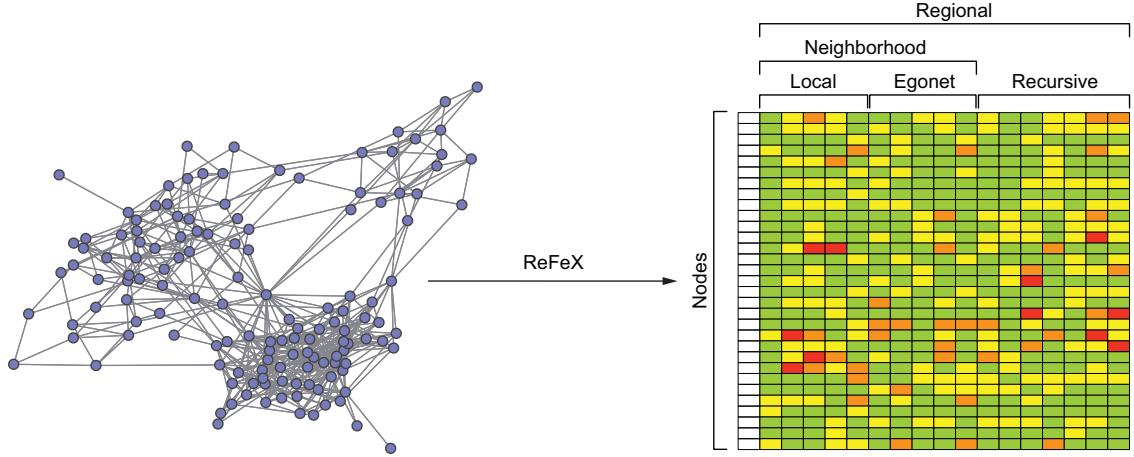

*그림 10.8 — ReFeX 의 입력과 출력. 왼쪽 그래프의 각 노드가 오른쪽 행렬의 한 행이 된다. 열은 세 묶음으로 나뉜다 — **Local**(차수), **Egonet**(에고넷 노드·간선 수), **Recursive**(이웃의 특징을 집계한 것). 앞의 둘을 묶어 **Neighborhood**, 셋 전부를 묶어 **Regional** 이라 부른다. 10.1 절에서 사람이 한 열씩 설계했던 그 행렬을 규칙 하나로 자동 생성하는 것이 ReFeX 다.*

### ReFeX 가 만드는 것 — 지역 특징

ReFeX 는 국소(노드 기반) 특징과 이웃에서 오는(에고넷 기반) 특징을 **재귀적으로 결합** 해 **지역 특징(regional features)** 을 만든다. 이 특징이 담는 것은 **행동적(behavioral)** 정보다. 즉 어떤 노드가 **어떤 종류의 노드들과 연결되어 있는지** 를 나타내며 그 노드들의 **정체성** 은 담지 않는다. 서로 다른 그래프를 가로질러 마이닝할 때 중요한 것은 여러분이 **누구를 아느냐가 아니라 어떤 부류와 관계 맺느냐** 다.

이 성질에서 두 규칙이 나온다.

| 규칙 | 뜻 |
| --- | --- |
| **구조적(Structural)** | 특징 행렬 $F$ 의 구성은 노드·링크의 추가 속성 정보를 요구하지 않아야 한다 |
| **효과적(Effective)** | 좋은 특징은 (1) 속성이 주어졌을 때 그것을 예측하는 데 도움이 되고 (2) 그래프 사이에 전이 가능해야 한다 |

두 번째 규칙의 (2)가 ReFeX 의 차별점이다. 생성된 특징은 **서로 다른 네트워크 사이에서, 혹은 같은 네트워크의 서로 다른 시점 스냅샷 사이에서** 의미 있게 비교할 수 있다. 노드 이름이 아니라 구조만 보기 때문이다. 11장의 얕은 임베딩은 이것을 하지 못한다 — 룩업 테이블의 행 번호가 곧 노드 정체성이므로 다른 그래프로 옮길 수 없다.

> **다만 이 전이 가능성 주장은 가지치기 단계 때문에 조건부다.** 아래 실습 10-D 에서 같은 코드를 크기가 다른 두 그래프에 돌려 **살아남는 특징 열이 서로 다르게 나오는 것** 을 보게 된다.

### 세 단계

ReFeX 는 노드 라벨이나 타입을 보지 않고 **순수한 구조적 측면** 만으로 작동한다.

1. **국소 특징 추출(local feature extraction)** — 노드의 바로 곁 특성. 주된 지표는 **차수** 이고 가중·비가중 변형을 포함한다. 방향 그래프에서는 진입 차수와 진출 차수를 따로 계산한다. 가중 그래프에서는 인접 간선 가중치의 합을 쓴다.

2. **에고넷 특징 검토(examination of egonet features)** — 각 노드의 에고넷에서 **들어오는 간선 수 · 나가는 간선 수 · 전체 에고넷 간선 수** 를 계산한다. 10.1.3 절에서 손으로 계산한 그 에고넷이다.

3. **재귀적 특징 추출(recursive feature extraction)** — 요약 통계를 **재귀적으로** 적용해 기존 특징들을 집계한다. 집계 함수는 **합(sum)과 평균(mean)** 이다. 반복할수록 더 먼 이웃의 정보가 스며든다. `degree(sum)(mean)(mean)(sum)` 같은 특징은 바로 곁 이웃을 훨씬 넘어서는 지역 패턴을 담는다.

3단계가 특징 수를 **기하급수적으로** 늘린다. 특징이 $k$ 개일 때 한 번 반복하면 합·평균 두 벌이 붙어 $3k$ 가 된다. 그래서 가지치기가 필수다.

| 가지치기 기법 | 하는 일 |
| --- | --- |
| **상관 분석(correlation analysis)** | 서로 강하게 상관된 특징 쌍을 찾아 하나를 제거한다 (임계값 0.95) |
| **로그 구간화(logarithmic binning)** | 효율적 비교를 위해 특징 값을 이산 구간에 매핑한다 |
| **임계값 기반 가지치기** | 지정한 임계값보다 차이가 작은 특징을 제거한다 |

### 사람은 여전히 필요하다

ReFeX 는 특징 **생성** 을 자동화하지만 특징 **해석과 검증** 은 자동화하지 않는다. 도메인 전문가는 생성된 특징의 관련성을 검증하고, 도메인 지식으로 특징 선택을 이끌고, 특징이 사기 탐지에 기여하는 바를 설명하고, 필요에 맞춰 추출 과정을 수정한다. 이것이 "반자동"의 뜻이다.


### 10.3.1 ReFeX를 손으로 수행하기 — 노드 A 를 따라가며

알고리즘을 이해하는 가장 빠른 길은 작은 그래프에서 한 노드를 손으로 따라가는 것이다. 책은 10.1 절과 **같은 그래프** 를 쓴다.

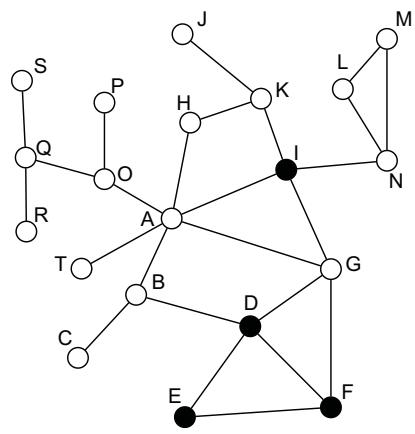

*그림 10.9 — 그림 10.1 과 같은 그래프인데, **노드의 색이 무시된다.** ReFeX 는 노드 타입도 라벨도 보지 않기 때문이다. 10.1 절이 `is_fraudster` 를 지표 안에 집어넣어 "사기 차수·사기 삼각형"을 만든 것과 정반대의 설계다. 그 대가로 ReFeX 특징은 다른 그래프에 그대로 옮길 수 있다.*

단순함을 위해 무향·비가중 그래프를 다루고 가지치기는 하지 않는다.

**1단계 — 국소 특징.** 각 노드의 차수다. 표 10.9 가 그 값이고 10.1.1 절의 전체 차수와 **완전히 같다.** 방향 그래프가 아니므로 진입·진출 차수는 계산할 수 없다.

**2단계 — 에고넷 특징.** 노드 A 의 에고넷은 A 와 이웃 B · G · H · I · O · T 다.

| 항목 | 값 | 근거 |
| --- | --- | --- |
| 에고넷 노드 수 | **7** | A + 이웃 6 |
| 에고넷 내부 간선 수 | **7** | A 의 스포크 6개 + G–I 1개 |
| 에고넷 안팎 간선 수 | **9** | B→C,D · G→D,F · H→K · I→K,N · O→P,Q |

세 번째 항목이 새것이다. 10.1.3 절의 밀도는 **내부** 간선만 셌지만 ReFeX 는 **경계를 넘는** 간선도 센다. 에고넷이 바깥과 얼마나 접해 있는지가 별개의 신호이기 때문이다.

**3단계 — 재귀적 집계.** 노드 A 에 대해 반복을 두 번 돌린다.

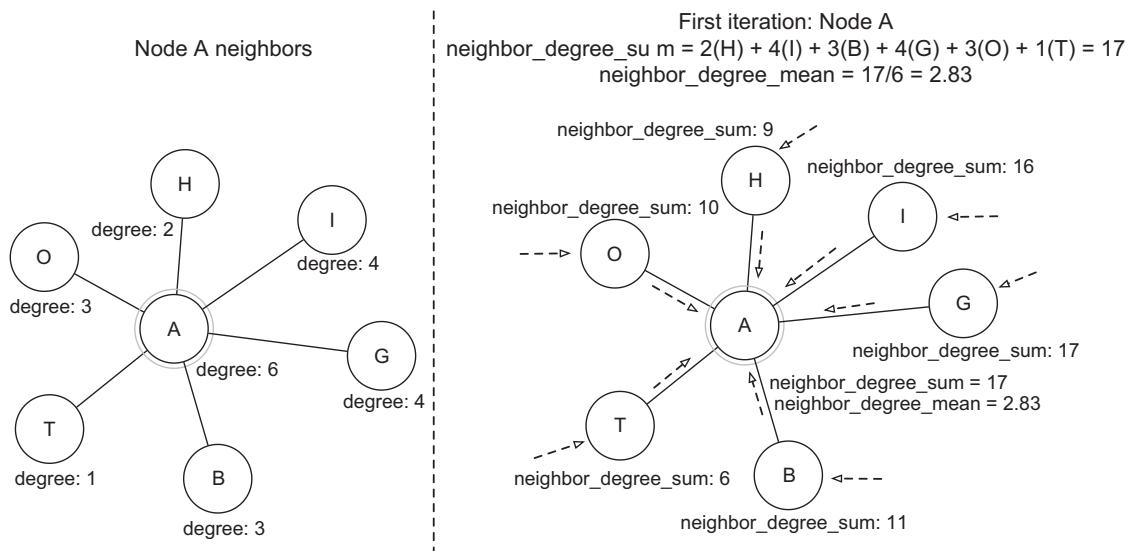

*그림 10.10a — 첫 번째 반복. 왼쪽은 A 의 이웃 여섯과 각자의 차수(H=2, I=4, G=4, B=3, O=3, T=1), 오른쪽은 그 값들이 A 로 모여 `neighbor_degree_sum = 17`, `neighbor_degree_mean = 2.83` 이 되는 과정이다. 동시에 **모든 노드가 같은 일을 한다** — 그림에 B=11, G=17, H=9, I=16, O=10, T=6 으로 각 이웃 자신의 합이 함께 적혀 있는 것이 그래서다.*

$$\text{sum}(\text{neighbor\_degrees}) = \deg(H) + \deg(I) + \deg(G) + \deg(B) + \deg(O) + \deg(T) = 2 + 4 + 4 + 3 + 3 + 1 = 17$$

$$\text{mean}(\text{neighbor\_degrees}) = 17 / 6 \approx 2.83$$

> **원서의 이 수식은 OCR 로 깨져 있다.** 원문 md 에는 `= 2 + 4 + 4 + 3 + 1 + 9 = 17` 로 실려 있는데 왼쪽 항들이 17 로 더해지지 않는다(합하면 23). 그림 10.10a 안에 인쇄된 값이 정답이고 — `2(H) + 4(I) + 3(B) + 4(G) + 3(O) + 1(T) = 17` — 실제 그래프의 차수와도 맞는다. O 의 차수는 9 가 아니라 3 이다. 해설판이 이 깨진 수식을 그대로 옮기며 "O=9" 라고 적은 것도 같은 원인이다. **수식이 이상하면 그림과 원 데이터로 검산하라.**

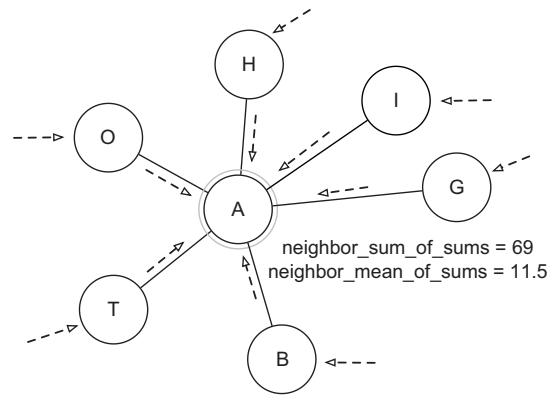

*그림 10.10b — 두 번째 반복. 이번에 A 로 모이는 것은 이웃의 **차수** 가 아니라 이웃이 첫 번째 반복에서 계산한 **합** 이다. B=11, G=17, H=9, I=16, O=10, T=6 을 더해 `neighbor_sum_of_sums = 69`, 나누어 `neighbor_mean_of_sums = 11.5` 를 얻는다.*

$$\text{sum}(\text{neighbor\_aggregates}) = \text{agg}(B) + \text{agg}(G) + \text{agg}(H) + \text{agg}(I) + \text{agg}(O) + \text{agg}(T) = 11 + 17 + 9 + 16 + 10 + 6 = 69$$

$$\text{mean}(\text{neighbor\_aggregates}) = 69 / 6 = 11.5$$

반복을 거듭할수록 더 먼 이웃의 정보가 A 에게 스며든다. **이것이 11장 GNN 의 메시지 전달과 정확히 같은 구조** 라는 점을 눈여겨볼 만하다. 차이는 집계 함수가 학습되느냐(GNN) 고정돼 있느냐(ReFeX)뿐이다. ReFeX 를 이해하면 GNN 의 절반을 이미 이해한 셈이다.

표 10.11 이 반복 두 번을 마친 뒤(가지치기 전) 노드 A 의 특징이다.

| 특징 유형 | 특징 | 값 |
| --- | --- | --- |
| 국소 | 차수(degree) | 6 |
| 에고넷 | 에고넷의 간선 수 | 7 |
| 재귀, 1차 | 이웃 차수의 합 | 17 |
| | 이웃 차수의 평균 | 2.83 |
| 재귀, 2차 | 이웃 합계의 합 | 69 |
| | 이웃 합계의 평균 | 11.5 |

아래 셀이 이 여섯 값을 코드로 재현한다.

In [19]:
"""책 10.18 (저장소 12.19) — ReFeX 구현. 표 10.11 의 손 계산 여섯 값을 재현한다.

먼저 책 원문과 저장소 코드의 차이를 짚어야 한다. 책은 "key parts" 라며 ReFeX 클래스만
싣는데, 저장소 판은 세 곳이 다르다.

  1. 모든 메서드가 (features, features_names) **튜플** 을 돌려준다. 책 판은 배열만
     돌려주므로 어느 열이 무슨 특징인지 알 수 없다. 이름 추적은 해석 가능성 주장의
     핵심이므로 저장소 판이 실질적으로 더 낫다.
  2. 가지치기 위치가 다르다. 책 판은 반복을 다 돈 **뒤 한 번** 가지치기하고, 저장소
     판은 **반복마다** 가지치기한다. 후자는 다음 반복의 입력 차원을 줄이므로 훨씬
     빠르지만, 중간에 버린 특징이 이후 조합에 참여하지 못해 **결과 열 집합이 달라진다.**
  3. 저장소 판은 pandas 를 임포트해 결과를 DataFrame 으로 찍는다.

가지치기 임계값의 의미도 짚어 두자. 상관계수 절댓값이 0.95 를 넘는 쌍에서 **뒤쪽(j)을
버린다.** 어느 쪽을 버릴지에 원칙이 없으므로 열 순서가 결과를 좌우한다 — 결정론적이긴
하지만 '최적 선택'은 아니다. 책도 "최적의 특징 선택을 보장하려면 사람의 감독이 필요하다"고
적는다.

실측 1초 미만이다.
"""
show("10.18", head=24)

refex_module = load("10.18")
ReFeX = refex_module.ReFeX

# 가지치기 없이 돌려 손 계산과 대조한다 (임계값을 1.0 초과로 두면 아무 쌍도 걸리지 않는다).
raw_data, raw_names = ReFeX(max_iterations=2, correlation_threshold=1.01).extract_features(G)
raw_df = pd.DataFrame(raw_data, columns=raw_names, index=list(G.nodes))


def col(frame, name):
    """이름이 같은 열이 여럿이면 첫 번째를 준다 (아래 중복 열 설명 참고)."""
    picked = frame.loc[:, [c == name for c in frame.columns]]
    return picked.iloc[:, 0]


print(f"\n가지치기 없이: {raw_df.shape[0]}개 노드 × {raw_df.shape[1]}개 특징")
print("   1차 6개(degree·in·out·ego_nodes·ego_edges·ego_density)")
print("   -> 반복마다 sum/mean 두 벌이 붙어 6 -> 18 -> 54 로 늘어난다. 기하급수적이다.")

# 열 이름이 유일하지 않다. 구현이 반복마다 '현재 모든 열'에 .sum/.mean 을 붙이는데
# 1차 열들도 그 대상에 들어가므로 2차에서 같은 이름·같은 값이 다시 만들어진다.
import collections
counts = collections.Counter(raw_names)
dups = sorted(k for k, v in counts.items() if v > 1)
print(f"\n   ⚠️ 열 이름 {len(raw_names)}개 중 고유한 것은 {len(counts)}개다. "
      f"중복 이름 {len(dups)}개:")
print("     ", ", ".join(dups))
same = all((raw_df.loc[:, [c == d for c in raw_names]].iloc[:, 0]
            == raw_df.loc[:, [c == d for c in raw_names]].iloc[:, 1]).all() for d in dups)
print(f"      중복 쌍의 값이 완전히 같은가: {same}")
print("      원인: 2차 반복이 1차에서 만든 degree.sum 에 다시 .sum 을 붙이는 동시에,")
print("      원본 degree 에도 .sum 을 붙여 degree.sum 을 한 번 더 만든다. 상관계수가")
print("      1.0 이므로 가지치기를 켜면 자동으로 사라지지만, 끈 상태로 이름을 키로 쓰면")
print("      DataFrame 이 Series 를 돌려줘 조용히 깨진다. 아래는 col() 로 첫 열만 쓴다.")

print("\n=== 책 표 10.11 대조 (노드 A, 가지치기 전) ===")
BOOK_T1011 = {
    ("국소", "차수(degree)", "degree"): 6,
    ("에고넷", "에고넷의 간선 수", "ego_edges"): 7,
    ("재귀 1차", "이웃 차수의 합", "degree.sum"): 17,
    ("재귀 1차", "이웃 차수의 평균", "degree.mean"): 2.83,
    ("재귀 2차", "이웃 합계의 합", "degree.sum.sum"): 69,
    ("재귀 2차", "이웃 합계의 평균", "degree.sum.mean"): 11.5,
}
print(f"{'유형':<10}{'특징':<20}{'열 이름':<20}{'실행':>10}{'책':>8}  일치")
for (kind, label, column), book in BOOK_T1011.items():
    got = col(raw_df, column)["A"]
    print(f"{kind:<10}{label:<20}{column:<20}{got:>10.2f}{book:>8}  "
          f"{'✓' if abs(got - book) < 0.01 else '✗'}")

# 에고넷 안팎 간선 수는 저장소 구현에 없다. 책 본문의 9 를 직접 확인한다.
ego_a = nx.ego_graph(G, "A", radius=1)
boundary = [(u, v) for u, v in G.edges()
            if (u in ego_a) != (v in ego_a)]        # 정확히 한쪽만 에고넷 안
print(f"\n에고넷 안팎 간선 수 (책 본문 9): 실측 {len(boundary)}"
      f"   {sorted((u, v) for u, v in boundary)}")
print("   -> 이 지표는 책 본문과 표 10.10 에는 있지만 저장소 구현에는 없다.")
print("      _extract_egonet_features 가 만드는 것은 노드 수·간선 수·밀도 셋이다.")

print("\n=== 가지치기를 켜면 (기본 임계값 0.95) ===")
pruned_data, pruned_names = ReFeX().extract_features(G)
pruned_df = pd.DataFrame(pruned_data, columns=pruned_names, index=list(G.nodes))
print(f"   {raw_df.shape[1]}개 -> {pruned_df.shape[1]}개로 줄었다 "
      f"({1 - pruned_df.shape[1] / raw_df.shape[1]:.0%} 제거)")
print("   남은 열:", list(pruned_names))
dropped = [c for c in raw_names if c not in set(pruned_names)]
print(f"   버려진 열 {len(dropped)}개 중 앞 8개:", dropped[:8])
print("\n   in_degree·out_degree 가 사라진 것에 주목. 무향 그래프에서 이 둘은 degree 와")
print("   완전히 같으므로(상관계수 1.0) 첫 가지치기에서 바로 제거된다. 알고리즘이")
print("   '방향 그래프가 아니다'를 데이터에서 스스로 알아낸 셈이다.")

print("\n=== ReFeX 특징으로 본 노드 순위 (라벨을 전혀 쓰지 않았다) ===")
print(pruned_df.sort_values("degree.sum", ascending=False).head(6).round(2).to_string())
print("\n   ReFeX 는 is_fraudster 를 한 번도 읽지 않았다. 그런데도 A·G·I 처럼 10.1 절이")
print("   지목한 노드들이 상위에 온다. 구조만으로도 상당 부분이 잡힌다는 뜻이고,")
print("   동시에 '사기 삼각형' 같은 도메인 특화 신호는 잡지 못한다는 뜻이기도 하다.")


── 책 Listing 10.18  ReFeX implementation (key parts)
   출처: 12.19 ReFeX implementation.py  L7-L89  (ReFeX)
    class ReFeX:
        def __init__(self, max_iterations=2, correlation_threshold=0.95):
            self.max_iterations = max_iterations
            self.correlation_threshold = correlation_threshold
    
        def extract_features(self, G):
            features, features_names = self._extract_local_features(G)
    
            egonet_features, egonet_features_names = self._extract_egonet_features(G)
    
            features = np.column_stack((features, egonet_features))
            features_names = np.hstack((features_names, egonet_features_names))
    
            for iteration in range(self.max_iterations):
                new_features, new_features_names = self._generate_recursive_features(G, features, features_names)
    
                features = np.column_stack((features, new_features))
                features_names = np.hstack((features_names, new_features_names))


### 10.3.2 코드로 ReFeX를 자동 수행하기 — 그리고 그 한계

위 셀에서 이미 코드를 돌렸으므로, 여기서는 **구현이 세 단계를 어떻게 코드로 옮겼는지** 와 **그 한계가 무엇인지** 를 정리한다.

| 단계 | 메서드 | 만드는 열 |
| --- | --- | --- |
| 1. 국소 | `_extract_local_features` | `degree` · `in_degree` · `out_degree` (무향이면 뒤 둘이 `degree` 와 같다) |
| 2. 에고넷 | `_extract_egonet_features` | `ego_nodes` · `ego_edges` · `ego_density` (= `nx.density(ego)`) |
| 3. 재귀 | `_generate_recursive_features` | 현재 모든 열의 `.sum` 과 `.mean` |
| 가지치기 | `_prune_features` | 표준화 → 상관 행렬 → $\lvert r \rvert > 0.95$ 인 쌍에서 뒤쪽 제거 |

`_extract_egonet_features` 가 `nx.density(ego)` 를 쓴다는 점이 재미있다. **10.1.3 절에서 사람이 손으로 설계한 에고넷 밀도가 ReFeX 에서는 기본 제공 특징 중 하나** 다. 수동 특징 공학의 결과물 일부는 이미 자동화돼 있다는 뜻이다.

### ReFeX 의 장점 — 실측으로 확인된 것

| 주장 | 이 노트북에서 확인한 것 |
| --- | --- |
| **효율성** | 규칙 하나로 6 → 18 → 54 개 특징을 만든다. 10.1 절은 16개를 만드는 데 함수 일곱 개를 손으로 썼다 |
| **일관성** | 어느 그래프에나 같은 절차가 적용된다 |
| **해석 가능성** | 열 이름이 `degree.sum.mean` 처럼 계산 과정 그대로다. 값을 손으로 검산할 수 있다 (위에서 표 10.11 로 했다) |
| **확장성** | 실습 10-D 에서 노드 946개 그래프에 0.1초 |
| **결정론적** | 같은 입력이 항상 같은 출력을 낸다. 11장 node2vec 은 랜덤 워크라 그렇지 않다 |

### 한계 — 셋

1. **노드 속성과 간선 타입을 반영하지 못한다.** 구조만 본다. 10.1 절의 사기 차수·사기 삼각형에 해당하는 것을 ReFeX 는 만들 수 없다. 10.2 절의 메타경로도 마찬가지다 — 관계 타입을 구별하지 못하므로 `BINDS` 와 `TREATS` 가 같은 간선이 된다.

2. **가지치기가 최적을 보장하지 않는다.** 상관된 쌍에서 **뒤쪽을 버린다** 는 규칙에 원칙이 없다. 열 순서가 결과를 바꾼다.

3. **가지치기 결과가 그래프마다 다르다.** 이것이 위에서 예고한 조건부 사항이다. ReFeX 의 매력 중 하나가 "그래프 사이 전이 가능성"인데, 두 그래프에서 살아남는 열 집합이 다르면 두 특징 행렬을 나란히 놓을 수 없다. 실습 10-D 가 이것을 수치로 보인다.

이 한계들은 다음 장으로 가는 다리다. 11장의 표현 학습은 (1)을 해결하고 — 노드 속성과 간선 타입을 모두 입력으로 받는다 — 그 대가로 ReFeX 의 해석 가능성과 결정론적 성질을 내놓는다. 그 교환이 남는 장사인지는 응용에 달렸고, ReFeX 의 강점과 한계를 알아야 그 판단을 할 수 있다.

### 실습 10-D — Hetionet 부분 그래프에 ReFeX 적용하기

> **해설판 10.3.2 절 연습 문제** — "이 책의 코드 저장소에는 Neo4j에서 사용 가능한 Hetionet 데이터베이스에 연결하는 전체 코드가 있습니다. 직접 실행해 보십시오."

**지문이 가리키는 코드는 저장소에 없다.** `listings/12.19 ReFeX implementation.py` 는 `create_fraud_network()` 로 20개 노드 예제 그래프를 만들 뿐 Neo4j 에 연결하지 않는다. 폴더 어디에도 드라이버를 여는 코드가 없다. 책의 이 문장은 지켜지지 않은 약속이다.

그래서 이 실습은 **그 빠진 연결을 직접 만든다.** 지문의 취지("수동 특징 공학이 비현실적일 만큼 크고 실제적인 시나리오에 ReFeX 를 적용해 보라")를 그대로 살리되, 확인할 것을 셋으로 구체화한다.

1. `hetionet` 에서 부분 그래프를 뽑아 `networkx` 로 옮기고 ReFeX 를 돌린다. 부분 그래프는 **제2형 당뇨병과 연관된 유전자들, 그리고 그 유전자에 결합하는 화합물** 로 잡는다 — 10.2 절이 다룬 바로 그 영역이다.
2. **실행 시간** 을 재서 확장성 주장을 확인한다.
3. 20개 노드 그래프와 946개 노드 그래프에서 **살아남는 특징 열이 같은지** 본다. ReFeX 의 "그래프 간 전이 가능성" 주장이 걸린 지점이다.

부분 그래프로 자르는 이유는 저장소 구현의 성능 특성 때문이다. `_generate_recursive_features` 가 이웃마다 `list(G.nodes()).index(n)` 을 호출하므로 노드 수에 선형인 탐색이 간선마다 두 번 일어난다. 946개 노드에서는 즉시 끝나지만 47,031개 전체에서는 그렇지 않다.


In [20]:
"""실습 10-D 풀이 — hetionet 부분 그래프를 networkx 로 옮겨 ReFeX 를 돌린다.

책이 있다고 말한 'Neo4j 연결 코드'가 저장소에 없으므로 여기서 만든다. 세 부분이다.

  1. Cypher 로 (Compound)-[:BINDS_CbG]-(Gene)-[:ASSOCIATES_DaG]-(t2d) 이웃을 뽑는다.
     노드 이름에 "C:" / "G:" 접두사를 붙여 두 타입이 섞이지 않게 한다. ReFeX 는
     타입을 보지 않으므로 이 접두사는 순전히 사람이 결과를 읽기 위한 것이다.
  2. 업스트림 ReFeX 를 그대로(수정 없이) 돌린다.
  3. 20개 노드 예제 그래프와 열 집합을 비교한다.

실측: Cypher 0.1초 + ReFeX 0.1초. 노드 946개 / 간선 1,655개.
"""
if not HAS_HETIONET:
    print("hetionet DB 가 없어 건너뛴다. 4장 노트북의 책 4.16 을 먼저 실행하라.")
else:
    SUBGRAPH_QUERY = """
        MATCH (d:Disease {name:'type 2 diabetes mellitus'})-[:ASSOCIATES_DaG]-(g:Gene)
        MATCH (c:Compound)-[:BINDS_CbG]-(g)
        RETURN DISTINCT c.name AS compound, g.name AS gene
    """

    started = time.time()
    with cypher.driver() as drv, drv.session(database=HETIONET_DB) as s:
        pairs = [r.data() for r in s.run(SUBGRAPH_QUERY)]
    fetch_seconds = time.time() - started

    H = nx.Graph()
    for pair in pairs:
        H.add_node("C:" + pair["compound"], kind="Compound")
        H.add_node("G:" + pair["gene"], kind="Gene")
        H.add_edge("C:" + pair["compound"], "G:" + pair["gene"])

    n_compound = sum(1 for _, k in H.nodes(data="kind") if k == "Compound")
    print(f"Cypher {fetch_seconds:.1f}초 · 쌍 {len(pairs):,}건")
    print(f"부분 그래프: 노드 {H.number_of_nodes():,} "
          f"(화합물 {n_compound:,} · 유전자 {H.number_of_nodes() - n_compound:,}) "
          f"· 간선 {H.number_of_edges():,}")
    print(f"   예제 그래프 대비 노드 {H.number_of_nodes() / G.number_of_nodes():.0f}배 · "
          f"간선 {H.number_of_edges() / G.number_of_edges():.0f}배")

    started = time.time()
    hetio_data, hetio_names = ReFeX().extract_features(H)
    refex_seconds = time.time() - started
    hetio_df = pd.DataFrame(hetio_data, columns=hetio_names, index=list(H.nodes))
    print(f"\nReFeX {refex_seconds:.2f}초 -> {hetio_df.shape[0]:,} × {hetio_df.shape[1]}")

    print("\n=== 차수 상위 5 (ReFeX 의 degree 열) ===")
    print(hetio_df.sort_values("degree", ascending=False).head(5).round(3).to_string())
    top = hetio_df["degree"].idxmax()
    print(f"\n   1위 {top} — 차수 {hetio_df.loc[top, 'degree']:.0f}. 이 유전자 하나에")
    print(f"   전체 화합물의 {hetio_df.loc[top, 'degree'] / n_compound:.0%} 가 결합한다.")
    print("   CYP 계열은 약물 대사 효소라 온갖 화합물과 결합한다. 즉 구조만 보는 ReFeX 의")
    print("   degree 열이 '이 노드는 허브라 특이적 신호가 아니다'를 곧바로 알려 준다.")
    print("   10.2 절의 DWPC 가 d^-0.4 감쇠로 눌러 없애려던 바로 그 노드다. 두 접근이")
    print("   같은 문제를 서로 다른 방식으로 다룬다 — DWPC 는 가중치로, ReFeX 는 특징으로.")

    print("\n=== 확인 3: 두 그래프에서 살아남은 특징 열이 같은가 ===")
    small, large = set(pruned_names), set(hetio_names)
    print(f"   예제 그래프(노드 {G.number_of_nodes()})   : {len(small)}개 열")
    print(f"   hetionet 부분(노드 {H.number_of_nodes():,}): {len(large)}개 열")
    print(f"   공통           : {len(small & large)}개  {sorted(small & large)}")
    print(f"   예제에만 있음  : {sorted(small - large)}")
    print(f"   hetionet에만   : {sorted(large - small)}")
    print("\n   -> 열 집합이 다르다. 상관 기반 가지치기가 데이터에 의존하기 때문이다.")
    print("      ReFeX 의 '그래프 간 전이 가능성' 주장은 가지치기 전 특징 정의에는")
    print("      성립하지만, 가지치기 후 행렬에는 그대로 성립하지 않는다. 두 그래프를")
    print("      나란히 비교하려면 열 집합을 미리 고정하고 돌려야 한다 —")
    print("      예: 한쪽에서 정한 열만 남기거나, correlation_threshold 를 1.01 로 꺼 두기.")

    print("\n=== 열 집합을 고정하면 비교가 성립한다 ===")
    raw_h, raw_h_names = ReFeX(correlation_threshold=1.01).extract_features(H)
    raw_h_df = pd.DataFrame(raw_h, columns=raw_h_names, index=list(H.nodes))
    print(f"   가지치기를 끄면 양쪽 모두 {len(raw_names)}개 열(고유 "
          f"{len(set(raw_names))}개)로 같다: {set(raw_names) == set(raw_h_names)}")
    print(f"{'특징':<22}{'예제 평균':>12}{'hetionet 평균':>16}")
    for column in ["degree", "ego_edges", "ego_density", "degree.sum", "degree.mean"]:
        print(f"{column:<22}{col(raw_df, column).mean():>12.2f}"
              f"{col(raw_h_df, column).mean():>16.2f}")
    print("\n   읽는 법: degree 와 ego_density 의 평균은 두 그래프가 비슷한데")
    print("   (2.5 대 3.5, 0.76 대 0.75) degree.sum 과 degree.mean 은 자릿수가 다르다")
    print("   (8 대 398, 3.25 대 220). 이유는 CYP3A4 같은 초대형 허브다 — 이웃 하나가")
    print("   차수 516 이면 그 이웃의 degree.sum 이 통째로 튀어오른다. 즉 1차 특징은")
    print("   두 그래프에서 비슷해 보여도 재귀 특징이 허브의 존재를 드러낸다.")
    print("   구조가 전혀 다른 두 그래프를 같은 축으로 비교할 수 있다는 것 — 그것이")
    print("   ReFeX 가 주장하는 전이 가능성이고, 열만 맞춰 주면 실제로 성립한다.")
    print("   (10.1 절의 수동 특징으로는 이 비교가 불가능하다. 'fraud_degree' 는")
    print("   hetionet 에 존재하지 않는 개념이기 때문이다.)")


Cypher 0.0초 · 쌍 1,655건
부분 그래프: 노드 946 (화합물 851 · 유전자 95) · 간선 1,655
   예제 그래프 대비 노드 47배 · 간선 66배



ReFeX 0.12초 -> 946 × 8

=== 차수 상위 5 (ReFeX 의 degree 열) ===
          degree  ego_density  degree.sum  degree.mean  ego_density.mean  ego_density.mean.sum  degree.mean.mean  ego_density.mean.mean
G:CYP3A4   516.0        0.004      1143.0        2.215             0.704                17.660           354.026                  0.034
G:CYP1A2   230.0        0.009       641.0        2.787             0.589                 6.806           257.265                  0.030
G:ALB      121.0        0.016       322.0        2.661             0.632                 5.233           178.560                  0.043
G:CYP2E1   116.0        0.017       372.0        3.207             0.514                 5.182           235.424                  0.045
G:ADRA2A    74.0        0.027       207.0        2.797             0.622                 2.238           158.265                  0.030

   1위 G:CYP3A4 — 차수 516. 이 유전자 하나에
   전체 화합물의 61% 가 결합한다.
   CYP 계열은 약물 대사 효소라 온갖 화합물과 결합한다. 즉 구조만 보는 ReFeX 의
   degree 열이 

   가지치기를 끄면 양쪽 모두 54개 열(고유 42개)로 같다: True
특징                           예제 평균     hetionet 평균
degree                        2.50            3.50
ego_edges                     3.10            3.50
ego_density                   0.76            0.75
degree.sum                    8.00          397.52
degree.mean                   3.25          219.99

   읽는 법: degree 와 ego_density 의 평균은 두 그래프가 비슷한데
   (2.5 대 3.5, 0.76 대 0.75) degree.sum 과 degree.mean 은 자릿수가 다르다
   (8 대 398, 3.25 대 220). 이유는 CYP3A4 같은 초대형 허브다 — 이웃 하나가
   차수 516 이면 그 이웃의 degree.sum 이 통째로 튀어오른다. 즉 1차 특징은
   두 그래프에서 비슷해 보여도 재귀 특징이 허브의 존재를 드러낸다.
   구조가 전혀 다른 두 그래프를 같은 축으로 비교할 수 있다는 것 — 그것이
   ReFeX 가 주장하는 전이 가능성이고, 열만 맞춰 주면 실제로 성립한다.
   (10.1 절의 수동 특징으로는 이 비교가 불가능하다. 'fraud_degree' 는
   hetionet 에 존재하지 않는 개념이기 때문이다.)


---
## 요약

해설판이 정리한 이 장의 핵심을 이 노트북에서 실제로 본 것과 함께 옮긴다.

- 그래프에서의 **수동·반자동 특징 공학** 은 ML 작업의 토대이며 해석 가능성과 자동화 사이의 균형점을 고른다. 이 노트북은 그 스펙트럼의 왼쪽 두 칸을 걸었다 — 10.1\~10.2 절이 수동, 10.3 절이 반자동이다

- 수동 특징 공학은 **국소 지표(차수·삼각형·에고넷 밀도)와 전역 지표(측지 경로·근접·매개 중심성·페이지랭크)를 결합** 해 노드 표현을 만든다. 노드 A 는 이 과정을 거쳐 16차원 벡터가 됐다

- 지표를 도메인에 맞게 **변형** 하는 것이 이 장의 진짜 기법이다. 차수를 사기/정상으로, 삼각형을 사기/반사기/정상으로 쪼갠 열들이 10.1.8 절 특징 중요도 상위를 차지했다. 다만 그 대가로 **정답 라벨이 특징 계산에 들어간다** — 16열 중 8열이 그렇다

- **관계 표현** 은 노드 기반 결합(이어붙이기·평균·L1·L2·아다마르)이나 경로 기반 특징(메타경로)으로 접근한다. 앞의 다섯 연산자는 대칭성·차원·정보 손실이 서로 다르고, 정답은 벤치마크로만 정해진다

- **DWPC** 는 중간 노드 차수에 반비례하는 감쇠로 허브 노드의 잡음을 줄인다. 4장에서 순위표를 만드는 데 썼던 것을 여기서는 특징 벡터의 한 칸으로 쓴다

- **도메인 전문성** 이 지표 선택부터 결과 검증까지를 이끈다. 실습 10-C 가 그 필요를 보여준다 — CrCtD 는 값이 깨끗하게 갈리지만 정의 안에 예측 대상이 들어 있어 써서는 안 되는 축이다

- **ReFeX 같은 반자동 접근** 은 해석 가능한 특징을 자동 생성해 중간 지대를 만든다. 재귀 집계 구조는 11장 GNN 의 메시지 전달과 같고, 차이는 집계 함수가 학습되느냐 고정돼 있느냐뿐이다

- **특징 가지치기와 선택** 은 두 접근 모두에서 필수다. ReFeX 는 54개를 13개로 줄였지만, 그 가지치기가 데이터 의존적이라 그래프가 바뀌면 남는 열도 바뀐다

### 이 노트북에서 실측한 수치

| 항목 | 실측값 | 책 값 | 비고 |
| --- | --- | --- | --- |
| 예제 그래프 규모 | 노드 20 · 간선 25 · 연결 성분 1 | 그림 10.1 | 사기꾼 4명(20%) |
| 표 10.1 차수 재현 | 20/20 일치 | 표 10.1 | 손 계산·리스팅·표 세 값이 모두 같다 |
| 표 10.2 삼각형 재현 | 20/20 일치 | 표 10.2 | `nx.triangles()` 와도 일치 |
| 서로 다른 삼각형 수 | 4개 (A-G-I · D-E-F · D-F-G · L-M-N) | — | 노드별 합 12 = 3T 검산 통과 |
| 표 10.3 밀도 재현 | 18/20 일치 | 표 10.3 | H·N 만 0.67 vs 0.66. 책 표가 절단 표기 |
| 표 10.4 측지 거리 열 | 20/20 일치 | 표 10.4 | |
| **표 10.4 홉 수 세 열** | **리스팅 6/20 · 걸음 수 재구성 20/20** | 표 10.4 | 리스팅과 표가 다른 양을 센다 (아래 참고) |
| 표 10.5 근접 중심성 재현 | 20/20 일치 | 표 10.5 | `nx.closeness_centrality` 와도 일치 |
| **표 10.6 매개 중심성** | **`normalized=False` 20/20 · 리스팅 기본값 9/20** | 표 10.6 | 책 표는 정규화하지 않은 값 |
| 정규화 상수 | C(19,2) = 171 | — | A: 104 → 0.608 |
| 기본 페이지랭크 재현 | 19/20 일치 | 표 10.7 | Q 만 0.076 vs 책 0.75 (오타) |
| **사기 가중 페이지랭크** | **리스팅 기본값 L1 오차 0.575 · "사기꾼만 1" 0.009** | 표 10.7 | 책 표는 다른 개인화 벡터로 계산됐다 |
| 특징 행렬 | 20 × 17 (특징 16 + 라벨 1) | 리스팅 10.10 | 라벨을 쓰는 열 8/16 |
| 분류기 정확도 | 1.00 (테스트 4개: 정상 3 · 사기 1) | 책은 해석하지 말라고 명시 | 표본이 작고 라벨 누출이 있다 |
| 상위 특징 5개 | `geodesic_path` 0.707 · `fraud_triangles` 0.612 · `paths_2hop` 0.584 · `paths_1hop` 0.523 · `paths_3hop` 0.452 | — | scikit-learn 버전에 따라 순서가 바뀔 수 있다 |
| 노드 A 사기 확률 | 0.100 | — | 노드 G 는 0.176 |
| `hetionet` 규모 | 노드 47,031 / 관계 2,250,197 | 4장과 동일 | 4장 백업 시드 |
| **책 10.15 DWPC (원문)** | PC 1 · **DWPC 0.0007028** | 책 본문 0.0007 | 바인딩 없는 `v` 를 쓴 값 |
| 책 10.15 DWPC (`v`→`c`) | PC 1 · DWPC 0.0078220 | — | 11.1배 차이 |
| Metformin BINDS 차수 | `c` = 56 · `v` = 23,142 | — | 23,142 = 전체 BINDS 관계 11,571 × 2 |
| 책 10.16 CbGeAlD | PC 340 · DWPC 0.036168 | — | |
| 책 10.17 CbGpPWpGaD | PC 5,277 · DWPC 0.094077 | — | PC 는 5,277배인데 DWPC 는 12배 |
| 실습 10-C CrCtD (TREATS/비TREATS) | 0.1557 / 0.0000 | — | 완전 분리 — 라벨 누출 축 |
| 실습 10-C CdGuD | 여섯 화합물 모두 0 | — | t2d 의 `UPREGULATES_DuG` 가 1건뿐 |
| 표 10.11 ReFeX 노드 A | degree 6 · ego_edges 7 · degree.sum 17 · degree.mean 2.83 · degree.sum.sum 69 · degree.sum.mean 11.5 | 표 10.11 | 6/6 일치 |
| 에고넷 안팎 간선 수 (A) | 9 | 본문 9 | 저장소 구현에는 없는 지표 |
| ReFeX 특징 폭발 | 6 → 18 → 54 (고유 42) | — | 이름 중복 12쌍, 값도 동일 |
| ReFeX 가지치기 | 54 → 13개 (76% 제거) | — | `in_degree`·`out_degree` 가 먼저 사라진다 |
| 실습 10-D 부분 그래프 | 노드 946 (화합물 851 · 유전자 95) / 간선 1,655 | — | Cypher 0.1초 |
| 실습 10-D ReFeX | 0.12초 → 946 × 8 | — | 예제 그래프의 47배 규모 |
| 최대 허브 | `CYP3A4` 차수 516 (화합물의 61%) | — | DWPC 가 감쇠로 누르려던 그 노드 |
| 두 그래프의 잔존 열 | 예제 13 · hetionet 8 · 공통 7 | — | 가지치기가 데이터 의존적이다 |

### 책·업스트림과 어긋난 것 — 다섯 건

| # | 내용 | 근거 |
| --- | --- | --- |
| 1 | **표 10.4 의 홉 수 열과 리스팅 10.6 이 다른 양을 센다.** 표는 인접행렬 $A^k$ 의 사기꾼 열 합(길이 $k$ 걸음 수), 리스팅은 최단 거리가 $k$ 인 사기꾼 수 | 걸음 수 재구성이 20/20, 리스팅이 6/20 일치. 리스팅 값은 사기꾼 수 4를 넘을 수 없는데 표 A 행은 1+4+18 = 23 |
| 2 | **표 10.6 은 정규화하지 않은 매개 중심성인데 리스팅 기본 인자는 `normalized=True`** | `normalized=False` 로 20/20 일치, 기본값으로 9/20 (0인 값만 우연히 맞는다) |
| 3 | **표 10.7 의 사기 가중 페이지랭크는 리스팅 기본 개인화로 재현되지 않는다.** 개인화 후보 다섯을 넣어 역추적하면 "사기꾼만 1, 나머지 0"이 정답 | L1 오차 0.009 vs 리스팅 기본값 0.575 |
| 4 | **표 10.7 의 Q 기본 페이지랭크 0.75 는 오타.** 실제 0.076 | 20개 값의 합이 1.663 이 되어 확률분포가 아니다 |
| 5 | **책 10.15 의 Cypher 가 바인딩되지 않은 변수 `v` 를 쓴다.** 10.16 · 10.17 은 같은 자리에 `c` 를 쓴다 | `count{(v)-...}` = 23,142 (전역 합계), `count{(c)-...}` = 56 (Metformin 차수). DWPC 가 11.1배 차이 |

부수 관찰 셋.

- **책 본문이 인용하는 DWPC 0.0007 자체가 버그가 낳은 값** 이다. 원문 그대로 실행하면 그 값이 나온다. 즉 저자도 이 판으로 돌렸다는 뜻이고, `listings/12.18` 의 LLM 프롬프트가 이 쿼리를 "검증된 예시"로 심어 놓았다
- **원서에서 리스팅 10.5(에고넷 밀도)는 코드가 아니라 캡션째 스캔 이미지 두 장** 이다. 그래서 번호를 텍스트로 긁는 자동 추출이 이 장의 책 리스팅을 15건이 아닌 14건으로 센다. 실물은 `listings/12.5 ...py` 에 있다
- **그림 10.10a 의 합 수식이 원문 md 에서 OCR 로 깨져 있다.** `2 + 4 + 4 + 3 + 1 + 9 = 17` 로 실려 있는데 왼쪽이 23 이다. 그림 안에 인쇄된 값(`2+4+3+4+3+1`)과 실제 차수가 정답이다

업스트림 코드 쪽 관찰 넷.

| 파일 | 관찰 |
| --- | --- |
| `12.10` · `12.11` · `12.12` | 임포트는 되지만 호출하면 `NameError`. 앞 리스팅의 함수를 정의 없이 부른다. 실행 가능한 판은 `12.13` 하나뿐이다 |
| `12.14` | `import numpy as np` 가 없어 `operator_l1`·`operator_l2` 가 깨지고, `catenate` 는 리스트를·나머지는 배열을 요구해 입력 타입이 섞인다 |
| `12.19` | 책 10.18 과 두 곳이 다르다 — 특징 **이름** 을 함께 추적하고(책 판은 배열만 돌려준다), 가지치기를 반복마다 한다(책 판은 마지막에 한 번) |
| `12.19` | 반복마다 원본 열에도 `.sum`/`.mean` 을 다시 붙여 **같은 이름·같은 값의 열이 12쌍** 생긴다. 가지치기를 켜면 사라지지만 끄면 남는다 |
| `tasks.py` | 독스트링이 "listings/ 에 책 번호 −2 로 들어 있다"고 단정하는데 **책 10.18 ↔ `12.19`** 한 건이 어긋난다 |

### 핵심 용어

| 용어 | 뜻 |
| --- | --- |
| 벡터화 / 특징화 (vectorization / featurization) | 그래프의 노드·관계·그래프 전체를 ML 이 처리할 수 있는 숫자 벡터로 바꾸는 단계 |
| 특징 공학 (feature engineering) | 그래프 성질과 도메인 지식에 기반해 사람이 직접 특징을 설계하는 방식 |
| 표현 학습 (representation learning) | 그래프 구조로부터 특징을 자동 학습하는 방식. 11\~12장 |
| 국소 특징 / 전역 특징 | 에고넷(또는 n차 이웃)만 보는 특징 / 네트워크 전체에서의 역할을 재는 특징 |
| 에고넷 (egonet) · 에고 · 알터 | 특정 노드와 그 바로 곁 이웃으로 이뤄진 국소 네트워크 / 중심 노드 / 주변 노드 |
| 차수 (degree) | 노드의 이웃 수. 이 장에서는 사기 차수·정상 차수로 쪼갠다 |
| 삼각형 (triangle) | 세 노드가 서로 모두 연결된 부분 그래프. 두 알터의 라벨로 사기/반사기/정상으로 나뉜다 |
| 밀도 (density) | 가능한 최대 간선 수 대비 실제 간선 수. $2M / N(N-1)$ |
| 측지 경로 / 최단 경로 | 두 노드 사이의 최소 홉 수 |
| 걸음 (walk) | 노드 재방문을 허용하는 경로. $A^k$ 가 길이 $k$ 걸음 수를 준다. 표 10.4 가 실제로 센 것 |
| 다익스트라 알고리즘 | 잠정 거리가 가장 작은 노드를 반복 선택하며 최단 경로 트리를 쌓는 알고리즘 |
| 원거리도 (farness) | 한 노드에서 다른 모든 노드까지의 평균 최단 거리 |
| 근접 중심성 (closeness centrality) | 원거리도의 역수. 크면 네트워크 중앙에 있다 |
| 매개 중심성 (betweenness centrality) | 다른 쌍들의 최단 경로 위에 얼마나 자주 나타나는가. 다리 역할의 정도 |
| 페이지랭크 (PageRank) | 들어오는 연결의 양과 질을 함께 보는 재귀적 중요도 |
| 감쇠 계수 (damping factor) | 페이지랭크의 $\alpha$. 서퍼가 링크를 따라갈 확률. 관례 0.85 |
| 개인화 (personalization) | 페이지랭크의 순간이동 목적지 분포. 사기꾼에 무게를 실으면 사기 가중 페이지랭크가 된다 |
| 계층적 분할 (stratified split) | 학습·테스트 세트가 원본과 같은 클래스 비율을 유지하도록 나누는 분할 |
| 라벨 누출 (label leakage) | 정답 라벨이 특징 계산에 흘러 들어가 성능이 과대평가되는 현상 |
| 링크 예측 / 관계 예측 | 두 노드 사이에 관계가 존재할 가능성을 예측하는 작업 |
| 노드 기반 결합 | 두 노드의 벡터를 이어붙이기·평균·L1·L2·아다마르 곱으로 합쳐 관계를 표현 |
| 아다마르 곱 (Hadamard product) | 대응 원소끼리의 곱 $\mathbf{u} \odot \mathbf{v}$ |
| 경로 기반 특징 | 두 노드가 이어진 방식(경로 패턴)으로 관계를 특징짓는 방식 |
| 메타경로 / 메타그래프 | 노드 타입과 관계 타입의 순서열 / 그 상위 스키마 |
| PC (path count) | 두 노드 사이 경로 인스턴스의 단순 개수 |
| DWPC (degree-weighted path count) | 중간 노드 차수에 반비례하는 감쇠를 적용한 경로 수. 허브 잡음을 줄인다 |
| 메타경로 축소 / 쌍 선택 | Himmelstein 등의 2단계 축소. 1,026 → 709 메타경로, 유망한 쌍만 선별 |
| ReFeX | 국소·에고넷 특징을 재귀 집계해 해석 가능한 구조 특징을 자동 생성하는 반자동 기법 |
| 지역 특징 (regional features) | "어떤 부류의 노드들과 연결되어 있는가"를 담는 행동적 특징 |
| 가지치기 (pruning) | 상관 분석·로그 구간화·임계값으로 중복·무용한 특징을 제거하는 과정 |
| 결정론적 (deterministic) | 같은 입력이 항상 같은 출력을 내는 성질 |

### 참고 링크

- [교재 10장 해설판 (한국어)](../../10_graph_feature_engineering_manual_and_semiautomated_approaches_ko_explained.md)

- [교재 10장 원서 원문](../../10_graph_feature_engineering_manual_and_semiautomated_approaches.md)

- [4장 노트북 — DWPC 정의와 Hetionet 구축](../../../chapter_04_from_simple_networks_to_multisource_integration/src/ch04/04_chapter_guide.ipynb)

- [11장 노트북 — 이 특징들을 신경망이 대신 배우게 만들기](../../../chapter_11_graph_representation_learning_and_graph_neural_networks/src/ch13/11_chapter_guide.ipynb)

- [원서 저장소 chapters/ch12](https://github.com/alenegro81/knowledge-graphs-and-llms-in-action/tree/main/chapters/ch12)

- [Hetionet (het.io)](https://het.io/)

- [Neo4j Graph Data Science — 다익스트라·중심성 구현](https://github.com/neo4j/graph-data-science)

- [NetworkX 알고리즘 문서](https://networkx.org/documentation/stable/reference/algorithms/index.html)

### 다음 장으로

이 장은 **사람이 무엇을 볼지 정했다.** 차수를 사기/정상으로 쪼갤지, 메타경로를 어느 길이까지 볼지, 에고넷 밀도를 넣을지 — 모두 사람의 결정이었다. ReFeX 가 그 손일의 일부를 자동화했지만 여전히 **집계 규칙(합·평균)은 고정** 되어 있었다.

**11장(저장소 [`ch13`](../../../chapter_11_graph_representation_learning_and_graph_neural_networks/src/ch13))** 은 그 규칙마저 학습시킨다. 노드를 밀집 벡터로 바꾸되 각 축이 무엇을 뜻하는지는 정하지 않고, 손실 함수가 정하게 둔다. 이 장의 ReFeX 재귀 집계가 GNN 의 **메시지 전달** 과 구조적으로 같다는 점을 기억하면 11장의 절반은 이미 읽은 셈이다 — 바뀌는 것은 `np.sum`/`np.mean` 자리에 학습 가능한 어텐션·게이트가 들어간다는 것뿐이다.

교환 조건도 분명하다. 얻는 것은 **표현력** 이고 잃는 것은 **해석 가능성** 이다. 이 노트북에서 `degree.sum.mean = 11.5` 가 무엇인지 손으로 검산할 수 있었던 것이 11장에서는 불가능해진다. 그래서 이 장의 특징들은 사라지지 않는다 — 설명 가능성이 요구되는 곳, 데이터가 작은 곳, LLM 이 그래프에 대해 추론할 발판이 필요한 곳에서 계속 쓰인다.

> **저장소 디렉터리 번호 주의.** 이 장은 책 10장이지만 업스트림 디렉터리는 `ch12` 다. MEAP 번호를 그대로 쓰기 때문이고, 근거는 `fraud` 라는 단어가 책 10장에만 114회 나오는 것이다. 11장은 `ch13`, 12장은 `ch14` 로 같은 만큼 밀려 있다.
